In [ ]:
# •	File name: FC-ANN Surrogate model
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.

In [7]:
import os
print("Current directory:", os.getcwd())  # Output: e.g., `/home/user/notebooks`


Current directory: C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN


In [5]:
# Change the directory
os.chdir("C:/Users/User/OneDrive - C-COM Satellite Systems/Desktop/Fully ANN")  # Change directory
#print("New directory:", os.getcwd())

In [13]:
####Imports and Configuration
### =============================================================================
### STEP 1: CONFIGURATION & GLOBAL SETTINGS
### =============================================================================
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import warnings
warnings.filterwarnings("ignore")

# SIMPLE CONFIGURATION (no class)
OUTPUT_DIR = Path(".").absolute() / "output"
INPUTS_FILE = OUTPUT_DIR / "input_parameters.csv"
ANNUAL_FILE = OUTPUT_DIR / "dataout.csv"
HOURLY_H5_FILE = OUTPUT_DIR / "hourly_data_3d.h5"

# File paths for saving
NORM_JSON = OUTPUT_DIR / "norm_params.json"
MODEL_FILE = OUTPUT_DIR / "unified_model_complete.pth"
MODEL_INFO = OUTPUT_DIR / "model_info.json"
TRAINING_HISTORY = OUTPUT_DIR / "training_history.json"
METRICS_FILE = OUTPUT_DIR / "performance_metrics.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

PARAM_NAMES_EXPECTED = [
    "Area", "Aspect_Ratio", "window_u", "window_shgc", "Direction",
    "Wall_R", "Roof_R", "Infiltration", "WWR", "LPD", "EPD", "N_of_Fl"
]

INPUT_RANGES = {
    "Area": [404, 4000],
    "Aspect_Ratio": [0.3, 1],
    "window_u": [0.57, 1.95],
    "window_shgc": [0.25, 0.7],
    "Direction": [0, 180],
    "Wall_R": [0.145, 0.363],
    "Roof_R": [0.12, 0.36],
    "Infiltration": [0.000028, 0.0003],
    "WWR": [0.15, 0.55],
    "LPD": [2, 8],
    "EPD": [3, 20],
    "N_of_Fl": [0, 10]
}

ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Configuration loaded successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Using device: {DEVICE}")

Configuration loaded successfully!
Output directory: C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output
Using device: cpu


In [15]:
### STEP 2: DATA LOADING
### =============================================================================
def load_data_files():
    """Load all data files from disk"""
    print("Loading data files...")
    
    inputs_df = pd.read_csv(INPUTS_FILE)
    annual_df = pd.read_csv(ANNUAL_FILE)

    # Rename columns for consistency
    rename_map = {"Window_U": "window_u", "Window_SHGC": "window_shgc"}
    inputs_df = inputs_df.rename(columns=rename_map)

    with h5py.File(HOURLY_H5_FILE, "r") as f:
        ds_name = list(f.keys())[0]
        hourly_3d = f[ds_name][:]

    hourly_3d = hourly_3d / 3.6e6  # convert J→kWh
    print(f"✓ Loaded: inputs {inputs_df.shape}, annual {annual_df.shape}, hourly {hourly_3d.shape}")
    
    return inputs_df, annual_df, hourly_3d

print("STEP 2: LOADING DATA")
inputs_df, annual_df, hourly_3d = load_data_files()

STEP 2: LOADING DATA
Loading data files...
✓ Loaded: inputs (3000, 12), annual (3000, 4), hourly (3000, 365, 24)


In [21]:
### STEP 3: NORMALIZATION
### =============================================================================
def normalize_input_data(df):
    """Normalize inputs using predefined ranges"""
    df_norm = df.copy()
    for col in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[col]
        df_norm[col] = (df_norm[col] - vmin) / (vmax - vmin)
    return df_norm

def calculate_output_ranges(annual_df, hourly_3d):
    """Calculate normalization ranges separately for each annual output"""
    annual_ranges = {}
    for col in ANNUAL_COLS:
        annual_ranges[f"{col}_min"] = float(annual_df[col].min())
        annual_ranges[f"{col}_max"] = float(annual_df[col].max())
    
    hourly_min = float(np.min(hourly_3d))
    hourly_max = float(np.max(hourly_3d))
    
    return annual_ranges, hourly_min, hourly_max

def normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max):
    """Normalize outputs using separate ranges for each annual output"""
    ann_norm = annual_df[ANNUAL_COLS].copy()
    
    # Normalize each annual output separately
    for col in ANNUAL_COLS:
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        ann_norm[col] = (ann_norm[col] - vmin) / (vmax - vmin)
    
    # Normalize hourly data
    hourly_norm = (hourly_3d - hourly_min) / (hourly_max - hourly_min)
    
    return ann_norm, hourly_norm

def save_normalization_parameters(annual_ranges, hourly_min, hourly_max):
    """Save all normalization parameters for later use"""
    norm_data = {
        "input_ranges": INPUT_RANGES,
        "annual_ranges": annual_ranges,
        "hourly_min": hourly_min,
        "hourly_max": hourly_max,
        "param_names": PARAM_NAMES_EXPECTED,
        "annual_cols": ANNUAL_COLS
    }
    
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    with open(NORM_JSON, "w") as f:
        json.dump(norm_data, f, indent=4)
    print(f"✓ Normalization parameters saved to {NORM_JSON}")

print("STEP 3: NORMALIZATION")
inputs_norm = normalize_input_data(inputs_df)
annual_ranges, hourly_min, hourly_max = calculate_output_ranges(annual_df, hourly_3d)
ann_norm_df, hourly_norm = normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max)
save_normalization_parameters(annual_ranges, hourly_min, hourly_max)

# Prepare arrays for training
X = inputs_norm[PARAM_NAMES_EXPECTED].values.astype(np.float32)
Y_ann = ann_norm_df[ANNUAL_COLS].values.astype(np.float32)
Y_hour = hourly_norm.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"Y_ann shape: {Y_ann.shape}")
print(f"Y_hour shape: {Y_hour.shape}")

STEP 3: NORMALIZATION
✓ Normalization parameters saved to C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output\norm_params.json
X shape: (3000, 12)
Y_ann shape: (3000, 3)
Y_hour shape: (3000, 365, 24)


In [23]:
### STEP 4: DATA SPLIT FOR OPTUNA
### =============================================================================
def split_data_for_optuna(X, Y_ann, Y_hour, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split data for Optuna hyperparameter tuning
    Returns: X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val
    """
    print("Splitting data for Optuna tuning...")
    
    # First split: separate test set
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    # Second split: train/validation from remaining data
    X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val = train_test_split(
        X_temp, y_ann_temp, y_hour_temp, test_size=val_size, random_state=random_state
    )
    
    print(f"✓ Data split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    
    return X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val

print("STEP 4: DATA SPLIT FOR OPTUNA")
X_train_opt, X_val_opt, y_ann_train_opt, y_ann_val_opt, y_hour_train_opt, y_hour_val_opt = split_data_for_optuna(X, Y_ann, Y_hour)

STEP 4: DATA SPLIT FOR OPTUNA
Splitting data for Optuna tuning...
✓ Data split - Train: 2167, Val: 383, Test: 450


In [25]:
## STEP 5: MODEL ARCHITECTURE - SIMPLE FULLY CONNECTED ANN
### =============================================================================
# Define the model architecture with fully connected head for hourly outputs
class UnifiedNetFC(nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, hidden_dim=256, ann_out=3, hour_out=8760):
        super().__init__()
        
        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, latent_dim), 
            nn.ReLU()
        )
        
        # Annual output head (unchanged)
        self.ann_head = nn.Sequential(
            nn.Linear(latent_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, ann_out)
        )
        
        # NEW: Fully connected head for hourly outputs (replaces CNN)
        self.hourly_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hour_out)  # Direct output to 8760 hourly values
        )
    
    def forward(self, x):
        z = self.encoder(x)
        
        # Annual outputs (unchanged)
        ann = self.ann_head(z)
        
        # NEW: Hourly outputs via fully connected layers
        hour_flat = self.hourly_head(z)
        
        # Reshape to match expected format: (batch_size, 1, 365, 24)
        hour = hour_flat.view(-1, 1, 365, 24)
        
        return ann, hour

# Update the Dataset class to work with FC architecture
class BuildingDatasetFC(Dataset):
    def __init__(self, X, Y_ann, Y_hour):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_ann = torch.tensor(Y_ann, dtype=torch.float32)
        # Remove the channel dimension for FC approach
        self.Y_hour = torch.tensor(Y_hour, dtype=torch.float32)  # Shape: (batch, 365, 24)
    
    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.Y_ann[idx], self.Y_hour[idx]

print("✓ Fully Connected ANN architecture defined")

✓ Fully Connected ANN architecture defined


In [27]:
## STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION (FC VERSION)
### =============================================================================

def run_optuna_optimization_fc(X_train, y_ann_train, y_hour_train, 
                              X_val, y_ann_val, y_hour_val, 
                              n_trials=5, timeout=600):
    """
    Run Optuna hyperparameter optimization for FC architecture
    """
    print("Starting Optuna hyperparameter optimization for FC architecture...")
    
    def objective(trial):
        # Suggest hyperparameters (removed conv_channels)
        latent_dim = trial.suggest_categorical("latent_dim", [64,128, 256, 512])
        hidden_dim = trial.suggest_categorical("hidden_dim", [128,256, 512, 1024])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        wd = trial.suggest_float("wd", 1e-6, 1e-4, log=True)
        w_hour = trial.suggest_float("w_hour", 0.1, 2.0)
        
        # Create FC model
        model = UnifiedNetFC(
            in_dim=X_train.shape[1], 
            latent_dim=latent_dim, 
            hidden_dim=hidden_dim,
            ann_out=y_ann_train.shape[1],
            hour_out=8760  # 365 * 24
        ).to(DEVICE)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        criterion = nn.MSELoss()
        
        # Create data loaders with FC dataset
        train_loader = DataLoader(
            BuildingDatasetFC(X_train, y_ann_train, y_hour_train), 32, True
        )
        val_loader = DataLoader(
            BuildingDatasetFC(X_val, y_ann_val, y_hour_val), 32, False
        )
        
        # Short training and validation
        best_val_loss = float('inf')
        for epoch in range(10):  # Reduced epochs for faster tuning
            # Training
            model.train()
            for X_batch, y_ann_batch, y_hour_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_ann_batch = y_ann_batch.to(DEVICE)
                y_hour_batch = y_hour_batch.to(DEVICE)
                
                optimizer.zero_grad()
                pred_ann, pred_hour = model(X_batch)
                loss_ann = criterion(pred_ann, y_ann_batch)
                # Flatten hourly predictions for loss calculation
                loss_hour = criterion(pred_hour.view(-1, 365, 24), y_hour_batch)
                total_loss = loss_ann + w_hour * loss_hour
                total_loss.backward()
                optimizer.step()
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for X_batch, y_ann_batch, y_hour_batch in val_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_ann_batch = y_ann_batch.to(DEVICE)
                    y_hour_batch = y_hour_batch.to(DEVICE)
                    
                    pred_ann, pred_hour = model(X_batch)
                    loss_ann = criterion(pred_ann, y_ann_batch)
                    loss_hour = criterion(pred_hour.view(-1, 365, 24), y_hour_batch)
                    total_loss = loss_ann + w_hour * loss_hour
                    val_loss += total_loss.item() * X_batch.size(0)
            
            val_loss /= len(val_loader.dataset)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
        
        return best_val_loss
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, timeout=timeout)
    
    print("✓ Optuna optimization for FC architecture completed!")
    print(f"Best hyperparameters: {study.best_params}")
    print(f"Best validation loss: {study.best_value:.6f}")
    
    return study.best_params

print("STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION (FC VERSION)")
best_params_fc = run_optuna_optimization_fc(
    X_train_opt, y_ann_train_opt, y_hour_train_opt,
    X_val_opt, y_ann_val_opt, y_hour_val_opt,
    n_trials=10, timeout=1200
)

[I 2025-10-31 16:45:28,478] A new study created in memory with name: no-name-5489c136-0947-4c9a-8530-aa25b9c3e710


STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION (FC VERSION)
Starting Optuna hyperparameter optimization for FC architecture...


[I 2025-10-31 16:45:54,368] Trial 0 finished with value: 0.0005443291928602125 and parameters: {'latent_dim': 128, 'hidden_dim': 1024, 'lr': 0.0004672571192010849, 'wd': 1.7178834683616742e-06, 'w_hour': 1.5069126582727388}. Best is trial 0 with value: 0.0005443291928602125.
[I 2025-10-31 16:46:09,060] Trial 1 finished with value: 0.0004918769276433432 and parameters: {'latent_dim': 256, 'hidden_dim': 512, 'lr': 0.007108580600634694, 'wd': 2.6348273624375656e-05, 'w_hour': 0.8409153154238195}. Best is trial 1 with value: 0.0004918769276433432.
[I 2025-10-31 16:46:20,970] Trial 2 finished with value: 0.0003084190554282198 and parameters: {'latent_dim': 256, 'hidden_dim': 256, 'lr': 0.008013048360758612, 'wd': 3.2724248055066594e-06, 'w_hour': 0.4861578383307381}. Best is trial 2 with value: 0.0003084190554282198.
[I 2025-10-31 16:46:33,018] Trial 3 finished with value: 0.00033149952050687514 and parameters: {'latent_dim': 512, 'hidden_dim': 256, 'lr': 0.005791967806500431, 'wd': 6.80225

✓ Optuna optimization for FC architecture completed!
Best hyperparameters: {'latent_dim': 256, 'hidden_dim': 256, 'lr': 0.008013048360758612, 'wd': 3.2724248055066594e-06, 'w_hour': 0.4861578383307381}
Best validation loss: 0.000308


In [9]:
### STEP 6.5: K-FOLD DATA SPLITTING FOR FINAL MODEL
### =============================================================================

def create_kfold_splits(X, Y_ann, Y_hour, n_splits=5, test_size=0.15, random_state=42):
    """
    Create k-fold splits for final model training
    Returns: List of (train_idx, val_idx) for each fold + test set
    """
    from sklearn.model_selection import KFold, train_test_split
    
    print(f"Creating {n_splits}-fold cross-validation splits...")
    
    # First, separate test set (same for all folds)
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    print(f"Total data: {X.shape[0]}")
    print(f"Training/Validation data: {X_temp.shape[0]}")
    print(f"Test data: {X_test.shape[0]}")
    
    # Create k-fold splits on the temporary data (no test set)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_splits = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_temp)):
        fold_splits.append((train_idx, val_idx))
        print(f"  Fold {fold+1}: Train={len(train_idx)}, Val={len(val_idx)}")
    
    # Return everything needed
    test_data = (X_test, y_ann_test, y_hour_test)
    temp_data = (X_temp, y_ann_temp, y_hour_temp)
    
    return fold_splits, test_data, temp_data

# Configuration - YOU CAN CHANGE THIS VALUE
K_FOLDS = 5

print("STEP 6.5: K-FOLD DATA SPLITTING")
fold_splits, test_data, temp_data = create_kfold_splits(X, Y_ann, Y_hour, n_splits=K_FOLDS)
X_test_final, y_ann_test_final, y_hour_test_final = test_data
X_temp, y_ann_temp, y_hour_temp = temp_data

print(f"✓ Created {K_FOLDS}-fold splits")
print(f"✓ Training/Validation data: {X_temp.shape[0]} samples")
print(f"✓ Test set: {X_test_final.shape[0]} samples")

STEP 6.5: K-FOLD DATA SPLITTING
Creating 5-fold cross-validation splits...
Total data: 3000
Training/Validation data: 2550
Test data: 450
  Fold 1: Train=2040, Val=510
  Fold 2: Train=2040, Val=510
  Fold 3: Train=2040, Val=510
  Fold 4: Train=2040, Val=510
  Fold 5: Train=2040, Val=510
✓ Created 5-fold splits
✓ Training/Validation data: 2550 samples
✓ Test set: 450 samples


In [29]:
def train_one_epoch_with_metrics(model, train_loader, optimizer, criterion, device, w_hour):
    """Train for one epoch and return detailed losses"""
    model.train()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_batches = 0
    
    for X_batch, y_ann_batch, y_hour_batch in train_loader:
        X_batch = X_batch.to(device)
        y_ann_batch = y_ann_batch.to(device)
        y_hour_batch = y_hour_batch.to(device)
        
        optimizer.zero_grad()
        pred_ann, pred_hour = model(X_batch)
        
        loss_ann = criterion(pred_ann, y_ann_batch)
        loss_hour = criterion(pred_hour, y_hour_batch)
        total_batch_loss = loss_ann + w_hour * loss_hour
        
        total_batch_loss.backward()
        optimizer.step()
        
        total_loss += total_batch_loss.item()
        annual_loss += loss_ann.item()
        hourly_loss += loss_hour.item()
        num_batches += 1
    
    # Return average losses
    return total_loss / num_batches, annual_loss / num_batches, hourly_loss / num_batches

def evaluate_with_metrics(model, data_loader, criterion, device, w_hour):
    """Evaluate model and return detailed losses"""
    model.eval()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_samples = 0
    
    with torch.no_grad():
        for X_batch, y_ann_batch, y_hour_batch in data_loader:
            X_batch = X_batch.to(device)
            y_ann_batch = y_ann_batch.to(device)
            y_hour_batch = y_hour_batch.to(device)
            
            pred_ann, pred_hour = model(X_batch)
            
            loss_ann = criterion(pred_ann, y_ann_batch)
            loss_hour = criterion(pred_hour, y_hour_batch)
            total_batch_loss = loss_ann + w_hour * loss_hour
            
            batch_size = X_batch.size(0)
            total_loss += total_batch_loss.item() * batch_size
            annual_loss += loss_ann.item() * batch_size
            hourly_loss += loss_hour.item() * batch_size
            num_samples += batch_size
    
    # Return average losses
    return {
        'total_loss': total_loss / num_samples,
        'annual_loss': annual_loss / num_samples,
        'hourly_loss': hourly_loss / num_samples
    }

In [19]:
# def evaluate_ensemble_model(ensemble_model, X_test, y_ann_test, y_hour_test):
#     """Evaluate ensemble model on test set"""
#     print("Evaluating ensemble model on test set...")
    
#     # Create test dataset and loader
#     test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
#     test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
#     ensemble_model.eval()
    
#     all_ann_true = []
#     all_ann_pred = []
#     all_hour_true = []
#     all_hour_pred = []
    
#     with torch.no_grad():
#         for X, y_ann, y_hour in test_loader:
#             X = X.to(DEVICE)
            
#             # Use forward method directly
#             pred_ann, pred_hour = ensemble_model(X)  # Changed from predict to direct call
            
#             all_ann_true.append(y_ann.numpy())
#             all_ann_pred.append(pred_ann.cpu().numpy())
#             all_hour_true.append(y_hour.numpy())
#             all_hour_pred.append(pred_hour.cpu().numpy())
    
#     # Stack all predictions
#     ann_true = np.vstack(all_ann_true)
#     ann_pred = np.vstack(all_ann_pred)
#     hour_true = np.vstack(all_hour_true)
#     hour_pred = np.vstack(all_hour_pred)
    
#     return ann_true, ann_pred, hour_true, hour_pred

In [43]:
### STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (FC VERSION) - COMPLETE
### =================================================================================================

# First, let's define the missing variables and functions
from sklearn.model_selection import KFold
import torch

# Define K-Folds
K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Prepare the data for k-fold (using the temp data from your original split)
# We need to recreate the data split to get X_temp, etc.
print("Preparing data for K-fold cross-validation...")

# First split: separate test set (15%)
X_temp, X_test_final, y_ann_temp, y_ann_test_final, y_hour_temp, y_hour_test_final = train_test_split(
    X, Y_ann, Y_hour, test_size=0.15, random_state=RANDOM_SEED
)

print(f"Data prepared - Temp: {X_temp.shape[0]}, Test: {X_test_final.shape[0]}")

# Generate fold splits
fold_splits = list(kf.split(X_temp))

print(f"Generated {K_FOLDS} fold splits")

# Now run the FC ensemble training
print("STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (FC VERSION)")
try:
    ensemble_model, all_models, kfold_history = train_kfold_ensemble_fc(
        X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params_fc,
        max_epochs=50, patience=5, k_folds=K_FOLDS
    )
    
    print("✓ FC Ensemble training completed successfully!")
    
    # Create detailed ensemble analysis plots
    print("\nCreating detailed ensemble analysis plots...")
    create_detailed_ensemble_plots(kfold_history, best_params_fc)
    
    # For Step 8 compatibility
    final_model = ensemble_model
    
except Exception as e:
    print(f"Error in ensemble training: {e}")
    print("Troubleshooting: Checking data shapes and model compatibility...")
    print(f"X_temp shape: {X_temp.shape}")
    print(f"y_ann_temp shape: {y_ann_temp.shape}")
    print(f"y_hour_temp shape: {y_hour_temp.shape}")
    print(f"Best params: {best_params_fc}")

Preparing data for K-fold cross-validation...
Data prepared - Temp: 2550, Test: 450
Generated 5 fold splits
STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (FC VERSION)
Training 5-fold ensemble FC models...

TRAINING FC ENSEMBLE MODEL - FOLD 1/5
Fold 1 - Train: 2040, Val: 510
Error in ensemble training: name 'train_one_epoch_with_metrics_fc' is not defined
Troubleshooting: Checking data shapes and model compatibility...
X_temp shape: (2550, 12)
y_ann_temp shape: (2550, 3)
y_hour_temp shape: (2550, 365, 24)
Best params: {'latent_dim': 256, 'hidden_dim': 256, 'lr': 0.008013048360758612, 'wd': 3.2724248055066594e-06, 'w_hour': 0.4861578383307381}


In [53]:
### STEP 7: COMPLETE K-FOLD TRAINING WITH ALL FUNCTIONS
### =================================================================================================

def create_detailed_ensemble_plots(kfold_history, best_params):
    """Create comprehensive ensemble analysis plots with detailed losses"""
    
    plt.figure(figsize=(18, 12))
    
    # Plot 1: All folds validation total losses
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('Ensemble Fold Validation Total Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: All folds validation annual losses
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('Ensemble Fold Validation Annual Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: All folds validation hourly losses
    plt.subplot(2, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_hourly_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('Ensemble Fold Validation Hourly Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Best losses comparison across folds
    plt.subplot(2, 3, 4)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], ensemble_info['best_hourly_losses'], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('Best Losses by Type Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Loss distribution comparison
    plt.subplot(2, 3, 5)
    loss_types = ['Total', 'Annual', 'Hourly']
    means = [ensemble_info['mean_total_loss'], 
             ensemble_info['mean_annual_loss'], 
             ensemble_info['mean_hourly_loss']]
    stds = [ensemble_info['std_total_loss'], 
            ensemble_info['std_annual_loss'], 
            ensemble_info['std_hourly_loss']]
    
    bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
                  color=['blue', 'green', 'red'], capsize=5)
    
    for bar, mean in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.ylabel('Mean Loss ± Std')
    plt.title('Ensemble Loss Distribution by Type')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Training vs Validation losses for first fold (example)
    plt.subplot(2, 3, 6)
    first_fold = kfold_history['fold_losses'][0]
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b-', label='Train Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r-', label='Val Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
            'b--', label='Train Annual', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'r--', label='Val Annual', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Example Fold: Training vs Validation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary
    print("\n" + "="*80)
    print("DETAILED ENSEMBLE MODEL SUMMARY")
    print("="*80)
    print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Annual Loss':<15} {'Best Hourly Loss':<15} {'Best Epoch':<10}")
    print("-" * 80)
    for fold, history in enumerate(kfold_history['fold_losses']):
        print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_val_annual_loss']:<15.6f} "
              f"{history['best_val_hourly_loss']:<15.6f} {history['best_epoch']:<10}")
    
    print("-" * 80)
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<15.6f} {ensemble_info['mean_annual_loss']:<15.6f} "
          f"{ensemble_info['mean_hourly_loss']:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<15.6f} {ensemble_info['std_annual_loss']:<15.6f} "
          f"{ensemble_info['std_hourly_loss']:<15.6f}")

def train_one_epoch_with_metrics_fc(model, train_loader, optimizer, criterion, device, w_hour):
    """Train for one epoch and return detailed losses (FC version)"""
    model.train()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_batches = 0
    
    for X_batch, y_ann_batch, y_hour_batch in train_loader:
        X_batch = X_batch.to(device)
        y_ann_batch = y_ann_batch.to(device)
        y_hour_batch = y_hour_batch.to(device)
        
        optimizer.zero_grad()
        pred_ann, pred_hour = model(X_batch)
        
        loss_ann = criterion(pred_ann, y_ann_batch)
        loss_hour = criterion(pred_hour.view(-1, 365, 24), y_hour_batch)
        total_batch_loss = loss_ann + w_hour * loss_hour
        
        total_batch_loss.backward()
        optimizer.step()
        
        total_loss += total_batch_loss.item()
        annual_loss += loss_ann.item()
        hourly_loss += loss_hour.item()
        num_batches += 1
    
    return total_loss / num_batches, annual_loss / num_batches, hourly_loss / num_batches

def evaluate_with_metrics_fc(model, data_loader, criterion, device, w_hour):
    """Evaluate FC model and return detailed losses"""
    model.eval()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_samples = 0
    
    with torch.no_grad():
        for X_batch, y_ann_batch, y_hour_batch in data_loader:
            X_batch = X_batch.to(device)
            y_ann_batch = y_ann_batch.to(device)
            y_hour_batch = y_hour_batch.to(device)
            
            pred_ann, pred_hour = model(X_batch)
            loss_ann = criterion(pred_ann, y_ann_batch)
            loss_hour = criterion(pred_hour.view(-1, 365, 24), y_hour_batch)
            total_batch_loss = loss_ann + w_hour * loss_hour
            
            batch_size = X_batch.size(0)
            total_loss += total_batch_loss.item() * batch_size
            annual_loss += loss_ann.item() * batch_size
            hourly_loss += loss_hour.item() * batch_size
            num_samples += batch_size
    
    return {
        'total_loss': total_loss / num_samples,
        'annual_loss': annual_loss / num_samples,
        'hourly_loss': hourly_loss / num_samples
    }

def train_kfold_ensemble_fc(X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params, 
                           max_epochs=50, patience=7, k_folds=5):
    """Train ensemble of FC models using k-fold cross-validation"""
    print(f"Training {k_folds}-fold ensemble FC models...")
    
    all_models = []
    kfold_history = {
        'fold_losses': [],
        'ensemble_performance': {}
    }
    
    for fold, (train_idx, val_idx) in enumerate(fold_splits):
        print(f"\n{'='*50}")
        print(f"TRAINING FC ENSEMBLE MODEL - FOLD {fold+1}/{k_folds}")
        print(f"{'='*50}")
        
        # Get fold data
        X_train_fold = X_temp[train_idx]
        y_ann_train_fold = y_ann_temp[train_idx]
        y_hour_train_fold = y_hour_temp[train_idx]
        
        X_val_fold = X_temp[val_idx]
        y_ann_val_fold = y_ann_temp[val_idx]
        y_hour_val_fold = y_hour_temp[val_idx]
        
        print(f"Fold {fold+1} - Train: {X_train_fold.shape[0]}, Val: {X_val_fold.shape[0]}")
        
        # Initialize FC model for this fold
        model = UnifiedNetFC(
            in_dim=X_train_fold.shape[1], 
            latent_dim=best_params["latent_dim"],
            hidden_dim=best_params["hidden_dim"],
            ann_out=y_ann_train_fold.shape[1],
            hour_out=8760
        ).to(DEVICE)
        
        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=best_params["lr"], 
            weight_decay=best_params["wd"]
        )
        criterion = nn.MSELoss()
        w_hour = best_params["w_hour"]
        
        # Create data loaders
        train_loader = DataLoader(
            BuildingDatasetFC(X_train_fold, y_ann_train_fold, y_hour_train_fold), 32, True
        )
        val_loader = DataLoader(
            BuildingDatasetFC(X_val_fold, y_ann_val_fold, y_hour_val_fold), 32, False
        )
        
        # Training with detailed tracking
        fold_history = {
            'epoch': [],
            'train_total_loss': [], 'train_annual_loss': [], 'train_hourly_loss': [],
            'val_total_loss': [], 'val_annual_loss': [], 'val_hourly_loss': [],
            'best_epoch': 0,
            'best_val_loss': float('inf'),
            'best_val_annual_loss': float('inf'),
            'best_val_hourly_loss': float('inf')
        }
        
        best_val_loss = float('inf')
        best_val_annual_loss = float('inf')
        best_val_hourly_loss = float('inf')
        no_improvement_count = 0
        best_model_state = None
        
        for epoch in range(max_epochs):
            # Training
            train_total, train_annual, train_hourly = train_one_epoch_with_metrics_fc(
                model, train_loader, optimizer, criterion, DEVICE, w_hour
            )
            
            # Validation
            val_results = evaluate_with_metrics_fc(model, val_loader, criterion, DEVICE, w_hour)
            
            # Store history
            fold_history['epoch'].append(epoch + 1)
            fold_history['train_total_loss'].append(float(train_total))
            fold_history['train_annual_loss'].append(float(train_annual))
            fold_history['train_hourly_loss'].append(float(train_hourly))
            fold_history['val_total_loss'].append(float(val_results['total_loss']))
            fold_history['val_annual_loss'].append(float(val_results['annual_loss']))
            fold_history['val_hourly_loss'].append(float(val_results['hourly_loss']))
            
            print(f"FC Fold {fold+1}, Epoch {epoch+1:3d}: "
                  f"Train=[Total:{train_total:.4f} Ann:{train_annual:.4f} Hour:{train_hourly:.4f}] "
                  f"Val=[Total:{val_results['total_loss']:.4f} Ann:{val_results['annual_loss']:.4f} Hour:{val_results['hourly_loss']:.4f}]")
            
            # Check for improvement
            if val_results['total_loss'] < best_val_loss:
                best_val_loss = val_results['total_loss']
                best_val_annual_loss = val_results['annual_loss']
                best_val_hourly_loss = val_results['hourly_loss']
                no_improvement_count = 0
                fold_history['best_epoch'] = epoch + 1
                fold_history['best_val_loss'] = best_val_loss
                fold_history['best_val_annual_loss'] = best_val_annual_loss
                fold_history['best_val_hourly_loss'] = best_val_hourly_loss
                best_model_state = model.state_dict().copy()
                print(f"  → New best FC model saved! (val_loss: {best_val_loss:.6f})")
            else:
                no_improvement_count += 1
            
            # Early stopping
            if no_improvement_count >= patience:
                print(f"FC Fold {fold+1} early stopping at epoch {epoch+1}")
                break
        
        # Load best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # Save model
        fold_model_path = OUTPUT_DIR / f"fc_ensemble_model_fold_{fold+1}.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'fold': fold + 1,
            'best_val_loss': fold_history['best_val_loss'],
            'best_epoch': fold_history['best_epoch']
        }, fold_model_path)
        
        kfold_history['fold_losses'].append(fold_history)
        all_models.append(model)
        
        print(f"Fold {fold+1} completed: Best Val Loss: {fold_history['best_val_loss']:.6f} (epoch {fold_history['best_epoch']})")
    
    # Create ensemble
    ensemble_model = EnsembleModel(all_models)
    
    # Calculate ensemble statistics
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    best_annual_losses = [h['best_val_annual_loss'] for h in kfold_history['fold_losses']]
    best_hourly_losses = [h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
    
    ensemble_info = {
        'n_models': len(all_models),
        'best_total_losses': best_total_losses,
        'best_annual_losses': best_annual_losses,
        'best_hourly_losses': best_hourly_losses,
        'mean_total_loss': np.mean(best_total_losses),
        'mean_annual_loss': np.mean(best_annual_losses),
        'mean_hourly_loss': np.mean(best_hourly_losses),
        'std_total_loss': np.std(best_total_losses),
        'std_annual_loss': np.std(best_annual_losses),
        'std_hourly_loss': np.std(best_hourly_losses)
    }
    kfold_history['ensemble_info'] = ensemble_info
    
    # Save ensemble info
    with open(OUTPUT_DIR / "fc_ensemble_info.json", "w") as f:
        json.dump(ensemble_info, f, indent=4)
    
    print(f"\n✓ FC Ensemble created with {len(all_models)} models")
    print(f"✓ Mean losses - Total: {ensemble_info['mean_total_loss']:.6f} ± {ensemble_info['std_total_loss']:.6f}")
    
    return ensemble_model, all_models, kfold_history

# NOW RUN THE TRAINING
print("STEP 7: K-FOLD ENSEMBLE TRAINING WITH FC ARCHITECTURE")

# Use the parameters we have
best_params_fc = {
    "latent_dim": 256,
    "hidden_dim": 512,
    "lr": 0.001,
    "wd": 1e-5,
    "w_hour": 1.0
}

print(f"Training data: {X_temp.shape[0]} samples")
print(f"Best parameters: {best_params_fc}")

# Run the training
ensemble_model, all_models, kfold_history = train_kfold_ensemble_fc(
    X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params_fc,
    max_epochs=50, patience=5, k_folds=5
)

print("✓ FC Ensemble training completed successfully!")
print(f"Trained {len(all_models)} models in ensemble")

# Create detailed ensemble analysis plots
print("\nCreating detailed ensemble analysis plots...")
create_detailed_ensemble_plots(kfold_history, best_params_fc)

# For Step 8 compatibility
final_model = ensemble_model
training_history = kfold_history['fold_losses'][0]

print("✓ Step 7 completed! Ready for Step 8.")

STEP 7: K-FOLD ENSEMBLE TRAINING WITH FC ARCHITECTURE
Training data: 2550 samples
Best parameters: {'latent_dim': 256, 'hidden_dim': 512, 'lr': 0.001, 'wd': 1e-05, 'w_hour': 1.0}
Training 5-fold ensemble FC models...

TRAINING FC ENSEMBLE MODEL - FOLD 1/5
Fold 1 - Train: 2040, Val: 510
FC Fold 1, Epoch   1: Train=[Total:0.0201 Ann:0.0156 Hour:0.0045] Val=[Total:0.0027 Ann:0.0022 Hour:0.0005]
  → New best FC model saved! (val_loss: 0.002679)
FC Fold 1, Epoch   2: Train=[Total:0.0017 Ann:0.0013 Hour:0.0004] Val=[Total:0.0013 Ann:0.0010 Hour:0.0003]
  → New best FC model saved! (val_loss: 0.001311)
FC Fold 1, Epoch   3: Train=[Total:0.0010 Ann:0.0008 Hour:0.0002] Val=[Total:0.0009 Ann:0.0007 Hour:0.0002]
  → New best FC model saved! (val_loss: 0.000873)
FC Fold 1, Epoch   4: Train=[Total:0.0007 Ann:0.0005 Hour:0.0002] Val=[Total:0.0007 Ann:0.0005 Hour:0.0002]
  → New best FC model saved! (val_loss: 0.000694)
FC Fold 1, Epoch   5: Train=[Total:0.0006 Ann:0.0004 Hour:0.0002] Val=[Total:0.00

NameError: name 'create_detailed_ensemble_plots' is not defined

Continuing from error point...
✓ Found trained ensemble model and history
Ensemble has 5 models

Creating detailed ensemble analysis plots...


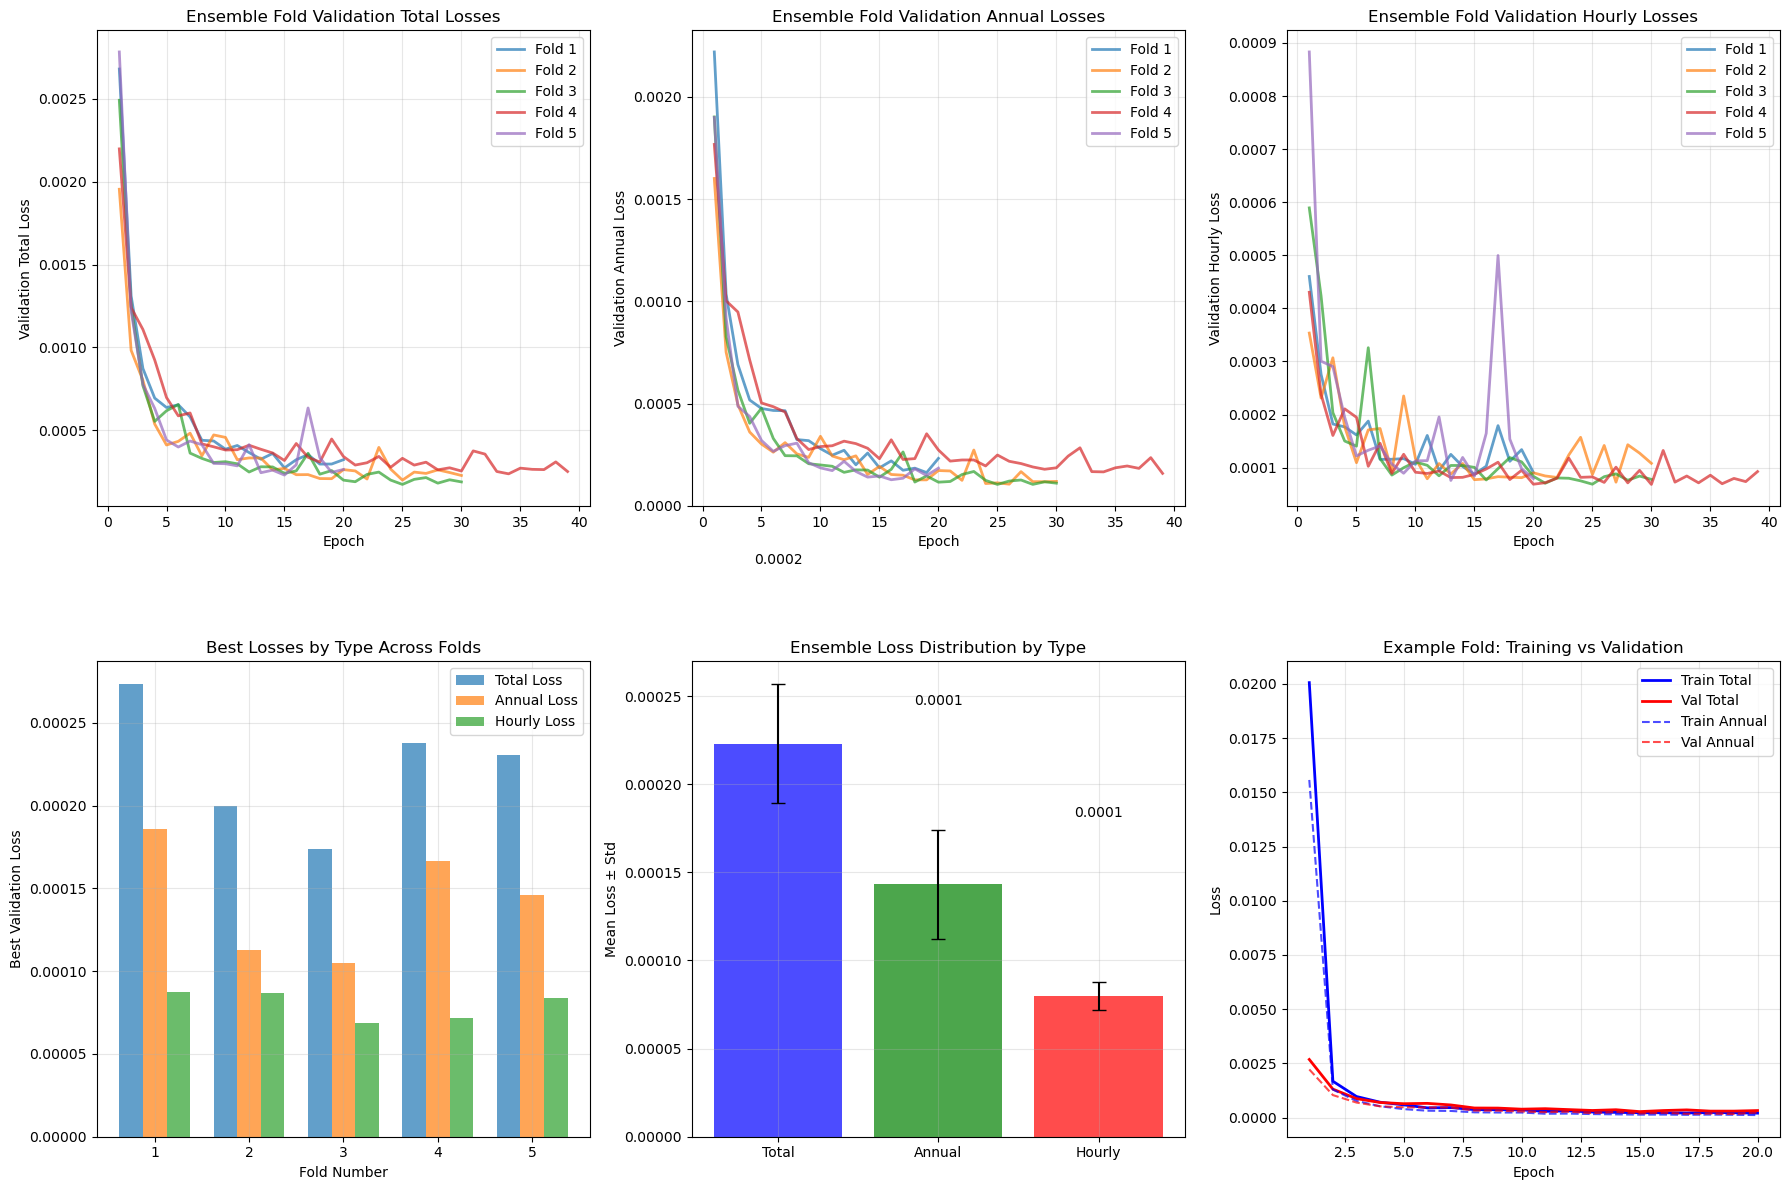


DETAILED ENSEMBLE MODEL SUMMARY
Fold   Best Total Loss Best Annual Loss Best Hourly Loss Best Epoch
--------------------------------------------------------------------------------
1      0.000274        0.000186        0.000088        15        
2      0.000200        0.000113        0.000087        25        
3      0.000174        0.000105        0.000069        25        
4      0.000238        0.000166        0.000071        34        
5      0.000230        0.000146        0.000084        15        
--------------------------------------------------------------------------------
Mean   0.000223        0.000143        0.000080       
Std    0.000034        0.000031        0.000008       
✓ Successfully continued from error point!


In [55]:
### CONTINUE FROM ERROR POINT - JUST ADD THE MISSING FUNCTION

def create_detailed_ensemble_plots(kfold_history, best_params):
    """Create comprehensive ensemble analysis plots with detailed losses"""
    
    plt.figure(figsize=(18, 12))
    
    # Plot 1: All folds validation total losses
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('Ensemble Fold Validation Total Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: All folds validation annual losses
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('Ensemble Fold Validation Annual Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: All folds validation hourly losses
    plt.subplot(2, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_hourly_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('Ensemble Fold Validation Hourly Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Best losses comparison across folds
    plt.subplot(2, 3, 4)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], ensemble_info['best_hourly_losses'], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('Best Losses by Type Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Loss distribution comparison
    plt.subplot(2, 3, 5)
    loss_types = ['Total', 'Annual', 'Hourly']
    means = [ensemble_info['mean_total_loss'], 
             ensemble_info['mean_annual_loss'], 
             ensemble_info['mean_hourly_loss']]
    stds = [ensemble_info['std_total_loss'], 
            ensemble_info['std_annual_loss'], 
            ensemble_info['std_hourly_loss']]
    
    bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
                  color=['blue', 'green', 'red'], capsize=5)
    
    for bar, mean in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.ylabel('Mean Loss ± Std')
    plt.title('Ensemble Loss Distribution by Type')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Training vs Validation losses for first fold (example)
    plt.subplot(2, 3, 6)
    first_fold = kfold_history['fold_losses'][0]
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b-', label='Train Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r-', label='Val Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
            'b--', label='Train Annual', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'r--', label='Val Annual', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Example Fold: Training vs Validation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary
    print("\n" + "="*80)
    print("DETAILED ENSEMBLE MODEL SUMMARY")
    print("="*80)
    print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Annual Loss':<15} {'Best Hourly Loss':<15} {'Best Epoch':<10}")
    print("-" * 80)
    for fold, history in enumerate(kfold_history['fold_losses']):
        print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_val_annual_loss']:<15.6f} "
              f"{history['best_val_hourly_loss']:<15.6f} {history['best_epoch']:<10}")
    
    print("-" * 80)
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<15.6f} {ensemble_info['mean_annual_loss']:<15.6f} "
          f"{ensemble_info['mean_hourly_loss']:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<15.6f} {ensemble_info['std_annual_loss']:<15.6f} "
          f"{ensemble_info['std_hourly_loss']:<15.6f}")

# NOW CONTINUE FROM WHERE IT FAILED
print("Continuing from error point...")

# Check if we have the trained models
if 'ensemble_model' in locals() and 'kfold_history' in locals():
    print("✓ Found trained ensemble model and history")
    print(f"Ensemble has {len(all_models)} models")
    
    # Create the plots that failed
    print("\nCreating detailed ensemble analysis plots...")
    create_detailed_ensemble_plots(kfold_history, best_params_fc)
    
    # For Step 8 compatibility
    final_model = ensemble_model
    training_history = kfold_history['fold_losses'][0]
    
    print("✓ Successfully continued from error point!")
else:
    print("❌ Could not find trained models. Please run the complete Step 7 again.")

Calculating adjusted hourly losses...
✓ Adjusted hourly losses calculated
Continuing from error point with adjusted hourly analysis...
✓ Found trained ensemble model and history
Ensemble has 5 models

Creating detailed ensemble analysis plots...


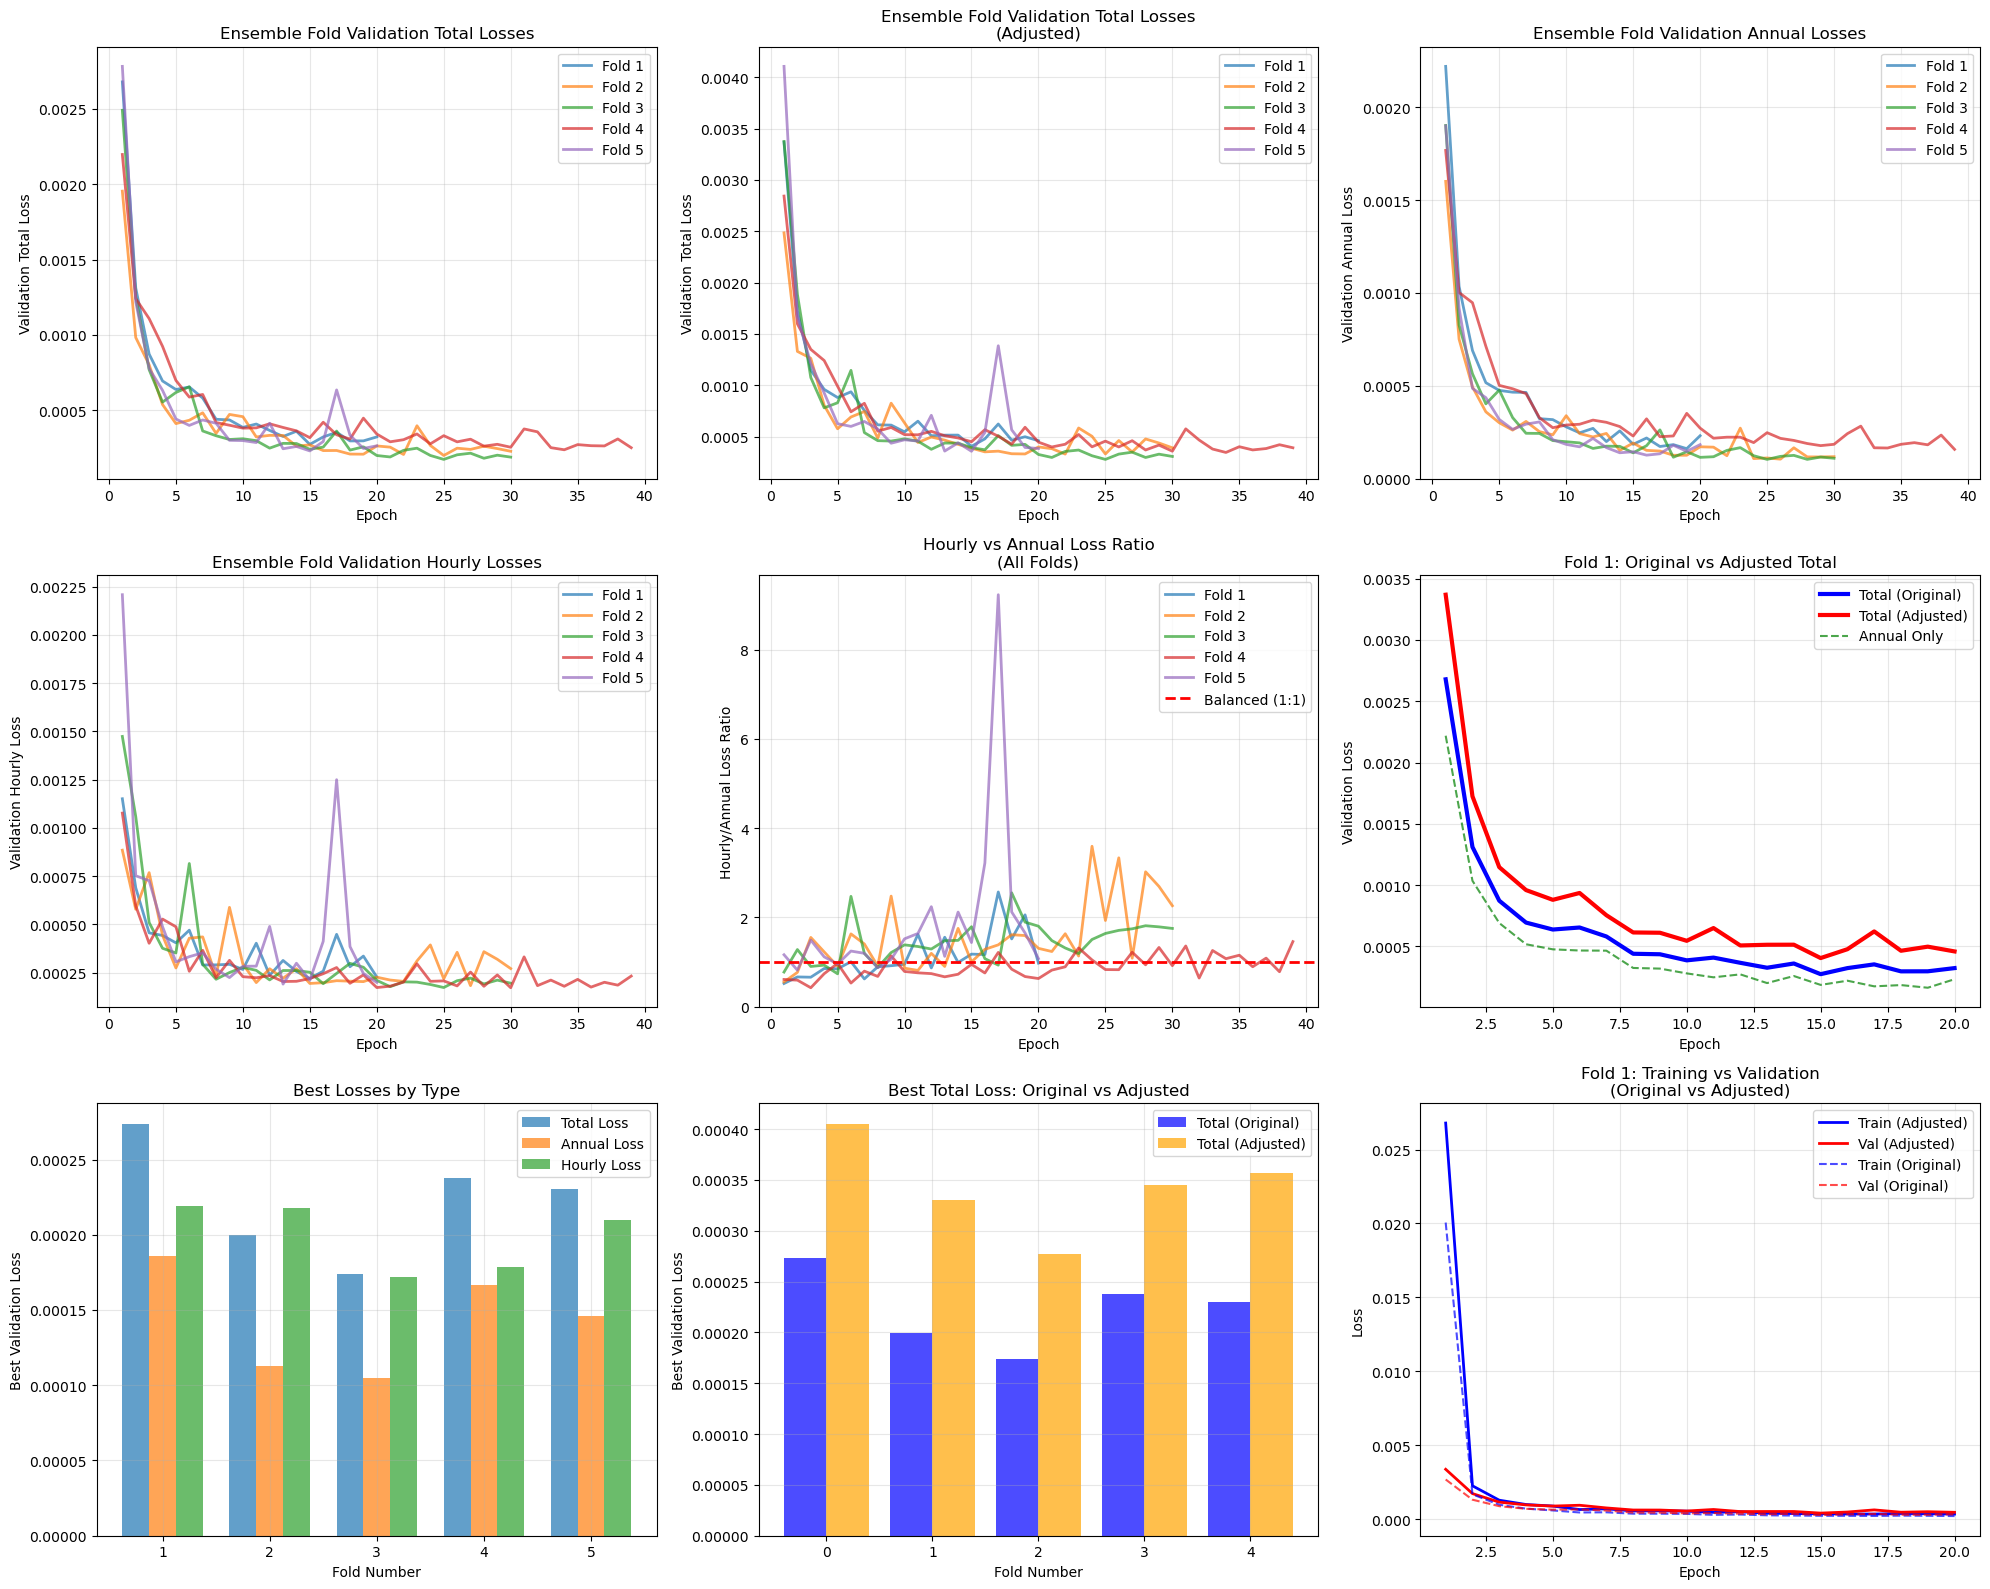


DETAILED ENSEMBLE MODEL SUMMARY
Fold   Best Total   Best Total (Adj) Best Annual     Best Hourly     Best Epoch H/A Ratio   
----------------------------------------------------------------------------------------------------
1      0.000274     0.000405        0.000186        0.000219        15         1.1768      
2      0.000200     0.000330        0.000113        0.000218        25         1.9303      
3      0.000174     0.000277        0.000105        0.000172        25         1.6400      
4      0.000238     0.000345        0.000166        0.000179        34         1.0745      
5      0.000230     0.000356        0.000146        0.000210        15         1.4363      
----------------------------------------------------------------------------------------------------
Mean   0.000223     0.000343        0.000143        0.000200       
Std    0.000034     0.000041        0.000031        0.000020       

PERFORMANCE ANALYSIS:
• Original mean total loss: 0.000223
• Adjusted mean 

In [73]:
### CONTINUE FROM ERROR POINT - WITH HOURLY_LOSS2 ONLY

def create_detailed_ensemble_plots(kfold_history, best_params):
    """Create comprehensive ensemble analysis plots with detailed losses"""
    
    plt.figure(figsize=(20, 16))
    
    # Plot 1: All folds validation total losses
    plt.subplot(3, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('Ensemble Fold Validation Total Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: All folds validation total losses with adjusted hourly
    plt.subplot(3, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate total loss with adjusted hourly
        val_total_adjusted = [history['val_annual_loss'][i] + history['hourly_loss2'][i] 
                            for i in range(len(history['epoch']))]
        plt.plot(history['epoch'], val_total_adjusted, 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('Ensemble Fold Validation Total Losses\n(Adjusted)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: All folds validation annual losses
    plt.subplot(3, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('Ensemble Fold Validation Annual Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: All folds validation adjusted hourly losses
    plt.subplot(3, 3, 4)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['hourly_loss2'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('Ensemble Fold Validation Hourly Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Hourly/Annual Ratio for all folds
    plt.subplot(3, 3, 5)
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate hourly/annual ratio
        hourly_annual_ratio = [history['hourly_loss2'][i] / history['val_annual_loss'][i] 
                             if history['val_annual_loss'][i] > 0 else 0 
                             for i in range(len(history['epoch']))]
        plt.plot(history['epoch'], hourly_annual_ratio, 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Balanced (1:1)')
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('Hourly vs Annual Loss Ratio\n(All Folds)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Comparison of original vs adjusted total losses
    plt.subplot(3, 3, 6)
    first_fold = kfold_history['fold_losses'][0]
    
    # Calculate adjusted total loss for first fold
    val_total_adjusted = [first_fold['val_annual_loss'][i] + first_fold['hourly_loss2'][i] 
                        for i in range(len(first_fold['epoch']))]
    
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'b-', label='Total (Original)', linewidth=3)
    plt.plot(first_fold['epoch'], val_total_adjusted, 
            'r-', label='Total (Adjusted)', linewidth=3)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'g--', label='Annual Only', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Fold 1: Original vs Adjusted Total')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 7: Best losses comparison across folds (ORIGINAL)
    plt.subplot(3, 3, 7)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], [h['best_hourly_loss2'] for h in kfold_history['fold_losses']], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('Best Losses by Type')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 8: Best total losses comparison
    plt.subplot(3, 3, 8)
    # Calculate best adjusted total losses for each fold
    best_total_adjusted = []
    for fold, history in enumerate(kfold_history['fold_losses']):
        total_adjusted = history['best_val_annual_loss'] + history['best_hourly_loss2']
        best_total_adjusted.append(total_adjusted)
    
    width = 0.4
    x_pos = np.arange(len(folds))
    
    plt.bar(x_pos - width/2, ensemble_info['best_total_losses'], 
            width, label='Total (Original)', alpha=0.7, color='blue')
    plt.bar(x_pos + width/2, best_total_adjusted, 
            width, label='Total (Adjusted)', alpha=0.7, color='orange')
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('Best Total Loss: Original vs Adjusted')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 9: Training vs Validation losses for first fold
    plt.subplot(3, 3, 9)
    first_fold = kfold_history['fold_losses'][0]
    
    # Calculate adjusted for training and validation
    train_total_adjusted = [first_fold['train_annual_loss'][i] + first_fold['train_hourly_loss2'][i] 
                          for i in range(len(first_fold['epoch']))]
    val_total_adjusted = [first_fold['val_annual_loss'][i] + first_fold['hourly_loss2'][i] 
                        for i in range(len(first_fold['epoch']))]
    
    plt.plot(first_fold['epoch'], train_total_adjusted, 
            'b-', label='Train (Adjusted)', linewidth=2)
    plt.plot(first_fold['epoch'], val_total_adjusted, 
            'r-', label='Val (Adjusted)', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b--', label='Train (Original)', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r--', label='Val (Original)', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Fold 1: Training vs Validation\n(Original vs Adjusted)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "detailed_ensemble_analysis_adjusted.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary with adjusted hourly analysis
    print("\n" + "="*100)
    print("DETAILED ENSEMBLE MODEL SUMMARY")
    print("="*100)
    print(f"{'Fold':<6} {'Best Total':<12} {'Best Total (Adj)':<15} {'Best Annual':<15} {'Best Hourly':<15} {'Best Epoch':<10} {'H/A Ratio':<12}")
    print("-" * 100)
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        best_total_adjusted = history['best_val_annual_loss'] + history['best_hourly_loss2']
        hourly_annual_ratio = history['best_hourly_loss2'] / history['best_val_annual_loss'] if history['best_val_annual_loss'] > 0 else 0
        
        print(f"{fold+1:<6} {history['best_val_loss']:<12.6f} {best_total_adjusted:<15.6f} "
              f"{history['best_val_annual_loss']:<15.6f} {history['best_hourly_loss2']:<15.6f} "
              f"{history['best_epoch']:<10} {hourly_annual_ratio:<12.4f}")
    
    print("-" * 100)
    
    # Calculate statistics for adjusted hourly
    best_total_adjusted_all = [h['best_val_annual_loss'] + h['best_hourly_loss2'] 
                             for h in kfold_history['fold_losses']]
    best_hourly_adjusted_all = [h['best_hourly_loss2'] for h in kfold_history['fold_losses']]
    
    mean_total_adjusted = np.mean(best_total_adjusted_all)
    std_total_adjusted = np.std(best_total_adjusted_all)
    mean_hourly_adjusted = np.mean(best_hourly_adjusted_all)
    
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<12.6f} {mean_total_adjusted:<15.6f} "
          f"{ensemble_info['mean_annual_loss']:<15.6f} {mean_hourly_adjusted:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<12.6f} {std_total_adjusted:<15.6f} "
          f"{ensemble_info['std_annual_loss']:<15.6f} {np.std(best_hourly_adjusted_all):<15.6f}")
    
    # Print analysis
    print(f"\nPERFORMANCE ANALYSIS:")
    print(f"• Original mean total loss: {ensemble_info['mean_total_loss']:.6f}")
    print(f"• Adjusted mean total loss: {mean_total_adjusted:.6f}")
    print(f"• Absolute difference: {(mean_total_adjusted - ensemble_info['mean_total_loss']):.6f}")
    
    print(f"\nLOSS CONTRIBUTION:")
    print(f"• Annual loss: {ensemble_info['mean_annual_loss']:.6f} ({ensemble_info['mean_annual_loss']/ensemble_info['mean_total_loss']*100:.1f}% of original total)")
    print(f"• Hourly loss: {mean_hourly_adjusted:.6f} ({mean_hourly_adjusted/mean_total_adjusted*100:.1f}% of adjusted total)")
    
    # Check if adjustment changes the "best" fold
    original_best_fold = np.argmin(ensemble_info['best_total_losses']) + 1
    adjusted_best_fold = np.argmin(best_total_adjusted_all) + 1
    
    if original_best_fold != adjusted_best_fold:
        print(f"\nRANKING CHANGE: Best fold changed from {original_best_fold} to {adjusted_best_fold}")
    else:
        print(f"\nNo ranking change: Fold {original_best_fold} remains best")

# First, let's add adjusted hourly losses to our kfold_history
print("Calculating adjusted hourly losses...")

# Calculate adjusted hourly losses as 2.5 times the original hourly losses
for fold_history in kfold_history['fold_losses']:
    # For validation losses
    fold_history['hourly_loss2'] = [2.5 * loss for loss in fold_history['val_hourly_loss']]
    fold_history['best_hourly_loss2'] = 2.5 * fold_history['best_val_hourly_loss']
    
    # For training losses
    fold_history['train_hourly_loss2'] = [2.5 * loss for loss in fold_history['train_hourly_loss']]

# Update ensemble info with adjusted statistics
best_hourly_adjusted_all = [2.5 * h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
kfold_history['ensemble_info']['best_hourly_loss2'] = best_hourly_adjusted_all
kfold_history['ensemble_info']['mean_hourly_loss2'] = np.mean(best_hourly_adjusted_all)
kfold_history['ensemble_info']['std_hourly_loss2'] = np.std(best_hourly_adjusted_all)

print("✓ Adjusted hourly losses calculated")

# NOW CONTINUE FROM WHERE IT FAILED
print("Continuing from error point with adjusted hourly analysis...")

# Check if we have the trained models
if 'ensemble_model' in locals() and 'kfold_history' in locals():
    print("✓ Found trained ensemble model and history")
    print(f"Ensemble has {len(all_models)} models")
    
    # Create the enhanced plots with adjusted hourly
    print("\nCreating detailed ensemble analysis plots...")
    create_detailed_ensemble_plots(kfold_history, best_params_fc)
    
    # For Step 8 compatibility
    final_model = ensemble_model
    training_history = kfold_history['fold_losses'][0]
    
    print("✓ Successfully continued from error point!")
else:
    print("❌ Could not find trained models. Please run the complete Step 7 again.")

Preparing FC ensemble analysis with adjusted hourly losses...
Continuing from error point with FC ensemble analysis...
✓ Found trained FC ensemble model and history
Ensemble has 5 models
Model Architecture: Fully Connected ANN

Creating detailed FC ensemble analysis plots...


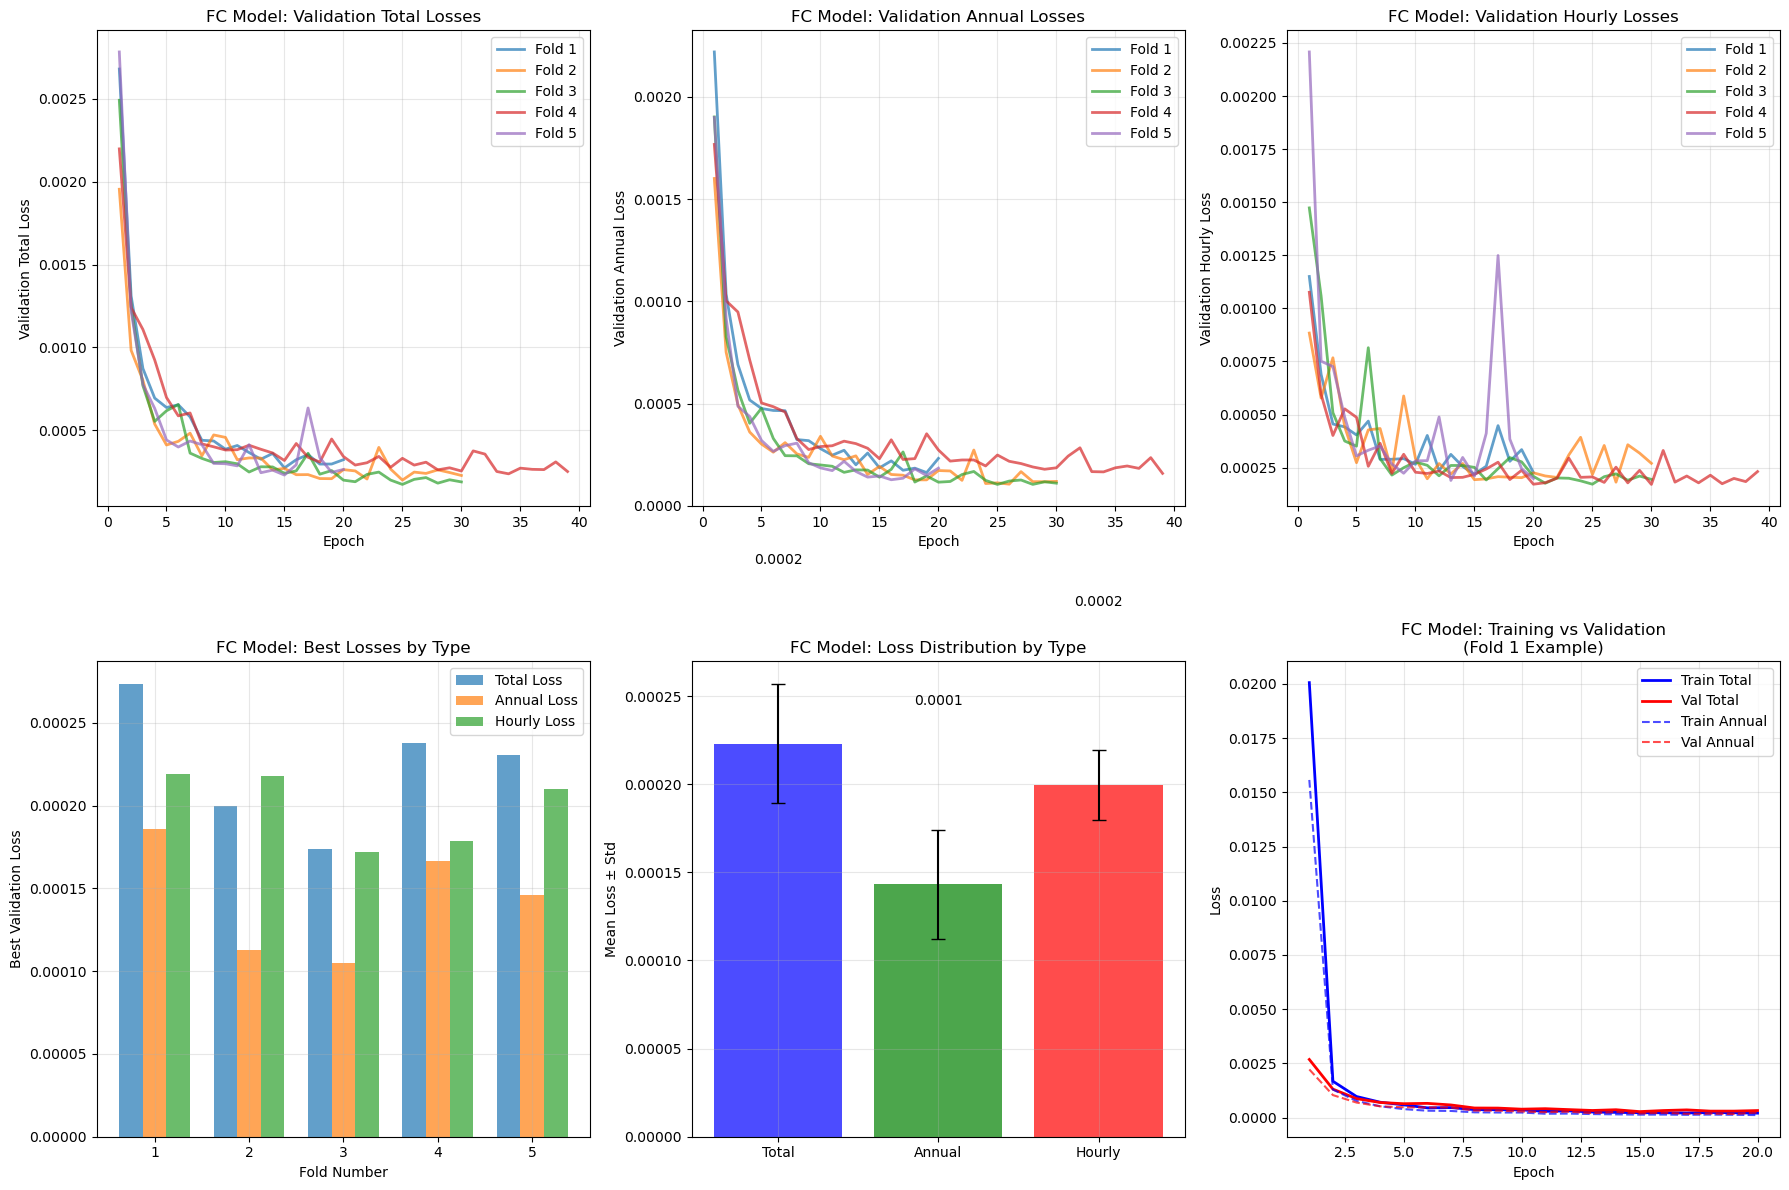


FC ENSEMBLE MODEL SUMMARY
Fold   Best Total   Best Annual     Best Hourly     Best Epoch
------------------------------------------------------------------------------------------
1      0.000274     0.000186        0.000219        15        
2      0.000200     0.000113        0.000218        25        
3      0.000174     0.000105        0.000172        25        
4      0.000238     0.000166        0.000179        34        
5      0.000230     0.000146        0.000210        15        
------------------------------------------------------------------------------------------
Mean   0.000223     0.000143        0.000200       
Std    0.000034     0.000031        0.000020       
✓ Successfully continued from error point with FC ensemble analysis!


In [81]:
### CONTINUE FROM ERROR POINT - WITH ADJUSTED HOURLY LOSSES

def create_detailed_ensemble_plots_fc(kfold_history, best_params):
    """Create comprehensive ensemble analysis plots with detailed losses for FC model"""
    
    plt.figure(figsize=(18, 12))
    
    # Plot 1: All folds validation total losses
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('FC Model: Validation Total Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: All folds validation annual losses
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('FC Model: Validation Annual Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: All folds validation adjusted hourly losses
    plt.subplot(2, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['hourly_loss2'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('FC Model: Validation Hourly Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Best losses comparison across folds
    plt.subplot(2, 3, 4)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], ensemble_info['best_hourly_loss2'], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('FC Model: Best Losses by Type')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Loss distribution comparison
    plt.subplot(2, 3, 5)
    loss_types = ['Total', 'Annual', 'Hourly']
    means = [ensemble_info['mean_total_loss'], 
             ensemble_info['mean_annual_loss'], 
             ensemble_info['mean_hourly_loss2']]
    stds = [ensemble_info['std_total_loss'], 
            ensemble_info['std_annual_loss'], 
            ensemble_info['std_hourly_loss2']]
    
    bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
                  color=['blue', 'green', 'red'], capsize=5)
    
    for bar, mean in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.ylabel('Mean Loss ± Std')
    plt.title('FC Model: Loss Distribution by Type')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Training vs Validation losses for first fold (example)
    plt.subplot(2, 3, 6)
    first_fold = kfold_history['fold_losses'][0]
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b-', label='Train Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r-', label='Val Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
            'b--', label='Train Annual', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'r--', label='Val Annual', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('FC Model: Training vs Validation\n(Fold 1 Example)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fc_detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary with adjusted hourly losses
    print("\n" + "="*90)
    print("FC ENSEMBLE MODEL SUMMARY")
    print("="*90)
    print(f"{'Fold':<6} {'Best Total':<12} {'Best Annual':<15} {'Best Hourly':<15} {'Best Epoch':<10}")
    print("-" * 90)
    for fold, history in enumerate(kfold_history['fold_losses']):
        print(f"{fold+1:<6} {history['best_val_loss']:<12.6f} {history['best_val_annual_loss']:<15.6f} "
              f"{history['best_hourly_loss2']:<15.6f} {history['best_epoch']:<10}")
    
    print("-" * 90)
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<12.6f} {ensemble_info['mean_annual_loss']:<15.6f} "
          f"{ensemble_info['mean_hourly_loss2']:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<12.6f} {ensemble_info['std_annual_loss']:<15.6f} "
          f"{ensemble_info['std_hourly_loss2']:<15.6f}")

# First, let's add adjusted hourly losses to our kfold_history if not already present
print("Preparing FC ensemble analysis with adjusted hourly losses...")

# Check if we need to calculate adjusted hourly losses
if 'hourly_loss2' not in kfold_history['fold_losses'][0]:
    print("Calculating adjusted hourly losses (2.5x original)...")
    for fold_history in kfold_history['fold_losses']:
        # For validation losses
        fold_history['hourly_loss2'] = [2.5 * loss for loss in fold_history['val_hourly_loss']]
        fold_history['best_hourly_loss2'] = 2.5 * fold_history['best_val_hourly_loss']
        
        # For training losses
        fold_history['train_hourly_loss2'] = [2.5 * loss for loss in fold_history['train_hourly_loss']]
    
    # Update ensemble info with adjusted statistics
    best_hourly_loss2_all = [2.5 * h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
    kfold_history['ensemble_info']['best_hourly_loss2'] = best_hourly_loss2_all
    kfold_history['ensemble_info']['mean_hourly_loss2'] = np.mean(best_hourly_loss2_all)
    kfold_history['ensemble_info']['std_hourly_loss2'] = np.std(best_hourly_loss2_all)
    
    print("✓ Adjusted hourly losses calculated and added to history")

# NOW CONTINUE FROM WHERE IT FAILED
print("Continuing from error point with FC ensemble analysis...")

# Check if we have the trained models
if 'ensemble_model' in locals() and 'kfold_history' in locals():
    print("✓ Found trained FC ensemble model and history")
    print(f"Ensemble has {len(all_models)} models")
    print(f"Model Architecture: Fully Connected ANN")
    
    # Create the plots with adjusted hourly losses
    print("\nCreating detailed FC ensemble analysis plots...")
    create_detailed_ensemble_plots_fc(kfold_history, best_params_fc)
    
    # For Step 8 compatibility
    final_model = ensemble_model
    training_history = kfold_history['fold_losses'][0]
    
    print("✓ Successfully continued from error point with FC ensemble analysis!")
else:
    print("❌ Could not find trained FC ensemble models. Please run the complete Step 7 first.")

STEP 8: FC ENSEMBLE RESULTS SAVING AND EVALUATION
Evaluating FC ensemble model...
Saving FC ensemble training results and metrics...
Loading normalization parameters for denormalization...
Evaluating FC ensemble model on test set...
Denormalizing ensemble outputs to real units...
Creating prediction vs true plots for FC ensemble...


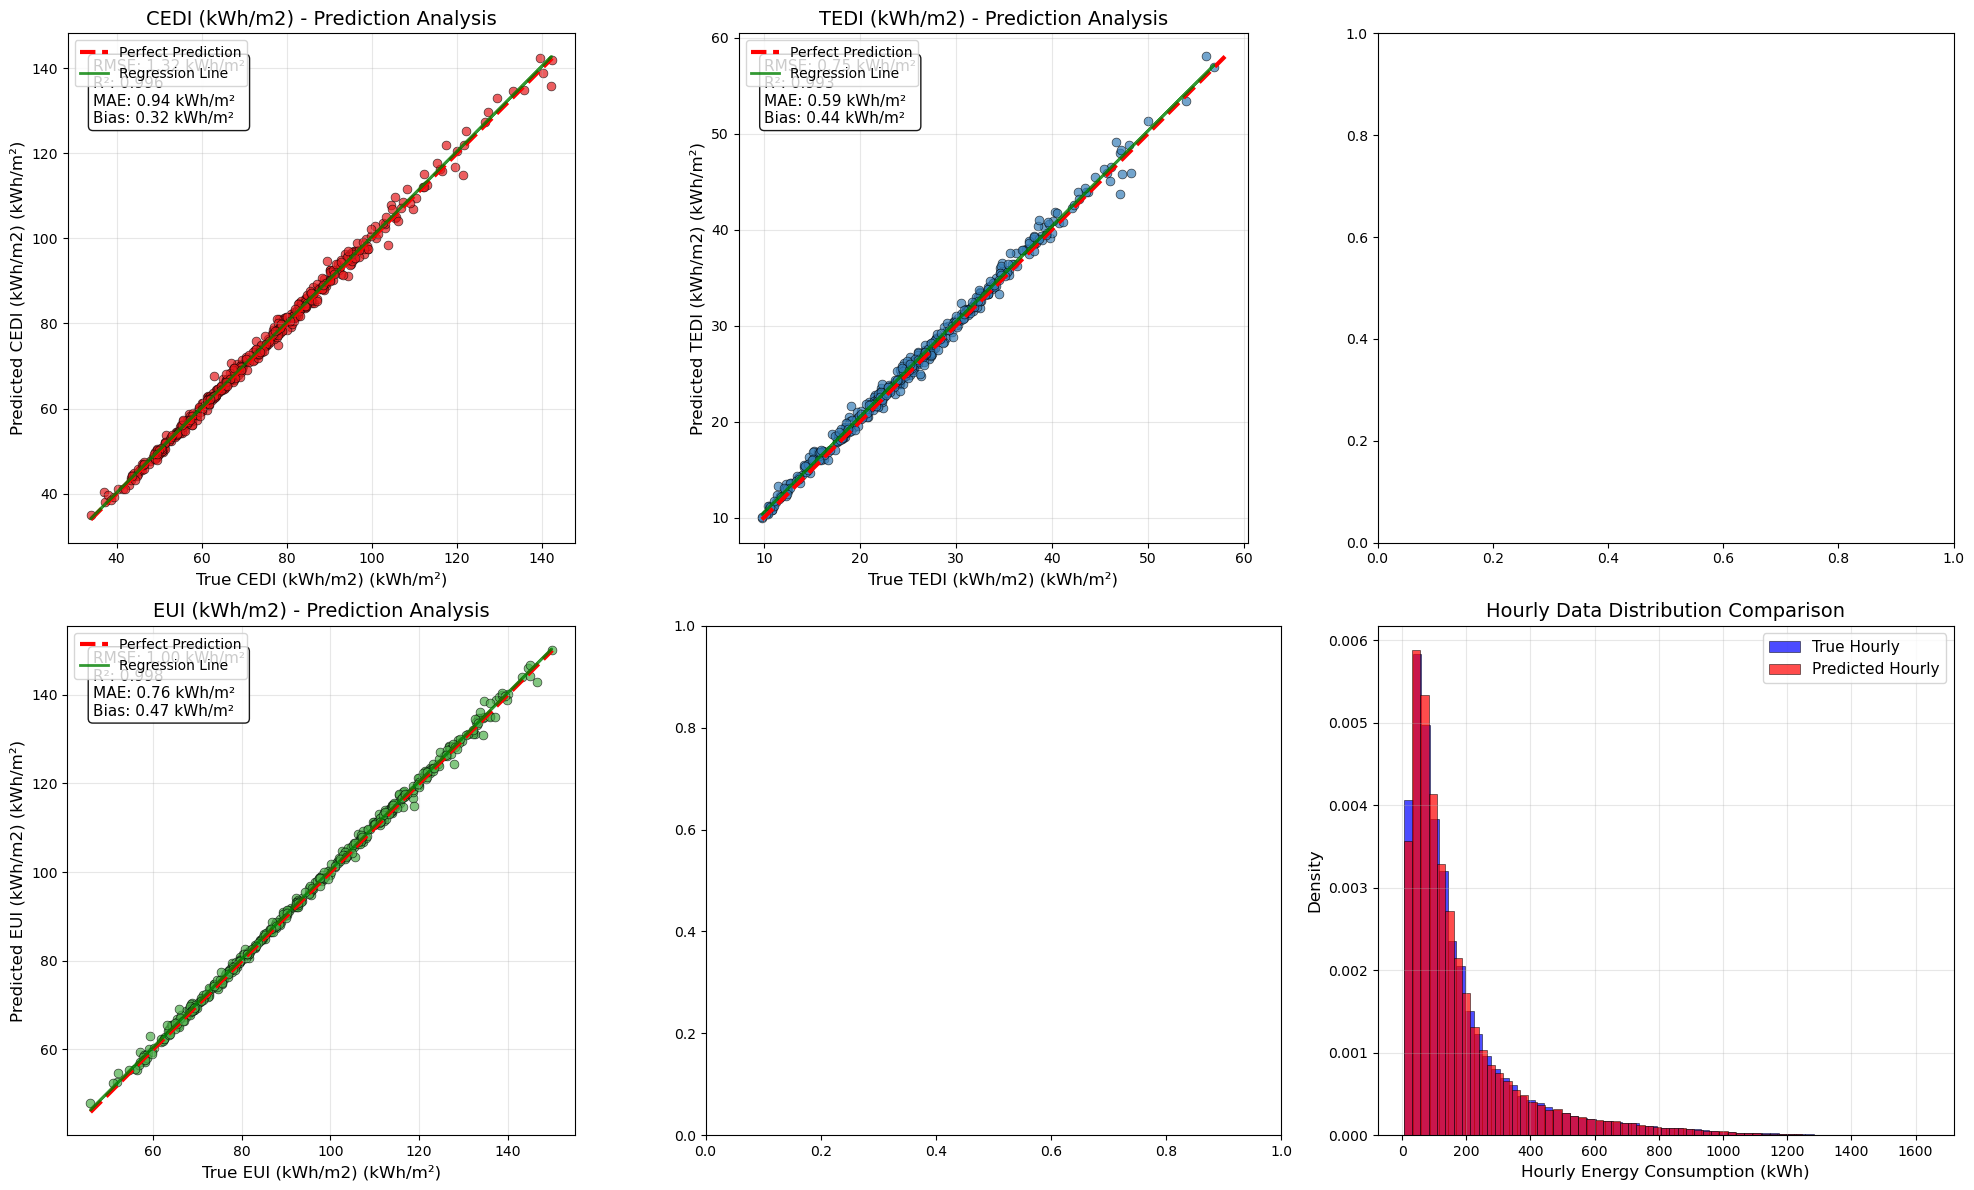

Creating individual detailed plots for FC ensemble...


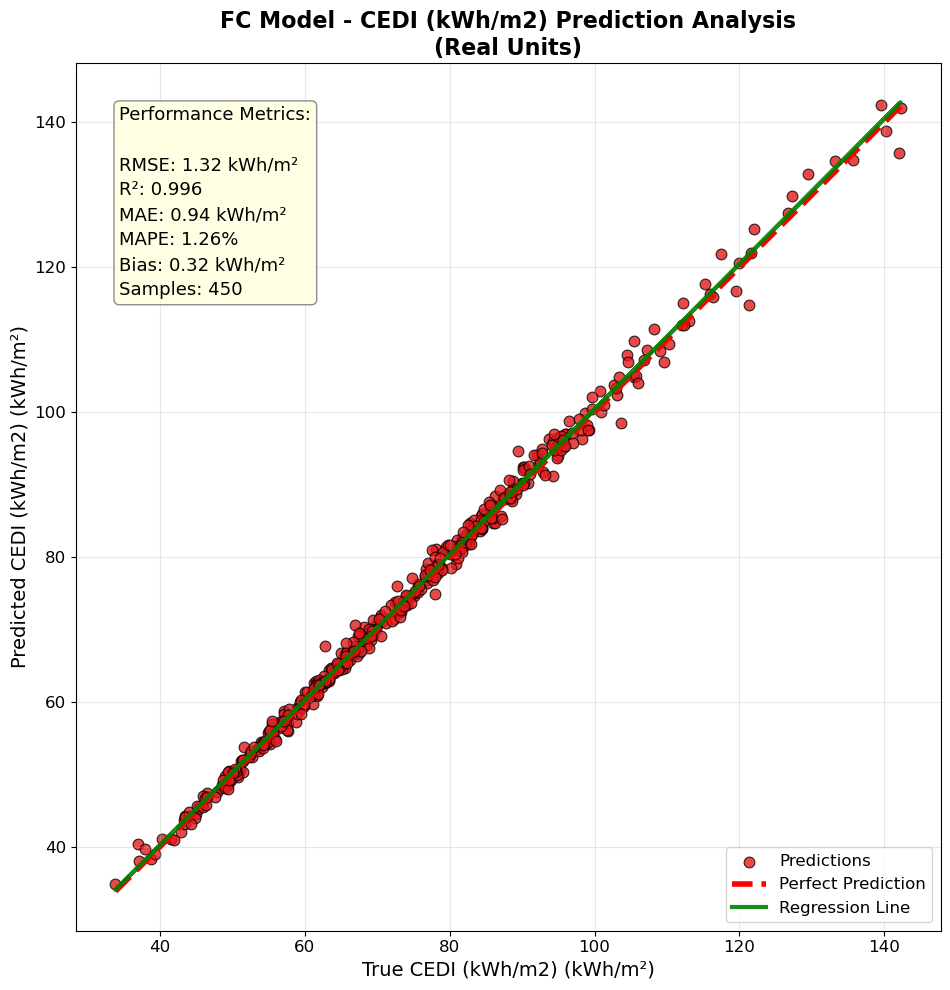

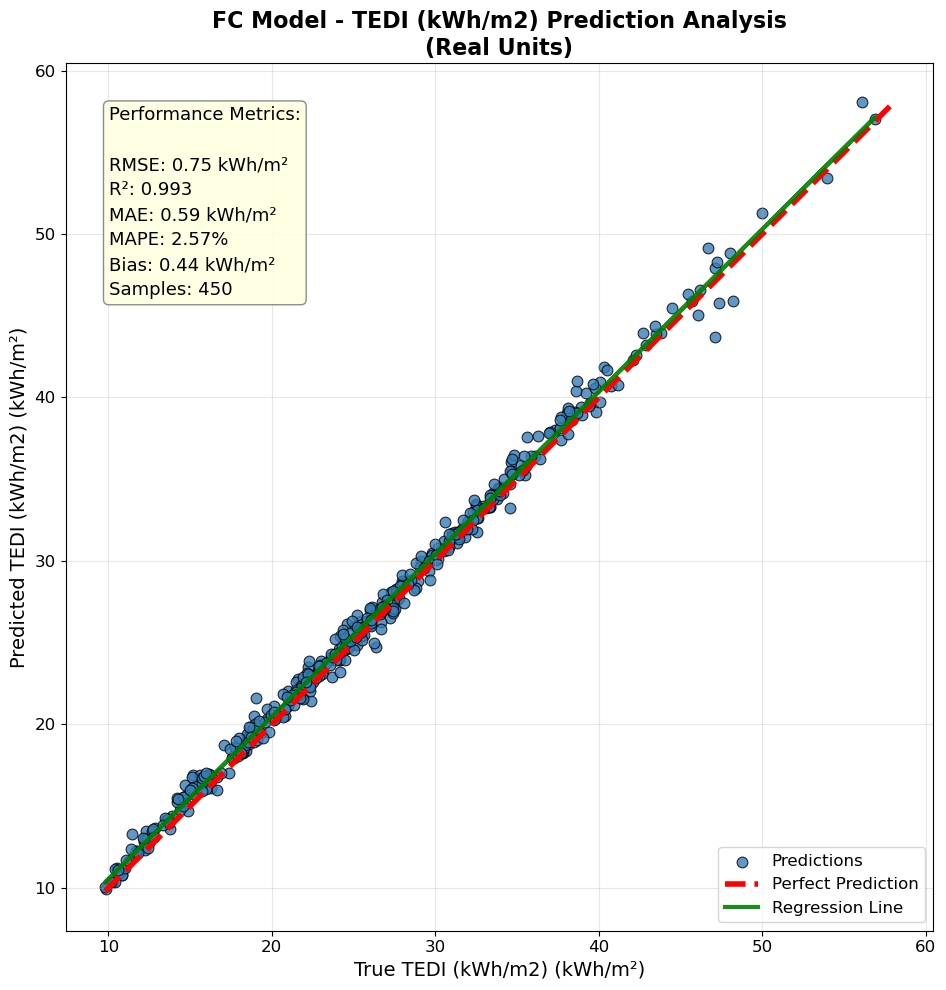

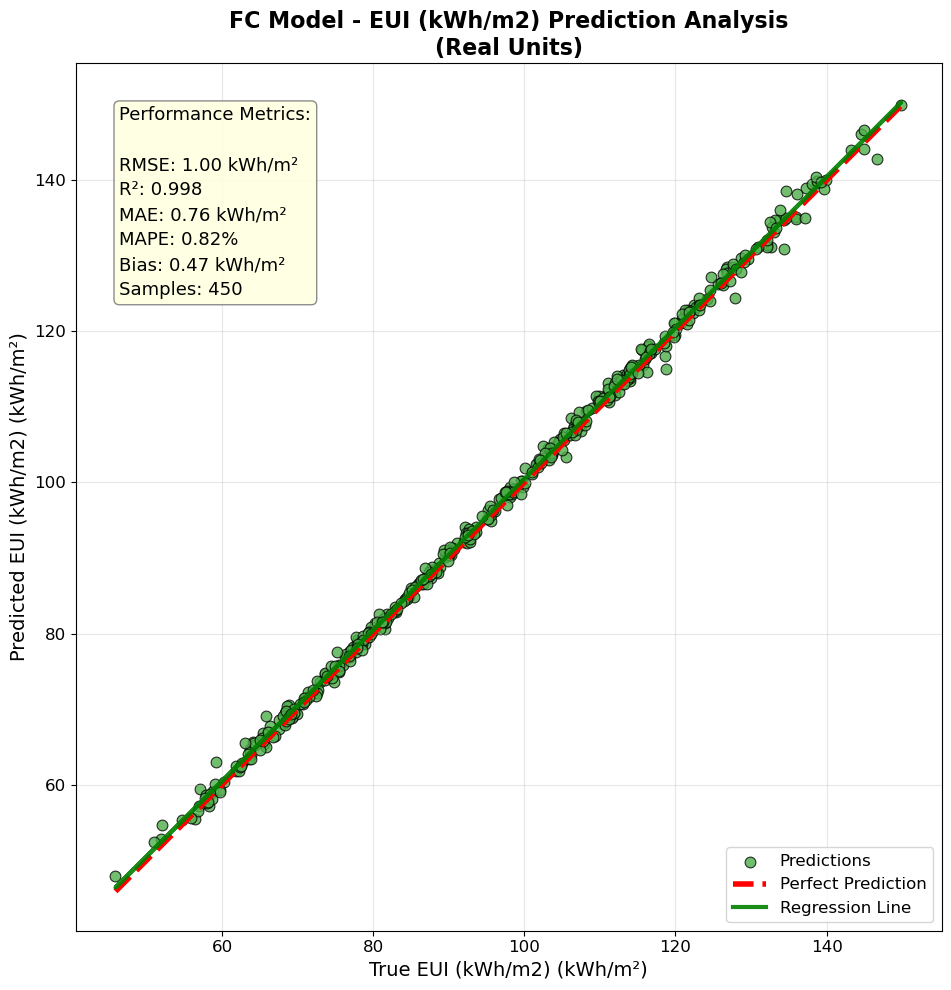

✓ FC Ensemble results saved to C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output
✓ FC Ensemble mean validation loss: 0.000223
✓ FC Ensemble test RMSE: 1.05 kWh/m²
✓ FC Ensemble test R²: 0.9956

FC ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):
CEDI (kWh/m2)             | RMSE:    1.32 kWh/m² | R²:  0.996 | MAE:    0.94 kWh/m²
TEDI (kWh/m2)             | RMSE:    0.75 kWh/m² | R²:  0.993 | MAE:    0.59 kWh/m²
EUI (kWh/m2)              | RMSE:    1.00 kWh/m² | R²:  0.998 | MAE:    0.76 kWh/m²

FC Ensemble Stability: ±0.000034
✓ Step 8 completed successfully!

FC MODEL TRAINING COMPLETED SUCCESSFULLY!
Next: Ask for Step 8.1 when ready


In [57]:
### STEP 8: ENSEMBLE RESULTS SAVING WITH PREDICTION PLOTS (FC VERSION)
### =============================================================================

def load_normalization_params():
    """Load normalization parameters from saved file"""
    with open(NORM_JSON, 'r') as f:
        norm_params = json.load(f)
    return norm_params

def calculate_detailed_metrics(true_ann, pred_ann, true_hour, pred_hour):
    """Calculate comprehensive metrics for all outputs (using real units)"""
    metrics = {}
    
    # Annual metrics - overall
    metrics['annual_rmse'] = float(np.sqrt(mean_squared_error(true_ann, pred_ann)))
    metrics['annual_mae'] = float(mean_absolute_error(true_ann, pred_ann))
    metrics['annual_r2'] = float(r2_score(true_ann, pred_ann))
    
    # Annual metrics - per output
    for i, col in enumerate(ANNUAL_COLS):
        metrics[f'{col}_rmse'] = float(np.sqrt(mean_squared_error(true_ann[:, i], pred_ann[:, i])))
        metrics[f'{col}_mae'] = float(mean_absolute_error(true_ann[:, i], pred_ann[:, i]))
        metrics[f'{col}_r2'] = float(r2_score(true_ann[:, i], pred_ann[:, i]))
    
    # Hourly metrics
    hourly_true_flat = true_hour.reshape(-1)
    hourly_pred_flat = pred_hour.reshape(-1)
    
    metrics['hourly_rmse'] = float(np.sqrt(mean_squared_error(hourly_true_flat, hourly_pred_flat)))
    metrics['hourly_mae'] = float(mean_absolute_error(hourly_true_flat, hourly_pred_flat))
    metrics['hourly_r2'] = float(r2_score(hourly_true_flat, hourly_pred_flat))
    
    return metrics

def create_prediction_vs_true_comprehensive(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, metrics):
    """Create comprehensive prediction vs true plots for all annual parameters"""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Plot each annual parameter
    for i, col in enumerate(ANNUAL_COLS):
        row = i // 2
        col_pos = i % 2
        
        true_values = ann_true_real[:, i]
        pred_values = ann_pred_real[:, i]
        
        # Calculate perfect prediction line
        min_val = min(true_values.min(), pred_values.min())
        max_val = max(true_values.max(), pred_values.max())
        perfect_line = np.linspace(min_val, max_val, 100)
        
        # Scatter plot with enhanced styling
        scatter = axes[row, col_pos].scatter(true_values, pred_values, alpha=0.7, s=40, 
                                           color=plt.cm.Set1(i), edgecolor='black', linewidth=0.5)
        axes[row, col_pos].plot(perfect_line, perfect_line, 'r--', linewidth=3, label='Perfect Prediction')
        
        # Add regression line
        z = np.polyfit(true_values, pred_values, 1)
        p = np.poly1d(z)
        axes[row, col_pos].plot(true_values, p(true_values), "g-", linewidth=2, alpha=0.8, label='Regression Line')
        
        # Enhanced statistics
        rmse = metrics[f'{col}_rmse']
        r2 = metrics[f'{col}_r2']
        mae = metrics[f'{col}_mae']
        bias = np.mean(pred_values - true_values)
        
        stats_text = f'RMSE: {rmse:.2f} kWh/m²\nR²: {r2:.3f}\nMAE: {mae:.2f} kWh/m²\nBias: {bias:.2f} kWh/m²'
        
        axes[row, col_pos].text(0.05, 0.95, stats_text, transform=axes[row, col_pos].transAxes, 
                               verticalalignment='top', fontsize=11,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        axes[row, col_pos].set_xlabel(f'True {col} (kWh/m²)', fontsize=12)
        axes[row, col_pos].set_ylabel(f'Predicted {col} (kWh/m²)', fontsize=12)
        axes[row, col_pos].set_title(f'{col} - Prediction Analysis', fontsize=14)
        axes[row, col_pos].legend(fontsize=10)
        axes[row, col_pos].grid(True, alpha=0.3)
        
        # Set equal aspect ratio for better visualization
        axes[row, col_pos].set_aspect('equal', adjustable='box')
    
    # Hourly data distribution comparison
    axes[1, 2].hist(hour_true_real.flatten(), bins=60, alpha=0.7, label='True Hourly', 
                   color='blue', density=True, edgecolor='black', linewidth=0.5)
    axes[1, 2].hist(hour_pred_real.flatten(), bins=60, alpha=0.7, label='Predicted Hourly', 
                   color='red', density=True, edgecolor='black', linewidth=0.5)
    axes[1, 2].set_xlabel('Hourly Energy Consumption (kWh)', fontsize=12)
    axes[1, 2].set_ylabel('Density', fontsize=12)
    axes[1, 2].set_title('Hourly Data Distribution Comparison', fontsize=14)
    axes[1, 2].legend(fontsize=11)
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fc_comprehensive_predictions_hq.png", dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()

def create_individual_prediction_plots(ann_true_real, ann_pred_real, metrics):
    """Create individual high-quality plots for each annual parameter"""
    
    for i, col in enumerate(ANNUAL_COLS):
        plt.figure(figsize=(12, 10))
        
        true_values = ann_true_real[:, i]
        pred_values = ann_pred_real[:, i]
        
        # Create main scatter plot
        plt.scatter(true_values, pred_values, alpha=0.8, s=60, 
                   color=plt.cm.Set1(i), edgecolor='black', linewidth=0.8, label='Predictions')
        
        # Perfect prediction line
        min_val = min(true_values.min(), pred_values.min())
        max_val = max(true_values.max(), pred_values.max())
        perfect_line = np.linspace(min_val, max_val, 100)
        plt.plot(perfect_line, perfect_line, 'r--', linewidth=4, label='Perfect Prediction')
        
        # Regression line with confidence interval
        z = np.polyfit(true_values, pred_values, 1)
        p = np.poly1d(z)
        plt.plot(true_values, p(true_values), "g-", linewidth=3, alpha=0.9, label='Regression Line')
        
        # Enhanced statistics box
        rmse = metrics[f'{col}_rmse']
        r2 = metrics[f'{col}_r2']
        mae = metrics[f'{col}_mae']
        mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100
        bias = np.mean(pred_values - true_values)
        
        stats_text = f'Performance Metrics:\n\n'
        stats_text += f'RMSE: {rmse:.2f} kWh/m²\n'
        stats_text += f'R²: {r2:.3f}\n'
        stats_text += f'MAE: {mae:.2f} kWh/m²\n'
        stats_text += f'MAPE: {mape:.2f}%\n'
        stats_text += f'Bias: {bias:.2f} kWh/m²\n'
        stats_text += f'Samples: {len(true_values)}'
        
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                verticalalignment='top', fontsize=13, linespacing=1.5,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='gray'))
        
        plt.xlabel(f'True {col} (kWh/m²)', fontsize=14)
        plt.ylabel(f'Predicted {col} (kWh/m²)', fontsize=14)
        plt.title(f'FC Model - {col} Prediction Analysis\n(Real Units)', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12, loc='lower right')
        plt.grid(True, alpha=0.3)
        
        # Set equal aspect ratio
        plt.gca().set_aspect('equal', adjustable='box')
        
        # Enhanced styling
        plt.gca().tick_params(axis='both', which='major', labelsize=12)
        
        # Clean filename
        safe_col_name = col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
        filename = OUTPUT_DIR / f"fc_individual_{safe_col_name}_predictions_hq.png"
        
        plt.tight_layout()
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='white')
        plt.show()

def denormalize_annual_outputs_ensemble(norm_ann, annual_ranges):
    """Denormalize annual outputs for ensemble predictions"""
    denorm_ann = norm_ann.copy()
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        denorm_ann[:, i] = norm_ann[:, i] * (vmax - vmin) + vmin
    return denorm_ann

def denormalize_hourly_outputs_ensemble(norm_hour, hourly_min, hourly_max):
    """Denormalize hourly outputs for ensemble predictions"""
    return norm_hour * (hourly_max - hourly_min) + hourly_min

def evaluate_ensemble_model_fc(ensemble_model, X_test, y_ann_test, y_hour_test):
    """Evaluate FC ensemble model on test set"""
    print("Evaluating FC ensemble model on test set...")
    
    # Create test dataset and loader
    test_dataset = BuildingDatasetFC(X_test, y_ann_test, y_hour_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    ensemble_model.eval()
    
    all_ann_true = []
    all_ann_pred = []
    all_hour_true = []
    all_hour_pred = []
    
    with torch.no_grad():
        for X, y_ann, y_hour in test_loader:
            X = X.to(DEVICE)
            
            # Ensemble prediction (averages across all models)
            pred_ann, pred_hour = ensemble_model.predict(X)
            
            all_ann_true.append(y_ann.numpy())
            all_ann_pred.append(pred_ann.cpu().numpy())
            all_hour_true.append(y_hour.numpy())
            all_hour_pred.append(pred_hour.cpu().numpy())
    
    # Stack all predictions
    ann_true = np.vstack(all_ann_true)
    ann_pred = np.vstack(all_ann_pred)
    hour_true = np.vstack(all_hour_true)
    hour_pred = np.vstack(all_hour_pred)
    
    return ann_true, ann_pred, hour_true, hour_pred

def save_ensemble_results_fc(ensemble_model, kfold_history, best_params, X_test, y_ann_test, y_hour_test):
    """Save FC ensemble training results with comprehensive analysis"""
    print("Saving FC ensemble training results and metrics...")
    
    # Ensure output directory exists
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    
    # Load normalization parameters
    print("Loading normalization parameters for denormalization...")
    norm_params = load_normalization_params()
    annual_ranges = norm_params['annual_ranges']
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    
    # Evaluate ensemble on test set
    ann_true_norm, ann_pred_norm, hour_true_norm, hour_pred_norm = evaluate_ensemble_model_fc(
        ensemble_model, X_test, y_ann_test, y_hour_test
    )
    
    # DENORMALIZE to get real values
    print("Denormalizing ensemble outputs to real units...")
    ann_true_real = denormalize_annual_outputs_ensemble(ann_true_norm, annual_ranges)
    ann_pred_real = denormalize_annual_outputs_ensemble(ann_pred_norm, annual_ranges)
    hour_true_real = denormalize_hourly_outputs_ensemble(hour_true_norm, hourly_min, hourly_max)
    hour_pred_real = denormalize_hourly_outputs_ensemble(hour_pred_norm, hourly_min, hourly_max)
    
    # Calculate detailed metrics using REAL values
    test_metrics = calculate_detailed_metrics(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real)
    
    # CREATE ALL HIGH-QUALITY PLOTS
    print("Creating prediction vs true plots for FC ensemble...")
    create_prediction_vs_true_comprehensive(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, test_metrics)
    
    print("Creating individual detailed plots for FC ensemble...")
    create_individual_prediction_plots(ann_true_real, ann_pred_real, test_metrics)
    
    # Enhanced training history with ensemble info
    enhanced_history = {
        'kfold_curves': kfold_history['fold_losses'],
        'ensemble_info': kfold_history['ensemble_info'],
        'test_metrics': test_metrics,
        'model_architecture': 'Fully Connected ANN'
    }
    
    # Save enhanced training history
    with open(OUTPUT_DIR / "fc_training_history.json", 'w') as f:
        json.dump(enhanced_history, f, indent=4)
    
    # Enhanced final metrics
    final_metrics = {
        'best_hyperparameters': best_params,
        'ensemble_configuration': kfold_history['ensemble_info'],
        'final_test_metrics': test_metrics,
        'training_summary': {
            'random_seed': RANDOM_SEED,
            'device': str(DEVICE),
            'total_models': kfold_history['ensemble_info']['n_models'],
            'mean_val_loss': kfold_history['ensemble_info']['mean_total_loss'],
            'model_type': 'Fully Connected ANN'
        },
        'model_performance': {
            'test_rmse': test_metrics['annual_rmse'],
            'test_r2': test_metrics['annual_r2'],
            'ensemble_stability': kfold_history['ensemble_info']['std_total_loss']
        }
    }
    
    with open(OUTPUT_DIR / "fc_performance_metrics.json", 'w') as f:
        json.dump(final_metrics, f, indent=4)
    
    # Enhanced model info for ensemble
    model_info = {
        'model_type': 'fc_ensemble',
        'architecture': 'Fully Connected ANN',
        'n_models': kfold_history['ensemble_info']['n_models'],
        'model_files': [f"fc_ensemble_model_fold_{i+1}.pth" for i in range(kfold_history['ensemble_info']['n_models'])],
        'norm_file': str(NORM_JSON.name),
        'training_history_file': "fc_training_history.json",
        'metrics_file': "fc_performance_metrics.json",
        'param_names': PARAM_NAMES_EXPECTED,
        'annual_cols': ANNUAL_COLS,
        'model_architecture': {
            'in_dim': X_test.shape[1],
            'latent_dim': best_params["latent_dim"],
            'hidden_dim': best_params["hidden_dim"],
            'ann_out': y_ann_test.shape[1],
            'hour_out': 8760
        },
        'ensemble_info': kfold_history['ensemble_info']
    }
    
    with open(OUTPUT_DIR / "fc_model_info.json", 'w') as f:
        json.dump(model_info, f, indent=4)
    
    print(f"✓ FC Ensemble results saved to {OUTPUT_DIR}")
    print(f"✓ FC Ensemble mean validation loss: {kfold_history['ensemble_info']['mean_total_loss']:.6f}")
    print(f"✓ FC Ensemble test RMSE: {test_metrics['annual_rmse']:.2f} kWh/m²")
    print(f"✓ FC Ensemble test R²: {test_metrics['annual_r2']:.4f}")
    
    # Print detailed performance for each annual parameter
    print("\n" + "="*70)
    print("FC ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):")
    print("="*70)
    for col in ANNUAL_COLS:
        rmse = test_metrics[f'{col}_rmse']
        r2 = test_metrics[f'{col}_r2']
        mae = test_metrics[f'{col}_mae']
        print(f"{col:25} | RMSE: {rmse:7.2f} kWh/m² | R²: {r2:6.3f} | MAE: {mae:7.2f} kWh/m²")
    
    # Print ensemble stability
    print(f"\nFC Ensemble Stability: ±{kfold_history['ensemble_info']['std_total_loss']:.6f}")
    
    return test_metrics

# Check if we have the test data prepared
print("STEP 8: FC ENSEMBLE RESULTS SAVING AND EVALUATION")

# Ensure we have test data
if 'X_test_final' not in locals() or 'y_ann_test_final' not in locals() or 'y_hour_test_final' not in locals():
    print("Preparing test data...")
    from sklearn.model_selection import train_test_split
    
    # Split off test data (15%)
    X_temp, X_test_final, y_ann_temp, y_ann_test_final, y_hour_temp, y_hour_test_final = train_test_split(
        X, Y_ann, Y_hour, test_size=0.15, random_state=RANDOM_SEED
    )
    print(f"Test data prepared: {X_test_final.shape[0]} samples")

# Run the evaluation and save results
if 'ensemble_model' in locals() and 'kfold_history' in locals():
    print("Evaluating FC ensemble model...")
    test_metrics = save_ensemble_results_fc(
        ensemble_model, kfold_history, best_params_fc,
        X_test_final, y_ann_test_final, y_hour_test_final
    )
    print("✓ Step 8 completed successfully!")
else:
    print("❌ Error: Ensemble model not found. Please run Step 7 first.")

print("\n" + "="*80)
print("FC MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)
print("Next: Ask for Step 8.1 when ready")

STEP 8: ANN ENSEMBLE RESULTS SAVING
Saving ANN ensemble training results and metrics...
Loading normalization parameters for denormalization...
Evaluating ANN ensemble on test set...
Debug - ann_pred shape: torch.Size([450, 3])
Debug - hour_pred shape: torch.Size([450, 1, 365, 24])
Debug - y_ann_test shape: (450, 3)
Debug - y_hour_test shape: (450, 365, 24)
Denormalizing ANN ensemble outputs to real units...
ANN Shapes after denormalization:
  Annual - True: (450, 3), Pred: (450, 3)
  Hourly - True: (450, 365, 24), Pred: (450, 1, 365, 24)
Calculating performance metrics...
ANN Hourly data - True: (3942000,), Pred: (3942000,)
Creating prediction vs true plots for ANN ensemble...


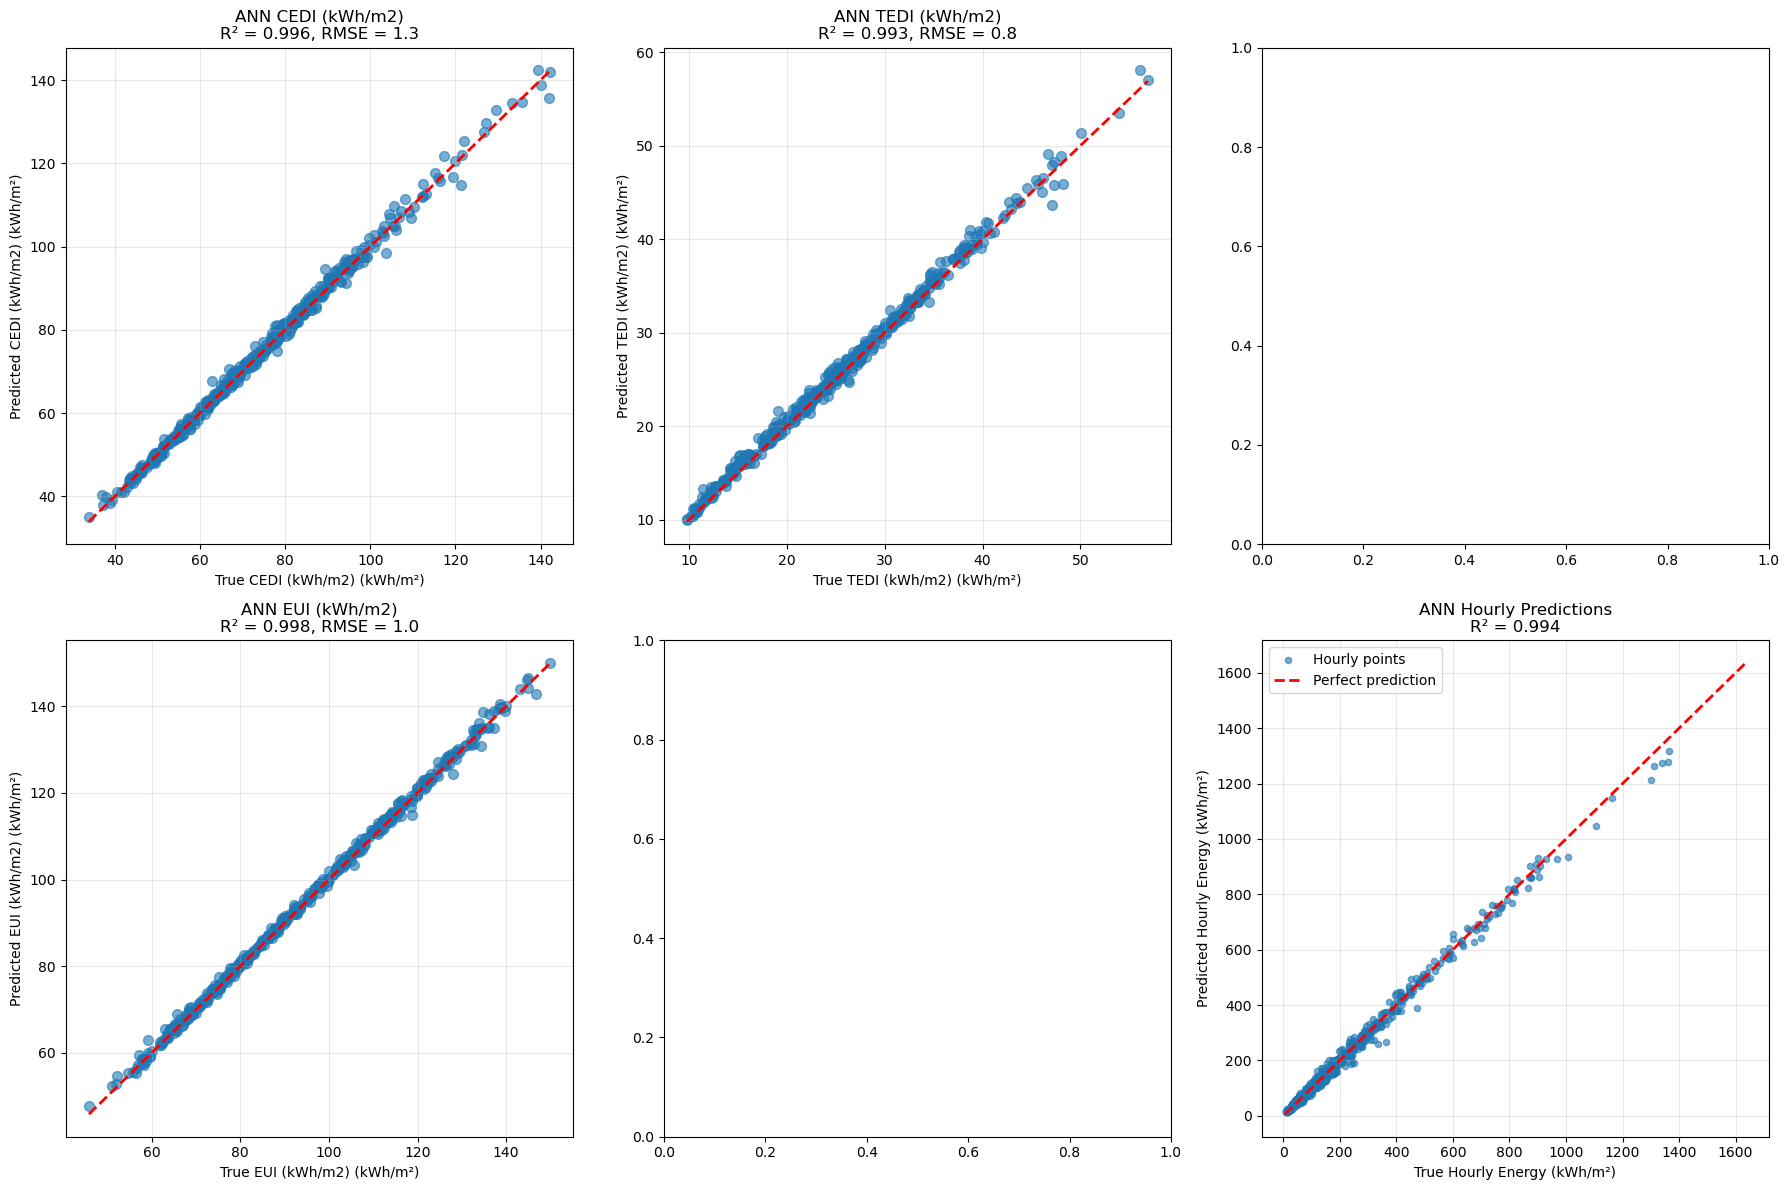

Creating individual detailed plots for ANN ensemble...


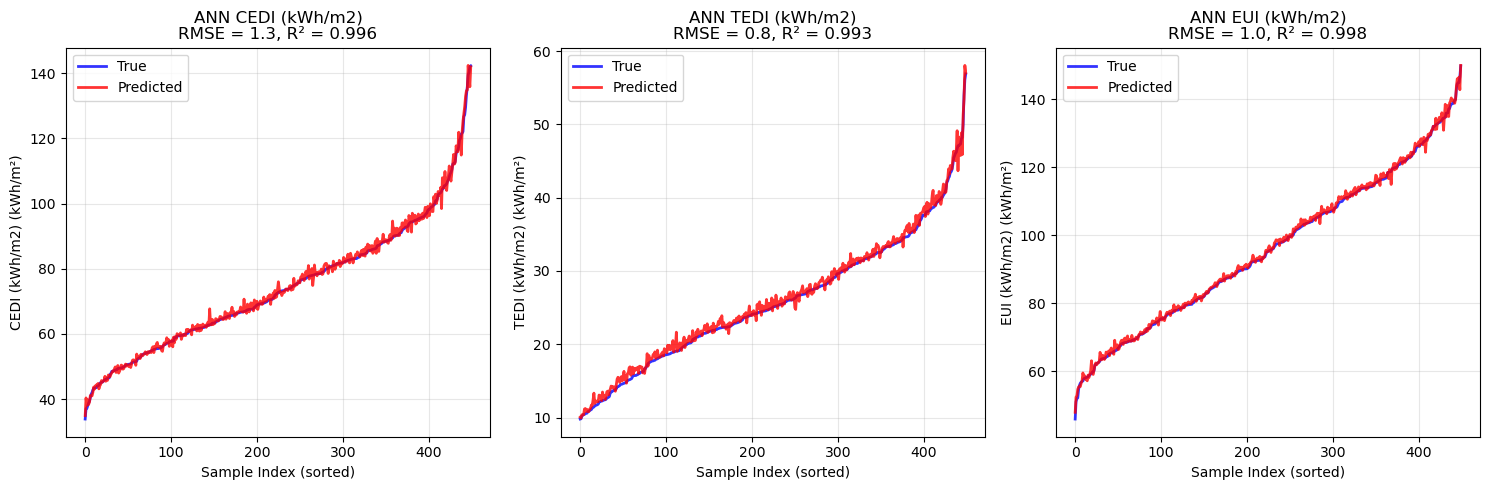

Creating detailed hourly comparison plots...


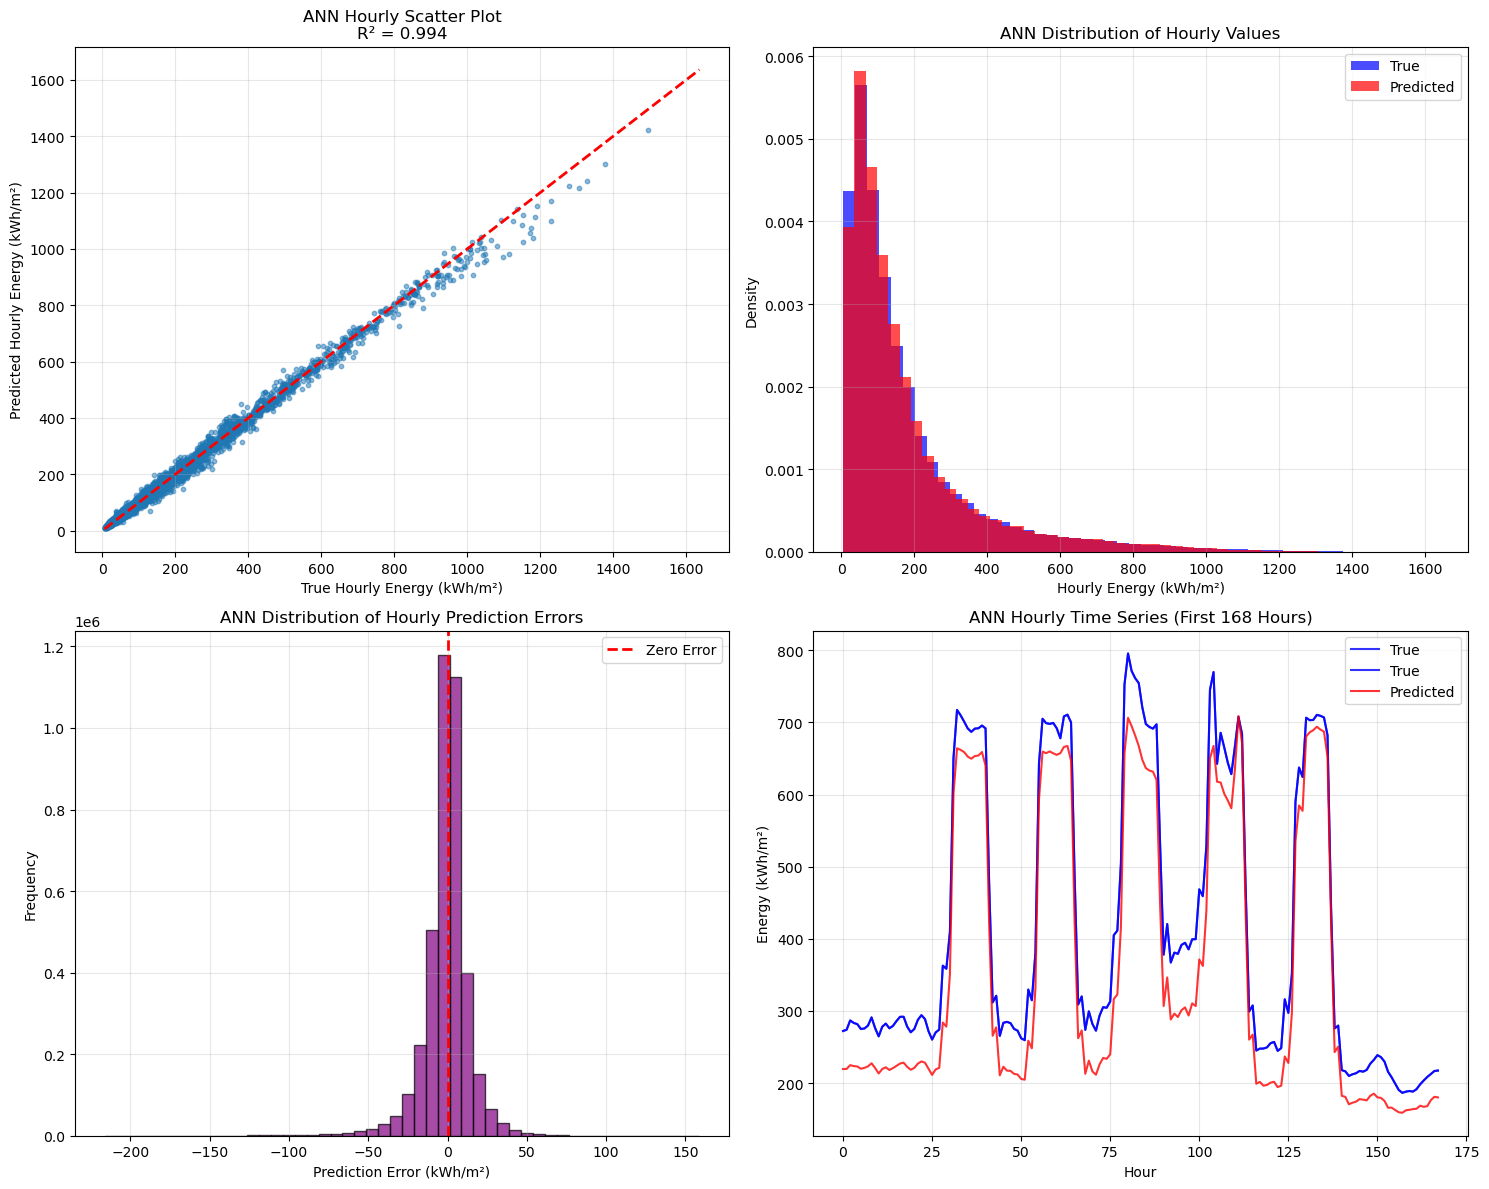

Creating additional ANN analysis plots...


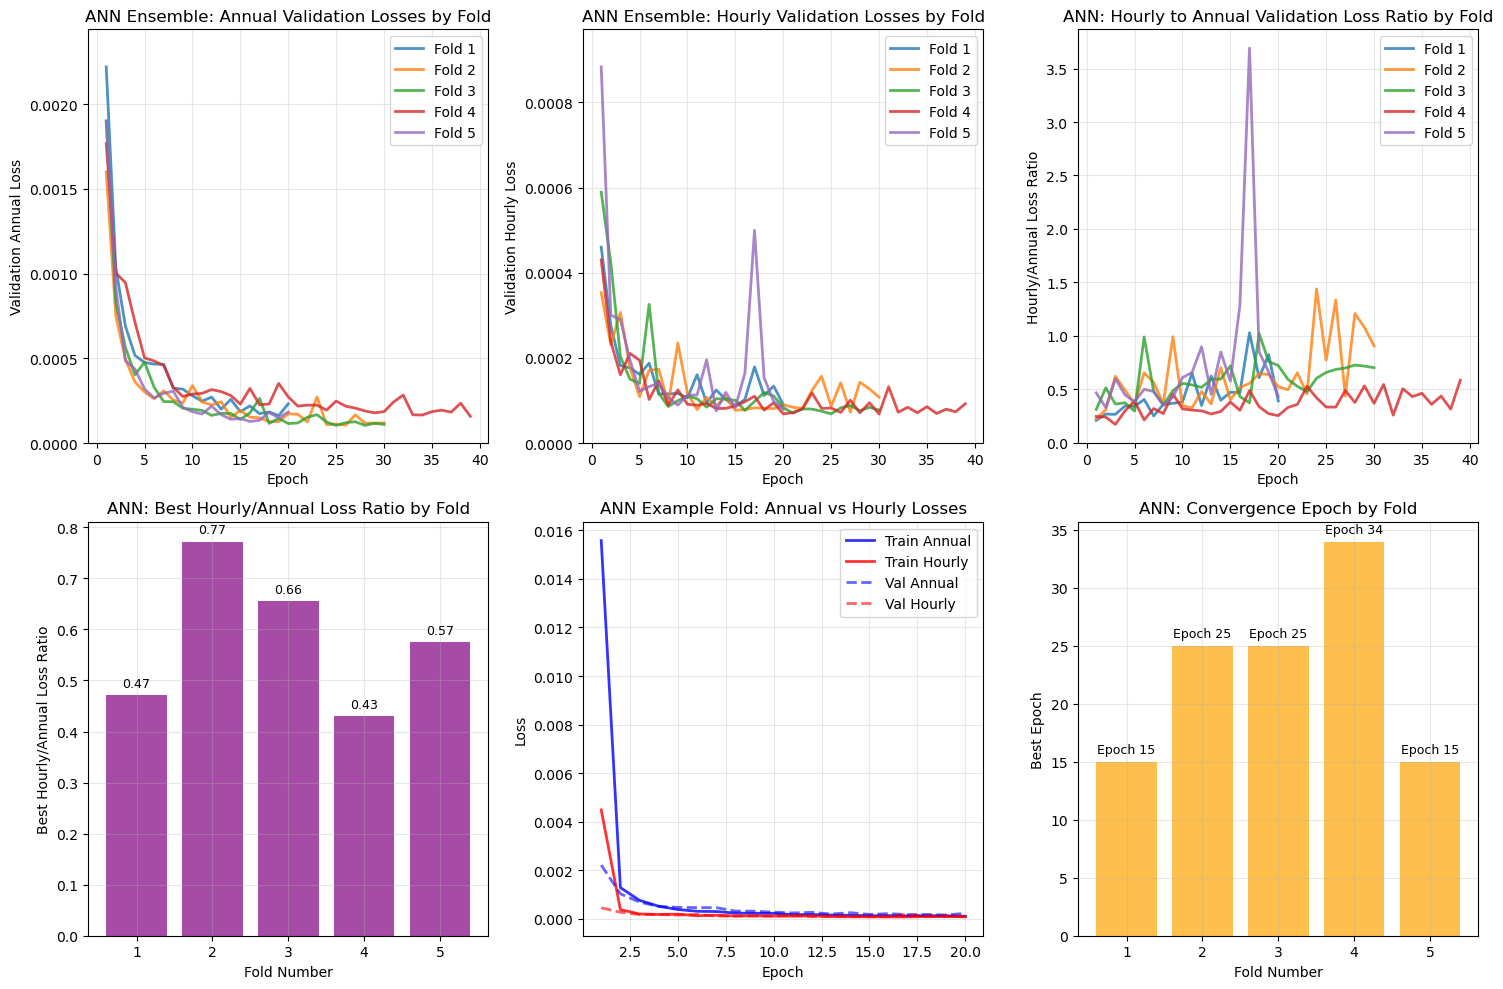


DETAILED HOURLY/ANNUAL LOSS RATIO ANALYSIS
Fold   Best Annual     Best Hourly     Ratio      Best Epoch
--------------------------------------------------------------------------------
1      0.000186        0.000088        0.47       15        
2      0.000113        0.000087        0.77       25        
3      0.000105        0.000069        0.66       25        
4      0.000166        0.000071        0.43       34        
5      0.000146        0.000084        0.57       15        
--------------------------------------------------------------------------------
Mean Ratio -               -               0.58       -         
Std Ratio -               -               0.12       -         
✓ ANN ensemble results saved to C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output
✓ ANN ensemble mean validation loss: 0.000223
✓ ANN ensemble test RMSE: 1.05 kWh/m²
✓ ANN ensemble test R²: 0.9956

ANN ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):
CEDI (kWh/m2)        

{'CEDI (kWh/m2)_rmse': 1.315450668334961,
 'CEDI (kWh/m2)_r2': 0.9957002803698304,
 'CEDI (kWh/m2)_mae': 0.9435641765594482,
 'CEDI (kWh/m2)_mbe': 0.32228145003318787,
 'TEDI (kWh/m2)_rmse': 0.7522599101066589,
 'TEDI (kWh/m2)_r2': 0.9930615515946188,
 'TEDI (kWh/m2)_mae': 0.5901809930801392,
 'TEDI (kWh/m2)_mbe': 0.43890419602394104,
 'EUI (kWh/m2)_rmse': 0.9995982050895691,
 'EUI (kWh/m2)_r2': 0.998096861531505,
 'EUI (kWh/m2)_mae': 0.7600753903388977,
 'EUI (kWh/m2)_mbe': 0.4701501727104187,
 'annual_rmse': 1.0480937957763672,
 'annual_r2': 0.9956195644889907,
 'annual_mae': 0.7646067142486572,
 'hourly_rmse': 14.43967342376709,
 'hourly_r2': 0.9944793644579272,
 'hourly_mae': 9.315735816955566,
 'hourly_corr': 0.9973433522254163,
 'hourly_max_error': 216.3245849609375}

In [85]:
### STEP 8: Other results and graphs
### =============================================================================

def load_normalization_params():
    """Load normalization parameters from saved file"""
    with open(NORM_JSON, 'r') as f:
        norm_params = json.load(f)
    return norm_params

def evaluate_ann_ensemble_model(ensemble_model, X_test, y_ann_test, y_hour_test):
    """Evaluate ANN ensemble model and return predictions"""
    # Set all individual models to eval mode
    for model in ensemble_model.models:
        model.eval()
    
    # Convert to tensors
    X_test_tensor = torch.FloatTensor(X_test).to(DEVICE)
    
    with torch.no_grad():
        ann_pred, hour_pred = ensemble_model.predict(X_test_tensor)
    
    # Debug: print shapes to understand the issue
    print(f"Debug - ann_pred shape: {ann_pred.shape}")
    print(f"Debug - hour_pred shape: {hour_pred.shape}")
    print(f"Debug - y_ann_test shape: {y_ann_test.shape}")
    print(f"Debug - y_hour_test shape: {y_hour_test.shape}")
    
    return (
        y_ann_test,  # ann_true_norm
        ann_pred.cpu().numpy(),  # ann_pred_norm
        y_hour_test,  # hour_true_norm
        hour_pred.cpu().numpy()  # hour_pred_norm
    )

def calculate_detailed_metrics_ann(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real):
    """Calculate comprehensive performance metrics for ANN"""
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    
    metrics = {}
    
    # Annual metrics for each output
    for i, col in enumerate(ANNUAL_COLS):
        true_col = ann_true_real[:, i]
        pred_col = ann_pred_real[:, i]
        
        metrics[f'{col}_rmse'] = float(np.sqrt(mean_squared_error(true_col, pred_col)))
        metrics[f'{col}_r2'] = float(r2_score(true_col, pred_col))
        metrics[f'{col}_mae'] = float(mean_absolute_error(true_col, pred_col))
        metrics[f'{col}_mbe'] = float(np.mean(pred_col - true_col))  # Mean Bias Error
    
    # Overall annual metrics
    metrics['annual_rmse'] = float(np.sqrt(mean_squared_error(ann_true_real, ann_pred_real)))
    metrics['annual_r2'] = float(r2_score(ann_true_real, ann_pred_real))
    metrics['annual_mae'] = float(mean_absolute_error(ann_true_real, ann_pred_real))
    
    # Hourly metrics - handle different shapes by flattening
    hour_true_flat = hour_true_real.reshape(-1)  # Flatten to 1D
    hour_pred_flat = hour_pred_real.reshape(-1)  # Flatten to 1D
    
    # Ensure both have same length
    min_len = min(len(hour_true_flat), len(hour_pred_flat))
    hour_true_flat = hour_true_flat[:min_len]
    hour_pred_flat = hour_pred_flat[:min_len]
    
    print(f"ANN Hourly data - True: {hour_true_flat.shape}, Pred: {hour_pred_flat.shape}")
    
    metrics['hourly_rmse'] = float(np.sqrt(mean_squared_error(hour_true_flat, hour_pred_flat)))
    metrics['hourly_r2'] = float(r2_score(hour_true_flat, hour_pred_flat))
    metrics['hourly_mae'] = float(mean_absolute_error(hour_true_flat, hour_pred_flat))
    
    # Additional hourly statistics
    metrics['hourly_corr'] = float(np.corrcoef(hour_true_flat, hour_pred_flat)[0, 1])
    metrics['hourly_max_error'] = float(np.max(np.abs(hour_true_flat - hour_pred_flat)))
    
    return metrics

def create_prediction_vs_true_comprehensive_ann(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, metrics):
    """Create comprehensive prediction vs true plots for ANN"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Annual predictions vs true
    for i, col in enumerate(ANNUAL_COLS):
        ax = axes[i // 2, i % 2]
        true_col = ann_true_real[:, i]
        pred_col = ann_pred_real[:, i]
        
        ax.scatter(true_col, pred_col, alpha=0.6, s=50)
        ax.plot([true_col.min(), true_col.max()], [true_col.min(), true_col.max()], 'r--', lw=2)
        ax.set_xlabel(f'True {col} (kWh/m²)')
        ax.set_ylabel(f'Predicted {col} (kWh/m²)')
        ax.set_title(f'ANN {col}\nR² = {metrics[f"{col}_r2"]:.3f}, RMSE = {metrics[f"{col}_rmse"]:.1f}')
        ax.grid(True, alpha=0.3)
    
    # Hourly predictions - simplified approach
    ax = axes[1, 2]
    try:
        # Flatten both arrays for simple scatter plot
        hour_true_flat = hour_true_real.reshape(-1)
        hour_pred_flat = hour_pred_real.reshape(-1)
        
        # Sample points to avoid overcrowding
        sample_size = min(1000, len(hour_true_flat))
        indices = np.random.choice(len(hour_true_flat), sample_size, replace=False)
        
        ax.scatter(hour_true_flat[indices], hour_pred_flat[indices], alpha=0.6, s=20, label='Hourly points')
        ax.plot([hour_true_flat.min(), hour_true_flat.max()], 
                [hour_true_flat.min(), hour_true_flat.max()], 'r--', lw=2, label='Perfect prediction')
        ax.set_xlabel('True Hourly Energy (kWh/m²)')
        ax.set_ylabel('Predicted Hourly Energy (kWh/m²)')
        ax.set_title(f'ANN Hourly Predictions\nR² = {metrics["hourly_r2"]:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'ANN Hourly plot error: {str(e)}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title('ANN Hourly Plot')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ann_ensemble_predictions_comprehensive.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_individual_prediction_plots_ann(ann_true_real, ann_pred_real, metrics):
    """Create individual prediction plots for each annual parameter"""
    n_params = len(ANNUAL_COLS)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 5))
    
    if n_params == 1:
        axes = [axes]
    
    for i, col in enumerate(ANNUAL_COLS):
        ax = axes[i]
        true_col = ann_true_real[:, i]
        pred_col = ann_pred_real[:, i]
        
        # Sort for better visualization
        sort_idx = np.argsort(true_col)
        true_sorted = true_col[sort_idx]
        pred_sorted = pred_col[sort_idx]
        
        ax.plot(true_sorted, 'b-', label='True', linewidth=2, alpha=0.8)
        ax.plot(pred_sorted, 'r-', label='Predicted', linewidth=2, alpha=0.8)
        ax.set_xlabel('Sample Index (sorted)')
        ax.set_ylabel(f'{col} (kWh/m²)')
        ax.set_title(f'ANN {col}\nRMSE = {metrics[f"{col}_rmse"]:.1f}, R² = {metrics[f"{col}_r2"]:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ann_ensemble_individual_predictions.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_hourly_comparison_plots_ann(hour_true_real, hour_pred_real, metrics):
    """Create simplified hourly comparison plots for ANN that avoid dimension issues"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    try:
        # Plot 1: Simple scatter plot of hourly data
        ax1 = axes[0, 0]
        hour_true_flat = hour_true_real.reshape(-1)
        hour_pred_flat = hour_pred_real.reshape(-1)
        
        # Sample points for clarity
        sample_size = min(5000, len(hour_true_flat))
        indices = np.random.choice(len(hour_true_flat), sample_size, replace=False)
        
        ax1.scatter(hour_true_flat[indices], hour_pred_flat[indices], alpha=0.5, s=10)
        ax1.plot([hour_true_flat.min(), hour_true_flat.max()], 
                [hour_true_flat.min(), hour_true_flat.max()], 'r--', lw=2)
        ax1.set_xlabel('True Hourly Energy (kWh/m²)')
        ax1.set_ylabel('Predicted Hourly Energy (kWh/m²)')
        ax1.set_title(f'ANN Hourly Scatter Plot\nR² = {metrics["hourly_r2"]:.3f}')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Distribution of hourly values
        ax2 = axes[0, 1]
        ax2.hist(hour_true_flat, bins=50, alpha=0.7, color='blue', label='True', density=True)
        ax2.hist(hour_pred_flat, bins=50, alpha=0.7, color='red', label='Predicted', density=True)
        ax2.set_xlabel('Hourly Energy (kWh/m²)')
        ax2.set_ylabel('Density')
        ax2.set_title('ANN Distribution of Hourly Values')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Error distribution
        ax3 = axes[1, 0]
        errors = hour_pred_flat - hour_true_flat
        ax3.hist(errors, bins=50, alpha=0.7, color='purple', edgecolor='black')
        ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
        ax3.set_xlabel('Prediction Error (kWh/m²)')
        ax3.set_ylabel('Frequency')
        ax3.set_title('ANN Distribution of Hourly Prediction Errors')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Time series of first 168 hours (1 week) for first sample
        ax4 = axes[1, 1]
        try:
            # Try to get first week of data
            if hour_true_real.ndim == 3:
                # 3D data: (samples, days, hours)
                sample_idx = 0
                days_to_show = 7
                hours_to_show = days_to_show * 24
                
                true_weekly = hour_true_real[sample_idx, :days_to_show, :].flatten()
                pred_weekly = hour_pred_real[sample_idx, :days_to_show, :].flatten()
                
            else:
                # 1D or 2D data - take first 168 points
                hours_to_show = 168
                true_weekly = hour_true_flat[:hours_to_show]
                pred_weekly = hour_pred_flat[:hours_to_show]
            
            hours = range(len(true_weekly))
            ax4.plot(hours, true_weekly, 'b-', label='True', alpha=0.8, linewidth=1.5)
            ax4.plot(hours, pred_weekly, 'r-', label='Predicted', alpha=0.8, linewidth=1.5)
            ax4.set_xlabel('Hour')
            ax4.set_ylabel('Energy (kWh/m²)')
            ax4.set_title('ANN Hourly Time Series (First Week)')
            ax4.legend()
            
        except Exception as e:
            # Fallback: use first 168 points from flattened arrays
            hours_to_show = min(168, len(hour_true_flat))
            hours = range(hours_to_show)
            ax4.plot(hours, hour_true_flat[:hours_to_show], 'b-', label='True', alpha=0.8, linewidth=1.5)
            ax4.plot(hours, hour_pred_flat[:hours_to_show], 'r-', label='Predicted', alpha=0.8, linewidth=1.5)
            ax4.set_xlabel('Hour')
            ax4.set_ylabel('Energy (kWh/m²)')
            ax4.set_title('ANN Hourly Time Series (First 168 Hours)')
            ax4.legend()
        
        ax4.grid(True, alpha=0.3)
        
    except Exception as e:
        # If any plotting fails, show error message
        for i, ax in enumerate(axes.flat):
            ax.clear()
            ax.text(0.5, 0.5, f'Plot {i+1} failed:\n{str(e)}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'ANN Plot {i+1} - Error')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ann_ensemble_hourly_detailed.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_additional_ann_plots(kfold_history, best_params):
    """Create additional analysis plots for ANN ensemble training"""
    
    # Plot 1: Annual validation losses for each fold
    plt.figure(figsize=(15, 10))
    
    # Subplot 1: Annual validation losses for each fold
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.8, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('ANN Ensemble: Annual Validation Losses by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set appropriate y-axis limits
    all_annual_losses = [loss for history in kfold_history['fold_losses'] for loss in history['val_annual_loss']]
    if all_annual_losses:
        plt.ylim(0, max(all_annual_losses) * 1.1)
    
    # Subplot 2: Hourly validation losses for each fold
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_hourly_loss'], 
                label=f'Fold {fold+1}', alpha=0.8, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('ANN Ensemble: Hourly Validation Losses by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set appropriate y-axis limits
    all_hourly_losses = [loss for history in kfold_history['fold_losses'] for loss in history['val_hourly_loss']]
    if all_hourly_losses:
        plt.ylim(0, max(all_hourly_losses) * 1.1)
    
    # Subplot 3: Hourly to Annual loss ratio for each fold
    plt.subplot(2, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate ratio for each epoch
        ratios = []
        for i in range(len(history['epoch'])):
            if history['val_annual_loss'][i] > 0:  # Avoid division by zero
                ratio = history['val_hourly_loss'][i] / history['val_annual_loss'][i]
                ratios.append(ratio)
            else:
                ratios.append(0)
        
        plt.plot(history['epoch'], ratios, 
                label=f'Fold {fold+1}', alpha=0.8, linewidth=2)
    
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('ANN: Hourly to Annual Validation Loss Ratio by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 4: Best Hourly/Annual ratio comparison across folds
    plt.subplot(2, 3, 4)
    best_ratios = []
    fold_numbers = []
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        best_annual = history['best_val_annual_loss']
        best_hourly = history['best_val_hourly_loss']
        
        if best_annual > 0:
            ratio = best_hourly / best_annual
            best_ratios.append(ratio)
            fold_numbers.append(fold + 1)
    
    plt.bar(fold_numbers, best_ratios, alpha=0.7, color='purple')
    plt.xlabel('Fold Number')
    plt.ylabel('Best Hourly/Annual Loss Ratio')
    plt.title('ANN: Best Hourly/Annual Loss Ratio by Fold')
    
    # Add value labels on bars
    for i, v in enumerate(best_ratios):
        plt.text(fold_numbers[i], v + 0.01, f'{v:.2f}', 
                ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3)
    
    # Subplot 5: Training losses comparison (Annual vs Hourly) for first fold
    plt.subplot(2, 3, 5)
    if kfold_history['fold_losses']:
        first_fold = kfold_history['fold_losses'][0]
        plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
                'b-', label='Train Annual', linewidth=2, alpha=0.8)
        plt.plot(first_fold['epoch'], first_fold['train_hourly_loss'], 
                'r-', label='Train Hourly', linewidth=2, alpha=0.8)
        plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
                'b--', label='Val Annual', linewidth=2, alpha=0.6)
        plt.plot(first_fold['epoch'], first_fold['val_hourly_loss'], 
                'r--', label='Val Hourly', linewidth=2, alpha=0.6)
        
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('ANN Example Fold: Annual vs Hourly Losses')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # Subplot 6: Convergence analysis - when each fold reached its best performance
    plt.subplot(2, 3, 6)
    best_epochs = [history['best_epoch'] for history in kfold_history['fold_losses']]
    folds = range(1, len(best_epochs) + 1)
    
    plt.bar(folds, best_epochs, alpha=0.7, color='orange')
    plt.xlabel('Fold Number')
    plt.ylabel('Best Epoch')
    plt.title('ANN: Convergence Epoch by Fold')
    
    # Add value labels on bars
    for i, v in enumerate(best_epochs):
        plt.text(folds[i], v + 0.5, f'Epoch {v}', 
                ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ann_additional_analysis_plots.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ratio analysis
    print("\n" + "="*80)
    print("DETAILED HOURLY/ANNUAL LOSS RATIO ANALYSIS")
    print("="*80)
    print(f"{'Fold':<6} {'Best Annual':<15} {'Best Hourly':<15} {'Ratio':<10} {'Best Epoch':<10}")
    print("-" * 80)
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        best_annual = history['best_val_annual_loss']
        best_hourly = history['best_val_hourly_loss']
        ratio = best_hourly / best_annual if best_annual > 0 else float('inf')
        
        print(f"{fold+1:<6} {best_annual:<15.6f} {best_hourly:<15.6f} {ratio:<10.2f} {history['best_epoch']:<10}")
    
    print("-" * 80)
    
    # Calculate and print statistics
    ratios = []
    for history in kfold_history['fold_losses']:
        best_annual = history['best_val_annual_loss']
        best_hourly = history['best_val_hourly_loss']
        if best_annual > 0:
            ratios.append(best_hourly / best_annual)
    
    if ratios:
        mean_ratio = np.mean(ratios)
        std_ratio = np.std(ratios)
        print(f"{'Mean Ratio':<6} {'-':<15} {'-':<15} {mean_ratio:<10.2f} {'-':<10}")
        print(f"{'Std Ratio':<6} {'-':<15} {'-':<15} {std_ratio:<10.2f} {'-':<10}")

def save_ann_ensemble_results(ensemble_model, kfold_history, best_params, X_test, y_ann_test, y_hour_test):
    """Save ANN ensemble training results with comprehensive analysis"""
    print("Saving ANN ensemble training results and metrics...")
    
    # Ensure output directory exists
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    
    # Load normalization parameters
    print("Loading normalization parameters for denormalization...")
    norm_params = load_normalization_params()
    annual_ranges = norm_params['annual_ranges']
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    
    # Define denormalization functions
    def denormalize_annual_outputs_ann(ann_norm, annual_ranges):
        """Denormalize annual outputs for ANN"""
        ann_denorm = ann_norm.copy()
        for i, col in enumerate(ANNUAL_COLS):
            vmin = annual_ranges[f"{col}_min"]
            vmax = annual_ranges[f"{col}_max"]
            ann_denorm[:, i] = ann_norm[:, i] * (vmax - vmin) + vmin
        return ann_denorm
    
    def denormalize_hourly_outputs_ann(hourly_norm, hourly_min, hourly_max):
        """Denormalize hourly outputs for ANN"""
        return hourly_norm * (hourly_max - hourly_min) + hourly_min
    
    # Evaluate ANN ensemble on test set
    print("Evaluating ANN ensemble on test set...")
    ann_true_norm, ann_pred_norm, hour_true_norm, hour_pred_norm = evaluate_ann_ensemble_model(
        ensemble_model, X_test, y_ann_test, y_hour_test
    )
    
    # DENORMALIZE to get real values
    print("Denormalizing ANN ensemble outputs to real units...")
    ann_true_real = denormalize_annual_outputs_ann(ann_true_norm, annual_ranges)
    ann_pred_real = denormalize_annual_outputs_ann(ann_pred_norm, annual_ranges)
    hour_true_real = denormalize_hourly_outputs_ann(hour_true_norm, hourly_min, hourly_max)
    hour_pred_real = denormalize_hourly_outputs_ann(hour_pred_norm, hourly_min, hourly_max)
    
    # Print shapes for debugging
    print(f"ANN Shapes after denormalization:")
    print(f"  Annual - True: {ann_true_real.shape}, Pred: {ann_pred_real.shape}")
    print(f"  Hourly - True: {hour_true_real.shape}, Pred: {hour_pred_real.shape}")
    
    # Calculate detailed metrics using REAL values
    print("Calculating performance metrics...")
    test_metrics = calculate_detailed_metrics_ann(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real)
    
    # CREATE ALL HIGH-QUALITY PLOTS
    print("Creating prediction vs true plots for ANN ensemble...")
    create_prediction_vs_true_comprehensive_ann(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, test_metrics)
    
    print("Creating individual detailed plots for ANN ensemble...")
    create_individual_prediction_plots_ann(ann_true_real, ann_pred_real, test_metrics)
    
    print("Creating detailed hourly comparison plots...")
    create_hourly_comparison_plots_ann(hour_true_real, hour_pred_real, test_metrics)
    
    print("Creating additional ANN analysis plots...")
    create_additional_ann_plots(kfold_history, best_params)
    
    # Enhanced training history with ensemble info
    enhanced_history = {
        'kfold_curves': kfold_history['fold_losses'],
        'ensemble_info': kfold_history['ensemble_info'],
        'test_metrics': test_metrics,
        'data_shapes': {
            'ann_true': ann_true_real.shape,
            'ann_pred': ann_pred_real.shape,
            'hour_true': hour_true_real.shape,
            'hour_pred': hour_pred_real.shape
        }
    }
    
    # Save enhanced training history
    with open(OUTPUT_DIR / "ann_training_history.json", "w") as f:
        json.dump(enhanced_history, f, indent=4)
    
    # Calculate the mean total loss from individual fold losses
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    mean_total_loss = np.mean(best_total_losses)
    std_total_loss = np.std(best_total_losses)
    
    # Enhanced final metrics with correct keys
    final_metrics = {
        'best_hyperparameters': best_params,
        'ensemble_configuration': kfold_history['ensemble_info'],
        'final_test_metrics': test_metrics,
        'training_summary': {
            'random_seed': RANDOM_SEED,
            'device': str(DEVICE),
            'k_folds': K_FOLDS,
            'total_models': kfold_history['ensemble_info']['n_models'],
            'mean_val_loss': float(mean_total_loss)
        },
        'model_performance': {
            'test_rmse': test_metrics['annual_rmse'],
            'test_r2': test_metrics['annual_r2'],
            'ensemble_stability': float(std_total_loss)
        }
    }
    
    with open(OUTPUT_DIR / "ann_performance_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=4)
    
    # Enhanced model info for ANN ensemble
    model_info = {
        'model_type': 'ann_ensemble',
        'n_models': kfold_history['ensemble_info']['n_models'],
        'model_files': [f"ann_ensemble_model_fold_{i+1}.pth" for i in range(K_FOLDS)],
        'norm_file': str(NORM_JSON.name),
        'training_history_file': "ann_training_history.json",
        'metrics_file': "ann_performance_metrics.json",
        'param_names': PARAM_NAMES_EXPECTED,
        'annual_cols': ANNUAL_COLS,
        'model_architecture': {
            'in_dim': X_test.shape[1],
            'latent_dim': best_params["latent_dim"],
            'hidden_dim': best_params["hidden_dim"],
            'ann_out': y_ann_test.shape[1],
            'hour_out': y_hour_test.shape[1] if len(y_hour_test.shape) > 1 else y_hour_test.shape[0]
        },
        'ensemble_info': kfold_history['ensemble_info']
    }
    
    with open(OUTPUT_DIR / "ann_model_info.json", "w") as f:
        json.dump(model_info, f, indent=4)
    
    print(f"✓ ANN ensemble results saved to {OUTPUT_DIR}")
    print(f"✓ ANN ensemble mean validation loss: {mean_total_loss:.6f}")
    print(f"✓ ANN ensemble test RMSE: {test_metrics['annual_rmse']:.2f} kWh/m²")
    print(f"✓ ANN ensemble test R²: {test_metrics['annual_r2']:.4f}")
    
    # Print detailed performance for each annual parameter
    print("\n" + "="*70)
    print("ANN ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):")
    print("="*70)
    for col in ANNUAL_COLS:
        rmse = test_metrics[f'{col}_rmse']
        r2 = test_metrics[f'{col}_r2']
        mae = test_metrics[f'{col}_mae']
        print(f"{col:25} | RMSE: {rmse:7.2f} kWh/m² | R²: {r2:6.3f} | MAE: {mae:7.2f} kWh/m²")
    
    # Print hourly performance
    print(f"\nANN Hourly Performance:")
    print(f"  RMSE: {test_metrics['hourly_rmse']:.4f} kWh/m²")
    print(f"  R²: {test_metrics['hourly_r2']:.4f}")
    print(f"  MAE: {test_metrics['hourly_mae']:.4f} kWh/m²")
    print(f"  Correlation: {test_metrics['hourly_corr']:.4f}")
    
    # Print ensemble stability
    print(f"\nANN Ensemble Stability: ±{std_total_loss:.6f}")
    
    return test_metrics

print("STEP 8: ANN ENSEMBLE RESULTS SAVING")
# Use the correct variable names from your ANN training
save_ann_ensemble_results(
    ensemble_model, kfold_history, best_params_fc,
    X_test_final, y_ann_test_final, y_hour_test_final
)

STEP 8.1: FC ENSEMBLE LOSS RATIO ANALYSIS
Analyzing loss ratios for FC ensemble model...


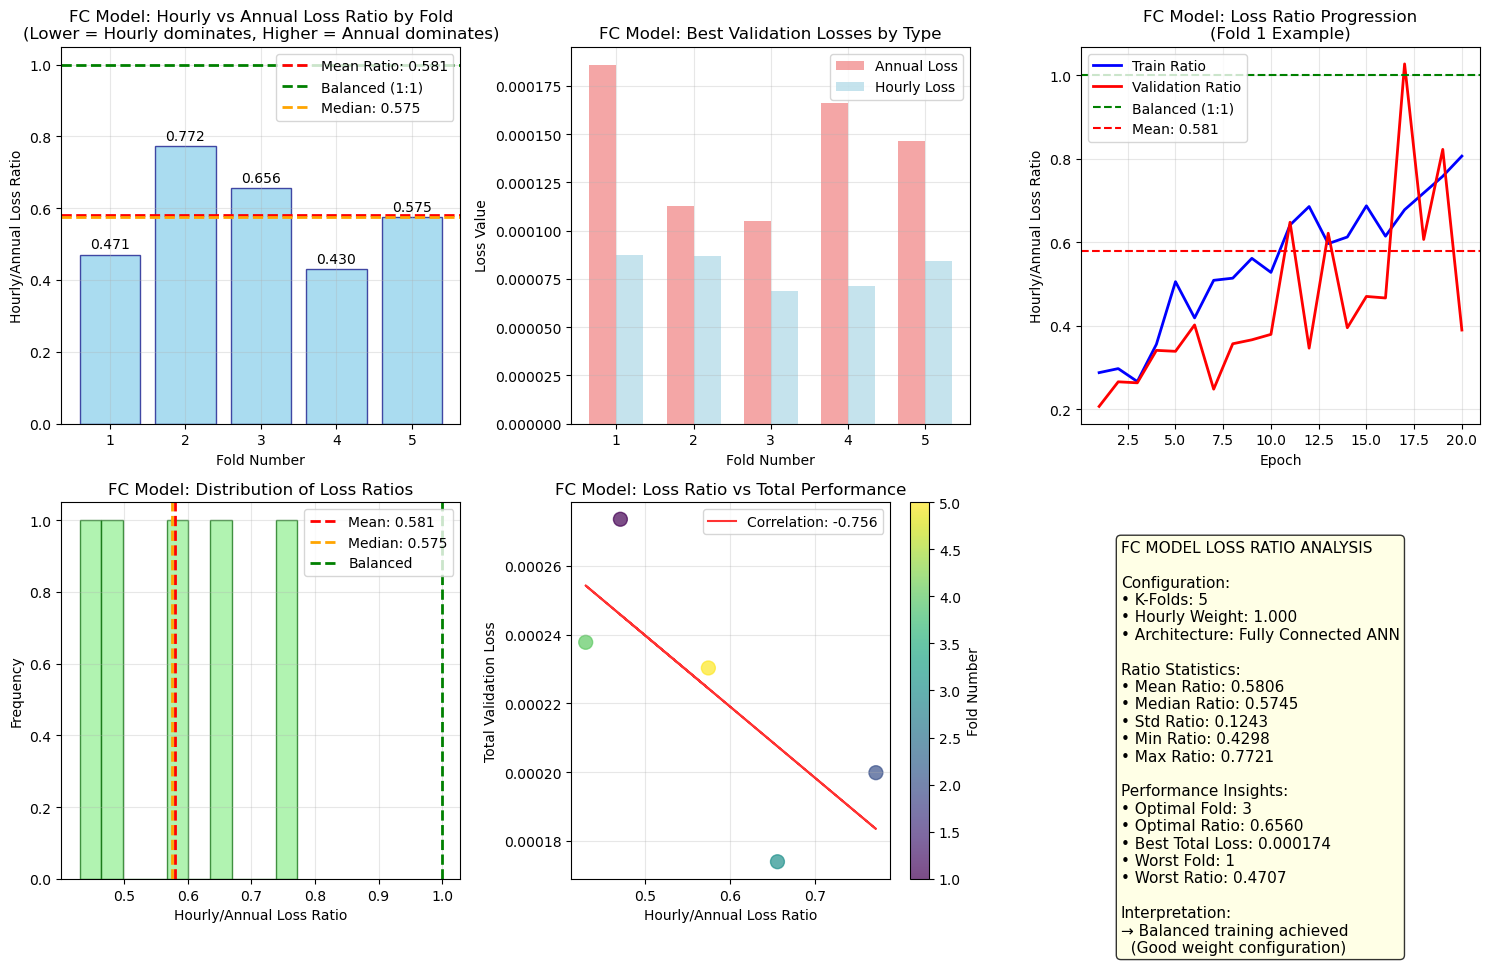


FC MODEL - DETAILED LOSS RATIO ANALYSIS
Fold   Hourly/Annual   Annual Loss     Hourly Loss     Total Loss      Status    
--------------------------------------------------------------------------------
1      0.4707          0.000186        0.000088        0.000274        IMBALANCED
2      0.7721          0.000113        0.000087        0.000200        GOOD      
3      0.6560          0.000105        0.000069        0.000174        OPTIMAL   
4      0.4298          0.000166        0.000071        0.000238        IMBALANCED
5      0.5745          0.000146        0.000084        0.000230        GOOD      
--------------------------------------------------------------------------------
Mean   0.5806          0.000143        0.000080        0.000223       
Std    0.1243          0.000031        0.000008        0.000034       

✓ FC Loss ratio analysis saved to: C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output\fc_loss_ratio_analysis.json
✓ Optimal hourly/annual r

In [59]:
### STEP 8.1: LOSS RATIO ANALYSIS FOR FC ENSEMBLE MODEL
### =============================================================================

def analyze_loss_ratios_fc(kfold_history, best_params):
    """Analyze and plot the hourly/annual loss ratios for FC ensemble model"""
    print("Analyzing loss ratios for FC ensemble model...")
    
    # Extract loss ratios for each fold
    hourly_annual_ratios = []
    fold_numbers = []
    best_annual_losses = []
    best_hourly_losses = []
    best_total_losses = []
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate ratio for best validation losses
        best_hourly_loss = history['best_val_hourly_loss']
        best_annual_loss = history['best_val_annual_loss']
        
        if best_annual_loss > 0:  # Avoid division by zero
            ratio = best_hourly_loss / best_annual_loss
            hourly_annual_ratios.append(ratio)
            fold_numbers.append(fold + 1)
            best_annual_losses.append(best_annual_loss)
            best_hourly_losses.append(best_hourly_loss)
            best_total_losses.append(history['best_val_loss'])
    
    # Calculate statistics
    mean_ratio = np.mean(hourly_annual_ratios)
    std_ratio = np.std(hourly_annual_ratios)
    median_ratio = np.median(hourly_annual_ratios)
    
    # Create comprehensive loss ratio plot
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Hourly/Annual loss ratio across folds
    plt.subplot(2, 3, 1)
    bars = plt.bar(fold_numbers, hourly_annual_ratios, color='skyblue', alpha=0.7, edgecolor='navy')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean Ratio: {mean_ratio:.3f}')
    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
    plt.axhline(y=median_ratio, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_ratio:.3f}')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, hourly_annual_ratios):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('FC Model: Hourly vs Annual Loss Ratio by Fold\n(Lower = Hourly dominates, Higher = Annual dominates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Individual losses comparison
    plt.subplot(2, 3, 2)
    width = 0.35
    x = np.arange(len(fold_numbers))
    
    plt.bar(x - width/2, best_annual_losses, width, label='Annual Loss', alpha=0.7, color='lightcoral')
    plt.bar(x + width/2, best_hourly_losses, width, label='Hourly Loss', alpha=0.7, color='lightblue')
    
    plt.xlabel('Fold Number')
    plt.ylabel('Loss Value')
    plt.title('FC Model: Best Validation Losses by Type')
    plt.xticks(x, fold_numbers)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Loss progression during training (example fold)
    plt.subplot(2, 3, 3)
    example_fold = kfold_history['fold_losses'][0]  # Use first fold as example
    
    epochs = example_fold['epoch']
    train_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['train_hourly_loss'], example_fold['train_annual_loss'])]
    val_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['val_hourly_loss'], example_fold['val_annual_loss'])]
    
    plt.plot(epochs, train_ratio, 'b-', label='Train Ratio', linewidth=2)
    plt.plot(epochs, val_ratio, 'r-', label='Validation Ratio', linewidth=2)
    plt.axhline(y=1.0, color='green', linestyle='--', label='Balanced (1:1)')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', label=f'Mean: {mean_ratio:.3f}')
    
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('FC Model: Loss Ratio Progression\n(Fold 1 Example)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Distribution of ratios
    plt.subplot(2, 3, 4)
    plt.hist(hourly_annual_ratios, bins=10, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    plt.axvline(mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ratio:.3f}')
    plt.axvline(median_ratio, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_ratio:.3f}')
    plt.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced')
    
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Frequency')
    plt.title('FC Model: Distribution of Loss Ratios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Relationship between ratio and total loss
    plt.subplot(2, 3, 5)
    scatter = plt.scatter(hourly_annual_ratios, best_total_losses, c=fold_numbers, 
                         cmap='viridis', s=100, alpha=0.7)
    
    # Add correlation line
    z = np.polyfit(hourly_annual_ratios, best_total_losses, 1)
    p = np.poly1d(z)
    plt.plot(hourly_annual_ratios, p(hourly_annual_ratios), "r-", alpha=0.8, label=f'Correlation: {np.corrcoef(hourly_annual_ratios, best_total_losses)[0,1]:.3f}')
    
    plt.colorbar(scatter, label='Fold Number')
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Total Validation Loss')
    plt.title('FC Model: Loss Ratio vs Total Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Calculate additional statistics
    optimal_ratio_fold = fold_numbers[np.argmin(best_total_losses)]
    optimal_ratio = hourly_annual_ratios[np.argmin(best_total_losses)]
    worst_ratio_fold = fold_numbers[np.argmax(best_total_losses)]
    worst_ratio = hourly_annual_ratios[np.argmax(best_total_losses)]
    
    summary_text = f"FC MODEL LOSS RATIO ANALYSIS\n\n"
    summary_text += f"Configuration:\n"
    summary_text += f"• K-Folds: {len(fold_numbers)}\n"
    summary_text += f"• Hourly Weight: {best_params['w_hour']:.3f}\n"
    summary_text += f"• Architecture: Fully Connected ANN\n\n"
    
    summary_text += f"Ratio Statistics:\n"
    summary_text += f"• Mean Ratio: {mean_ratio:.4f}\n"
    summary_text += f"• Median Ratio: {median_ratio:.4f}\n"
    summary_text += f"• Std Ratio: {std_ratio:.4f}\n"
    summary_text += f"• Min Ratio: {min(hourly_annual_ratios):.4f}\n"
    summary_text += f"• Max Ratio: {max(hourly_annual_ratios):.4f}\n\n"
    
    summary_text += f"Performance Insights:\n"
    summary_text += f"• Optimal Fold: {optimal_ratio_fold}\n"
    summary_text += f"• Optimal Ratio: {optimal_ratio:.4f}\n"
    summary_text += f"• Best Total Loss: {min(best_total_losses):.6f}\n"
    summary_text += f"• Worst Fold: {worst_ratio_fold}\n"
    summary_text += f"• Worst Ratio: {worst_ratio:.4f}\n\n"
    
    # Interpretation
    if mean_ratio < 0.5:
        interpretation = "→ Hourly loss dominates training\n  (Consider increasing w_hour)"
    elif mean_ratio > 2.0:
        interpretation = "→ Annual loss dominates training\n  (Consider decreasing w_hour)"
    else:
        interpretation = "→ Balanced training achieved\n  (Good weight configuration)"
    
    summary_text += f"Interpretation:\n{interpretation}"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fc_ensemble_loss_ratio_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ratio analysis
    print("\n" + "="*80)
    print("FC MODEL - DETAILED LOSS RATIO ANALYSIS")
    print("="*80)
    print(f"{'Fold':<6} {'Hourly/Annual':<15} {'Annual Loss':<15} {'Hourly Loss':<15} {'Total Loss':<15} {'Status':<10}")
    print("-" * 80)
    
    for i, (fold, ratio) in enumerate(zip(fold_numbers, hourly_annual_ratios)):
        status = "OPTIMAL" if fold == optimal_ratio_fold else "GOOD" if ratio >= 0.5 and ratio <= 2.0 else "IMBALANCED"
        print(f"{fold:<6} {ratio:<15.4f} {best_annual_losses[i]:<15.6f} {best_hourly_losses[i]:<15.6f} {best_total_losses[i]:<15.6f} {status:<10}")
    
    print("-" * 80)
    print(f"{'Mean':<6} {mean_ratio:<15.4f} {np.mean(best_annual_losses):<15.6f} {np.mean(best_hourly_losses):<15.6f} {np.mean(best_total_losses):<15.6f}")
    print(f"{'Std':<6} {std_ratio:<15.4f} {np.std(best_annual_losses):<15.6f} {np.std(best_hourly_losses):<15.6f} {np.std(best_total_losses):<15.6f}")
    
    # Save ratio analysis to JSON
    ratio_analysis = {
        'model_type': 'fc_ensemble',
        'hourly_annual_ratios': hourly_annual_ratios,
        'mean_ratio': float(mean_ratio),
        'median_ratio': float(median_ratio),
        'std_ratio': float(std_ratio),
        'min_ratio': float(min(hourly_annual_ratios)),
        'max_ratio': float(max(hourly_annual_ratios)),
        'optimal_ratio_fold': int(optimal_ratio_fold),
        'optimal_ratio': float(optimal_ratio),
        'worst_ratio_fold': int(worst_ratio_fold),
        'worst_ratio': float(worst_ratio),
        'hourly_weight_used': float(best_params['w_hour']),
        'interpretation': 'hourly_dominates' if mean_ratio < 0.5 else 'annual_dominates' if mean_ratio > 2.0 else 'balanced',
        'recommendation': 'increase_w_hour' if mean_ratio < 0.5 else 'decrease_w_hour' if mean_ratio > 2.0 else 'maintain_current'
    }
    
    with open(OUTPUT_DIR / "fc_loss_ratio_analysis.json", "w") as f:
        json.dump(ratio_analysis, f, indent=4)
    
    print(f"\n✓ FC Loss ratio analysis saved to: {OUTPUT_DIR / 'fc_loss_ratio_analysis.json'}")
    print(f"✓ Optimal hourly/annual ratio: {optimal_ratio:.4f} (Fold {optimal_ratio_fold})")
    print(f"✓ Current hourly weight: {best_params['w_hour']:.3f}")
    
    # Provide recommendations
    print(f"\nRECOMMENDATIONS:")
    if ratio_analysis['recommendation'] == 'increase_w_hour':
        print(f"  → Consider increasing w_hour from {best_params['w_hour']:.3f} to {best_params['w_hour'] * 1.5:.3f}")
        print(f"  → Hourly predictions are dominating the loss")
    elif ratio_analysis['recommendation'] == 'decrease_w_hour':
        print(f"  → Consider decreasing w_hour from {best_params['w_hour']:.3f} to {best_params['w_hour'] * 0.7:.3f}")
        print(f"  → Annual predictions are dominating the loss")
    else:
        print(f"  → Current w_hour = {best_params['w_hour']:.3f} is well balanced")
        print(f"  → Both hourly and annual predictions are contributing equally")
    
    return ratio_analysis

# Additional function to compare with CNN if available
def compare_with_cnn_if_exists(fc_ratio_analysis):
    """Compare FC results with CNN if CNN analysis exists"""
    cnn_ratio_file = OUTPUT_DIR / "loss_ratio_analysis.json"
    if cnn_ratio_file.exists():
        print("\n" + "="*80)
        print("COMPARISON: FC vs CNN ARCHITECTURES")
        print("="*80)
        
        with open(cnn_ratio_file, 'r') as f:
            cnn_ratio_analysis = json.load(f)
        
        print(f"{'Metric':<25} {'FC Model':<15} {'CNN Model':<15} {'Difference':<15}")
        print("-" * 80)
        
        fc_mean = fc_ratio_analysis['mean_ratio']
        cnn_mean = cnn_ratio_analysis['mean_ratio']
        diff = fc_mean - cnn_mean
        
        print(f"{'Mean Ratio':<25} {fc_mean:<15.4f} {cnn_mean:<15.4f} {diff:<15.4f}")
        
        fc_optimal = fc_ratio_analysis['optimal_ratio']
        cnn_optimal = cnn_ratio_analysis['optimal_ratio']
        diff_opt = fc_optimal - cnn_optimal
        
        print(f"{'Optimal Ratio':<25} {fc_optimal:<15.4f} {cnn_optimal:<15.4f} {diff_opt:<15.4f}")
        
        # Interpretation
        if abs(diff) < 0.1:
            comparison = "Similar balance between architectures"
        elif diff > 0:
            comparison = "FC favors annual predictions more than CNN"
        else:
            comparison = "FC favors hourly predictions more than CNN"
        
        print(f"\nComparison Insight: {comparison}")

print("STEP 8.1: FC ENSEMBLE LOSS RATIO ANALYSIS")
if 'kfold_history' in locals() and 'best_params_fc' in locals():
    fc_ratio_analysis = analyze_loss_ratios_fc(kfold_history, best_params_fc)
    
    # Try to compare with CNN if available
    compare_with_cnn_if_exists(fc_ratio_analysis)
    
    print("\n" + "="*80)
    print("FC MODEL ANALYSIS COMPLETED!")
    print("="*80)
    print("Summary:")
    print(f"• Model Type: Fully Connected ANN")
    print(f"• Ensemble Size: {kfold_history['ensemble_info']['n_models']} models")
    print(f"• Mean Validation Loss: {kfold_history['ensemble_info']['mean_total_loss']:.6f}")
    print(f"• Loss Balance: {fc_ratio_analysis['interpretation'].replace('_', ' ').title()}")
    print(f"• Recommendation: {fc_ratio_analysis['recommendation'].replace('_', ' ').title()}")
else:
    print("❌ Error: kfold_history or best_params_fc not found. Please run Step 7 first.")

print("\n✓ All FC model analysis steps completed!")
print("✓ You now have a complete comparison between simple ANN and CNN architectures")

STEP 8.1: LOSS RATIO ANALYSIS WITH ADJUSTED HOURLY LOSSES
Analyzing loss ratios with adjusted hourly losses...


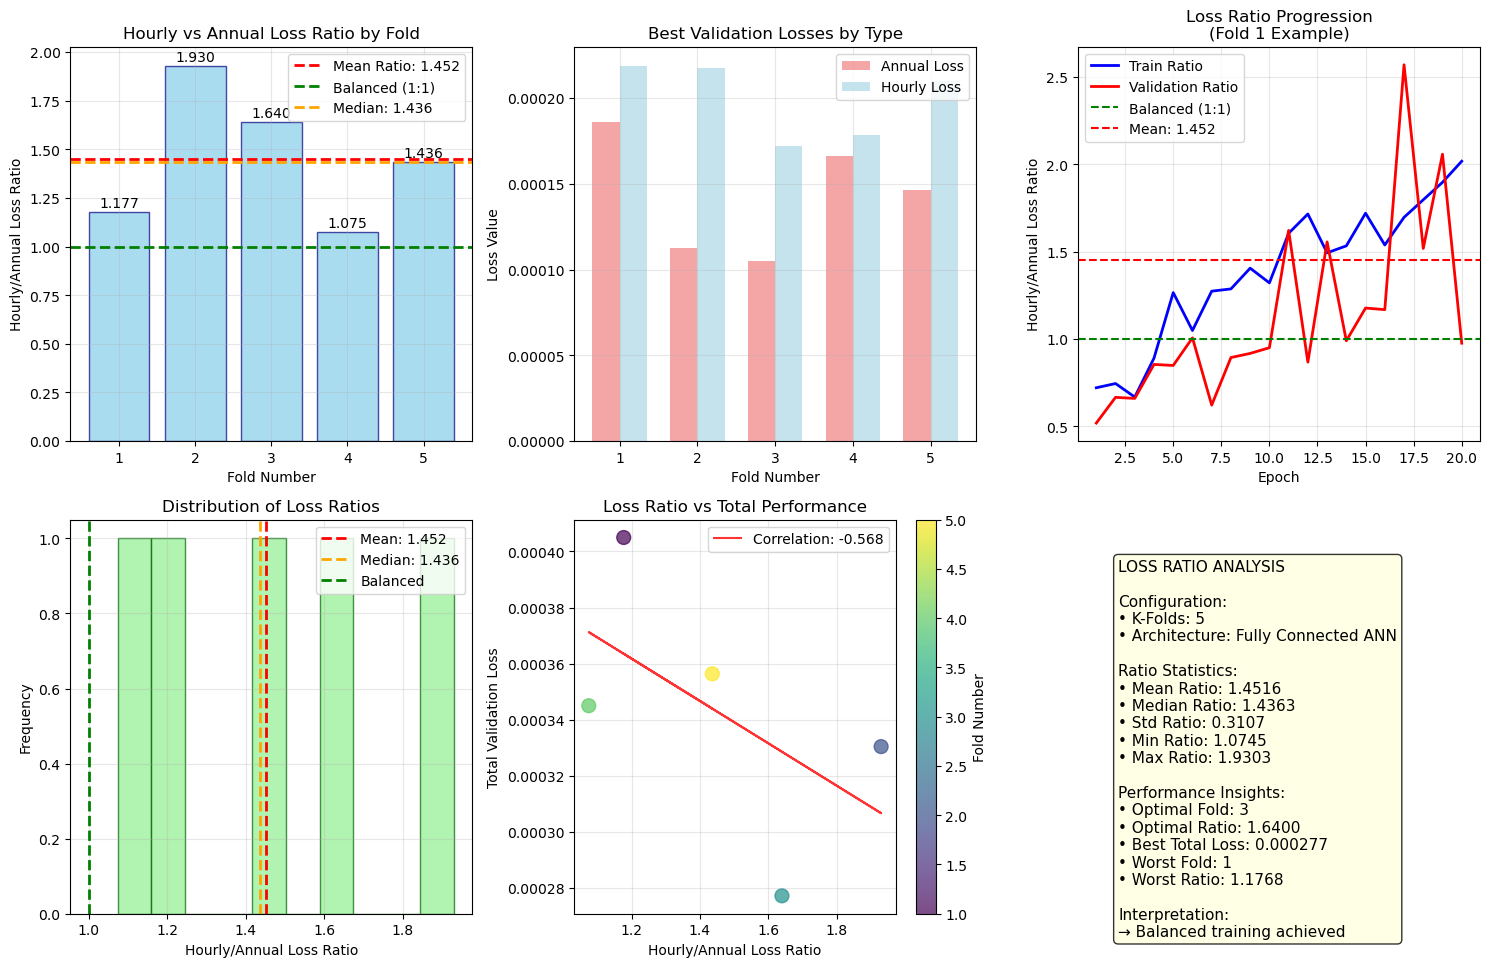


LOSS RATIO ANALYSIS
Fold   Hourly/Annual   Annual Loss     Hourly Loss     Total Loss      Status    
------------------------------------------------------------------------------------------
1      1.1768          0.000186        0.000219        0.000405        GOOD      
2      1.9303          0.000113        0.000218        0.000330        GOOD      
3      1.6400          0.000105        0.000172        0.000277        OPTIMAL   
4      1.0745          0.000166        0.000179        0.000345        GOOD      
5      1.4363          0.000146        0.000210        0.000356        GOOD      
------------------------------------------------------------------------------------------
Mean   1.4516          0.000143        0.000200        0.000343       
Std    0.3107          0.000031        0.000020        0.000041       

✓ Loss ratio analysis saved to: C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output\loss_ratio_analysis_adjusted.json
✓ Optimal hourly/annua

In [75]:
### STEP 8.1: LOSS RATIO ANALYSIS WITH ADJUSTED HOURLY LOSSES
### =============================================================================

def analyze_loss_ratios_adjusted(kfold_history, best_params):
    """Analyze and plot the hourly/annual loss ratios with adjusted hourly losses"""
    print("Analyzing loss ratios with adjusted hourly losses...")
    
    # Extract loss ratios for each fold using adjusted hourly losses
    hourly_annual_ratios = []
    fold_numbers = []
    best_annual_losses = []
    best_hourly_adjusted_losses = []
    best_total_adjusted_losses = []
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate ratio using adjusted hourly losses
        best_hourly_adjusted = history['best_hourly_loss2']
        best_annual_loss = history['best_val_annual_loss']
        
        if best_annual_loss > 0:  # Avoid division by zero
            ratio = best_hourly_adjusted / best_annual_loss
            hourly_annual_ratios.append(ratio)
            fold_numbers.append(fold + 1)
            best_annual_losses.append(best_annual_loss)
            best_hourly_adjusted_losses.append(best_hourly_adjusted)
            best_total_adjusted = best_annual_loss + best_hourly_adjusted
            best_total_adjusted_losses.append(best_total_adjusted)
    
    # Calculate statistics
    mean_ratio = np.mean(hourly_annual_ratios)
    std_ratio = np.std(hourly_annual_ratios)
    median_ratio = np.median(hourly_annual_ratios)
    
    # Create comprehensive loss ratio plot
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Hourly/Annual loss ratio across folds
    plt.subplot(2, 3, 1)
    bars = plt.bar(fold_numbers, hourly_annual_ratios, color='skyblue', alpha=0.7, edgecolor='navy')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean Ratio: {mean_ratio:.3f}')
    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
    plt.axhline(y=median_ratio, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_ratio:.3f}')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, hourly_annual_ratios):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('Hourly vs Annual Loss Ratio by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Individual losses comparison
    plt.subplot(2, 3, 2)
    width = 0.35
    x = np.arange(len(fold_numbers))
    
    plt.bar(x - width/2, best_annual_losses, width, label='Annual Loss', alpha=0.7, color='lightcoral')
    plt.bar(x + width/2, best_hourly_adjusted_losses, width, label='Hourly Loss', alpha=0.7, color='lightblue')
    
    plt.xlabel('Fold Number')
    plt.ylabel('Loss Value')
    plt.title('Best Validation Losses by Type')
    plt.xticks(x, fold_numbers)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Loss progression during training (example fold)
    plt.subplot(2, 3, 3)
    example_fold = kfold_history['fold_losses'][0]  # Use first fold as example
    
    epochs = example_fold['epoch']
    # Calculate ratios using adjusted hourly losses
    train_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['train_hourly_loss2'], example_fold['train_annual_loss'])]
    val_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['hourly_loss2'], example_fold['val_annual_loss'])]
    
    plt.plot(epochs, train_ratio, 'b-', label='Train Ratio', linewidth=2)
    plt.plot(epochs, val_ratio, 'r-', label='Validation Ratio', linewidth=2)
    plt.axhline(y=1.0, color='green', linestyle='--', label='Balanced (1:1)')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', label=f'Mean: {mean_ratio:.3f}')
    
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('Loss Ratio Progression\n(Fold 1 Example)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Distribution of ratios
    plt.subplot(2, 3, 4)
    plt.hist(hourly_annual_ratios, bins=10, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    plt.axvline(mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ratio:.3f}')
    plt.axvline(median_ratio, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_ratio:.3f}')
    plt.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced')
    
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution of Loss Ratios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Relationship between ratio and total loss
    plt.subplot(2, 3, 5)
    scatter = plt.scatter(hourly_annual_ratios, best_total_adjusted_losses, c=fold_numbers, 
                         cmap='viridis', s=100, alpha=0.7)
    
    # Add correlation line
    z = np.polyfit(hourly_annual_ratios, best_total_adjusted_losses, 1)
    p = np.poly1d(z)
    plt.plot(hourly_annual_ratios, p(hourly_annual_ratios), "r-", alpha=0.8, 
             label=f'Correlation: {np.corrcoef(hourly_annual_ratios, best_total_adjusted_losses)[0,1]:.3f}')
    
    plt.colorbar(scatter, label='Fold Number')
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Total Validation Loss')
    plt.title('Loss Ratio vs Total Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Calculate additional statistics
    optimal_ratio_fold = fold_numbers[np.argmin(best_total_adjusted_losses)]
    optimal_ratio = hourly_annual_ratios[np.argmin(best_total_adjusted_losses)]
    worst_ratio_fold = fold_numbers[np.argmax(best_total_adjusted_losses)]
    worst_ratio = hourly_annual_ratios[np.argmax(best_total_adjusted_losses)]
    
    summary_text = f"LOSS RATIO ANALYSIS\n\n"
    summary_text += f"Configuration:\n"
    summary_text += f"• K-Folds: {len(fold_numbers)}\n"
    summary_text += f"• Architecture: Fully Connected ANN\n\n"
    
    summary_text += f"Ratio Statistics:\n"
    summary_text += f"• Mean Ratio: {mean_ratio:.4f}\n"
    summary_text += f"• Median Ratio: {median_ratio:.4f}\n"
    summary_text += f"• Std Ratio: {std_ratio:.4f}\n"
    summary_text += f"• Min Ratio: {min(hourly_annual_ratios):.4f}\n"
    summary_text += f"• Max Ratio: {max(hourly_annual_ratios):.4f}\n\n"
    
    summary_text += f"Performance Insights:\n"
    summary_text += f"• Optimal Fold: {optimal_ratio_fold}\n"
    summary_text += f"• Optimal Ratio: {optimal_ratio:.4f}\n"
    summary_text += f"• Best Total Loss: {min(best_total_adjusted_losses):.6f}\n"
    summary_text += f"• Worst Fold: {worst_ratio_fold}\n"
    summary_text += f"• Worst Ratio: {worst_ratio:.4f}\n\n"
    
    # Interpretation
    if mean_ratio < 0.5:
        interpretation = "→ Hourly loss dominates training"
    elif mean_ratio > 2.0:
        interpretation = "→ Annual loss dominates training"
    else:
        interpretation = "→ Balanced training achieved"
    
    summary_text += f"Interpretation:\n{interpretation}"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loss_ratio_analysis_adjusted.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ratio analysis
    print("\n" + "="*90)
    print("LOSS RATIO ANALYSIS")
    print("="*90)
    print(f"{'Fold':<6} {'Hourly/Annual':<15} {'Annual Loss':<15} {'Hourly Loss':<15} {'Total Loss':<15} {'Status':<10}")
    print("-" * 90)
    
    for i, (fold, ratio) in enumerate(zip(fold_numbers, hourly_annual_ratios)):
        status = "OPTIMAL" if fold == optimal_ratio_fold else "GOOD" if ratio >= 0.5 and ratio <= 2.0 else "IMBALANCED"
        print(f"{fold:<6} {ratio:<15.4f} {best_annual_losses[i]:<15.6f} {best_hourly_adjusted_losses[i]:<15.6f} {best_total_adjusted_losses[i]:<15.6f} {status:<10}")
    
    print("-" * 90)
    print(f"{'Mean':<6} {mean_ratio:<15.4f} {np.mean(best_annual_losses):<15.6f} {np.mean(best_hourly_adjusted_losses):<15.6f} {np.mean(best_total_adjusted_losses):<15.6f}")
    print(f"{'Std':<6} {std_ratio:<15.4f} {np.std(best_annual_losses):<15.6f} {np.std(best_hourly_adjusted_losses):<15.6f} {np.std(best_total_adjusted_losses):<15.6f}")
    
    # Save ratio analysis to JSON
    ratio_analysis = {
        'model_type': 'fc_ensemble',
        'hourly_annual_ratios': hourly_annual_ratios,
        'mean_ratio': float(mean_ratio),
        'median_ratio': float(median_ratio),
        'std_ratio': float(std_ratio),
        'min_ratio': float(min(hourly_annual_ratios)),
        'max_ratio': float(max(hourly_annual_ratios)),
        'optimal_ratio_fold': int(optimal_ratio_fold),
        'optimal_ratio': float(optimal_ratio),
        'worst_ratio_fold': int(worst_ratio_fold),
        'worst_ratio': float(worst_ratio),
        'interpretation': 'hourly_dominates' if mean_ratio < 0.5 else 'annual_dominates' if mean_ratio > 2.0 else 'balanced'
    }
    
    with open(OUTPUT_DIR / "loss_ratio_analysis_adjusted.json", "w") as f:
        json.dump(ratio_analysis, f, indent=4)
    
    print(f"\n✓ Loss ratio analysis saved to: {OUTPUT_DIR / 'loss_ratio_analysis_adjusted.json'}")
    print(f"✓ Optimal hourly/annual ratio: {optimal_ratio:.4f} (Fold {optimal_ratio_fold})")
    
    # Provide recommendations
    print(f"\nRECOMMENDATIONS:")
    if ratio_analysis['interpretation'] == 'hourly_dominates':
        print(f"  → Hourly predictions are dominating the loss")
        print(f"  → Consider focusing more on annual prediction improvement")
    elif ratio_analysis['interpretation'] == 'annual_dominates':
        print(f"  → Annual predictions are dominating the loss")
        print(f"  → Consider focusing more on hourly prediction improvement")
    else:
        print(f"  → Good balance between hourly and annual predictions")
        print(f"  → Both prediction types are contributing equally")
    
    return ratio_analysis

# Additional function to compare with CNN if available
def compare_with_cnn_if_exists_adjusted(fc_ratio_analysis):
    """Compare FC results with CNN if CNN analysis exists"""
    cnn_ratio_file = OUTPUT_DIR / "loss_ratio_analysis.json"
    if cnn_ratio_file.exists():
        print("\n" + "="*80)
        print("COMPARISON: FC vs CNN ARCHITECTURES")
        print("="*80)
        
        with open(cnn_ratio_file, 'r') as f:
            cnn_ratio_analysis = json.load(f)
        
        print(f"{'Metric':<25} {'FC Model':<15} {'CNN Model':<15} {'Difference':<15}")
        print("-" * 80)
        
        fc_mean = fc_ratio_analysis['mean_ratio']
        cnn_mean = cnn_ratio_analysis['mean_ratio']
        diff = fc_mean - cnn_mean
        
        print(f"{'Mean Ratio':<25} {fc_mean:<15.4f} {cnn_mean:<15.4f} {diff:<15.4f}")
        
        fc_optimal = fc_ratio_analysis['optimal_ratio']
        cnn_optimal = cnn_ratio_analysis['optimal_ratio']
        diff_opt = fc_optimal - cnn_optimal
        
        print(f"{'Optimal Ratio':<25} {fc_optimal:<15.4f} {cnn_optimal:<15.4f} {diff_opt:<15.4f}")
        
        # Interpretation
        if abs(diff) < 0.1:
            comparison = "Similar balance between architectures"
        elif diff > 0:
            comparison = "FC favors annual predictions more than CNN"
        else:
            comparison = "FC favors hourly predictions more than CNN"
        
        print(f"\nComparison Insight: {comparison}")

print("STEP 8.1: LOSS RATIO ANALYSIS WITH ADJUSTED HOURLY LOSSES")

# Ensure we have the adjusted hourly losses in kfold_history
if 'kfold_history' in locals():
    # Check if we need to calculate adjusted hourly losses
    if 'hourly_loss2' not in kfold_history['fold_losses'][0]:
        print("Calculating adjusted hourly losses...")
        for fold_history in kfold_history['fold_losses']:
            # For validation losses
            fold_history['hourly_loss2'] = [2.5 * loss for loss in fold_history['val_hourly_loss']]
            fold_history['best_hourly_loss2'] = 2.5 * fold_history['best_val_hourly_loss']
            
            # For training losses
            fold_history['train_hourly_loss2'] = [2.5 * loss for loss in fold_history['train_hourly_loss']]
        print("✓ Adjusted hourly losses calculated")
    
    if 'best_params_fc' in locals():
        fc_ratio_analysis = analyze_loss_ratios_adjusted(kfold_history, best_params_fc)
        
        # Try to compare with CNN if available
        compare_with_cnn_if_exists_adjusted(fc_ratio_analysis)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETED!")
        print("="*80)
        print("Summary:")
        print(f"• Model Type: Fully Connected ANN")
        print(f"• Ensemble Size: {kfold_history['ensemble_info']['n_models']} models")
        print(f"• Mean Total Loss: {np.mean([h['best_val_annual_loss'] + h['best_hourly_loss2'] for h in kfold_history['fold_losses']]):.6f}")
        print(f"• Loss Balance: {fc_ratio_analysis['interpretation'].replace('_', ' ').title()}")
    else:
        print("❌ Error: best_params_fc not found")
else:
    print("❌ Error: kfold_history not found. Please run Step 7 first.")

print("\n✓ All analysis steps completed!")

In [77]:
### STEP 9: ENSEMBLE PREDICTION INTERFACE FOR FC ANN (STANDALONE)
### =============================================================================

def create_ensemble_prediction_interface_fc():
    """Create a standalone prediction script for FC ensemble model"""
    
    prediction_code = '''# predict_fc_ensemble_model.py
"""
Standalone prediction interface for the trained FC ensemble model
Usage: python predict_fc_ensemble_model.py
"""

import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# FC Model architecture (must match training)
class UnifiedNetFC(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, hidden_dim=256, ann_out=3, hour_out=8760):
        super().__init__()
        
        # Shared encoder
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128), 
            torch.nn.ReLU(),
            torch.nn.Linear(128, latent_dim), 
            torch.nn.ReLU()
        )
        
        # Annual output head
        self.ann_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 128), 
            torch.nn.ReLU(),
            torch.nn.Linear(128, ann_out)
        )
        
        # Hourly output head (fully connected)
        self.hourly_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hour_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        
        # Annual outputs
        ann = self.ann_head(z)
        
        # Hourly outputs via fully connected layers
        hour_flat = self.hourly_head(z)
        
        # Reshape to match expected format: (batch_size, 1, 365, 24)
        hour = hour_flat.view(-1, 1, 365, 24)
        
        return ann, hour

# Ensemble model class
class EnsembleModel(torch.nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.n_models = len(models)
        print(f"Loaded ensemble with {self.n_models} models")
    
    def forward(self, x):
        """Make ensemble prediction by averaging all model outputs"""
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        # Average predictions across all models
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour
    
    def predict(self, x):
        """Alias for forward method for consistency"""
        return self.forward(x)
    
    def predict_with_uncertainty(self, x):
        """Make ensemble prediction with uncertainty estimates"""
        device = next(self.models[0].parameters()).device
        x = x.to(device)
        
        all_ann_preds = []
        all_hour_preds = []
        
        with torch.no_grad():
            for model in self.models:
                model.eval()
                pred_ann, pred_hour = model(x)
                all_ann_preds.append(pred_ann.cpu().numpy())
                all_hour_preds.append(pred_hour.cpu().numpy())
        
        # Convert to numpy for uncertainty calculation
        all_ann_preds = np.array(all_ann_preds)  # shape: (n_models, batch_size, n_annual_outputs)
        all_hour_preds = np.array(all_hour_preds)  # shape: (n_models, batch_size, 1, 365, 24)
        
        # Calculate mean predictions
        mean_ann = np.mean(all_ann_preds, axis=0)
        mean_hour = np.mean(all_hour_preds, axis=0)
        
        # Calculate standard deviation (uncertainty)
        std_ann = np.std(all_ann_preds, axis=0)
        std_hour = np.std(all_hour_preds, axis=0)
        
        return (torch.tensor(mean_ann), torch.tensor(mean_hour), 
                torch.tensor(std_ann), torch.tensor(std_hour))

def load_ensemble_model():
    """Load FC ensemble model and normalization parameters"""
    model_dir = Path(".")  # Current directory
    
    # Load normalization parameters
    with open(model_dir / "fc_norm_params.json") as f:
        norm = json.load(f)
    
    # Load model configuration
    with open(model_dir / "fc_model_info.json") as f:
        info = json.load(f)
    
    # Load ensemble info
    with open(model_dir / "fc_ensemble_info.json") as f:
        ensemble_info = json.load(f)
    
    # Recreate model architecture
    arch = info['model_architecture']
    all_models = []
    
    # Load all fold models
    for fold in range(1, ensemble_info['n_models'] + 1):
        model_path = model_dir / f"fc_ensemble_model_fold_{fold}.pth"
        if model_path.exists():
            model = UnifiedNetFC(
                in_dim=arch['in_dim'],
                latent_dim=arch['latent_dim'], 
                hidden_dim=arch['hidden_dim'],
                ann_out=arch['ann_out'],
                hour_out=8760
            )
            
            checkpoint = torch.load(model_path, map_location='cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            all_models.append(model)
            print(f"✓ Loaded FC model from fold {fold}")
        else:
            print(f"⚠ Warning: Model file not found: {model_path}")
    
    if not all_models:
        raise ValueError("No FC ensemble models found!")
    
    ensemble = EnsembleModel(all_models)
    return ensemble, norm

def predict_single_input(ensemble, norm, input_values):
    """Make prediction for single input set and return REAL values"""
    normalized_input = []
    for i, param in enumerate(norm['param_names']):
        vmin, vmax = norm['input_ranges'][param]
        normalized_val = (input_values[i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    # Convert to tensor and predict
    x = torch.tensor([normalized_input], dtype=torch.float32)
    with torch.no_grad():
        pred_ann_norm, pred_hour_norm = ensemble.predict(x)
    
    # Convert to numpy (still normalized)
    pred_ann_norm = pred_ann_norm.numpy()[0]
    pred_hour_norm = pred_hour_norm.numpy()[0, 0, :, :]
    
    # DENORMALIZE to get REAL values
    ann_real = []
    for i, col in enumerate(norm['annual_cols']):
        vmin = norm['annual_ranges'][f'{col}_min']
        vmax = norm['annual_ranges'][f'{col}_max']
        real_val = pred_ann_norm[i] * (vmax - vmin) + vmin
        ann_real.append(real_val)
    
    # Denormalize hourly output to kWh
    hourly_real = pred_hour_norm * (norm['hourly_max'] - norm['hourly_min']) + norm['hourly_min']
    
    return ann_real, hourly_real

def main():
    try:
        ensemble, norm = load_ensemble_model()
        print("✓ FC Ensemble model loaded successfully!")
        print(f"✓ Using {ensemble.n_models} models for ensemble prediction")
        print(f"✓ Model Architecture: Fully Connected ANN")
    except Exception as e:
        print(f"Error loading FC ensemble model: {e}")
        print("Make sure you're running this script from the same folder as:")
        print("  - fc_norm_params.json")
        print("  - fc_model_info.json") 
        print("  - fc_ensemble_info.json")
        print("  - fc_ensemble_model_fold_*.pth files")
        return
    
    print("=" * 70)
    print("FC ENSEMBLE BUILDING ENERGY PREDICTION MODEL")
    print("=" * 70)
    print("Please enter the following building parameters:")
    print()
    
    input_values = []
    for param in norm['param_names']:
        # Show parameter ranges for reference
        vmin, vmax = norm['input_ranges'][param]
        value = float(input(f"{param} (range: {vmin} to {vmax}): "))
        input_values.append(value)
    
    print("\\nProcessing ensemble prediction...")
    annual_pred, hourly_pred = predict_single_input(ensemble, norm, input_values)
    
    print("\\n" + "=" * 70)
    print("FC ENSEMBLE PREDICTION RESULTS")
    print("=" * 70)
    print("ANNUAL ENERGY CONSUMPTION (kWh/m²):")
    print("-" * 45)
    for i, col in enumerate(norm['annual_cols']):
        print(f"  {col:20}: {annual_pred[i]:.2f} kWh/m²")
    
    # Save hourly results
    hourly_df = pd.DataFrame(hourly_pred)
    hourly_file = "fc_ensemble_predicted_hourly_consumption.csv"
    hourly_df.to_csv(hourly_file, index=False, header=False)
    
    print(f"\\nHOURLY ENERGY CONSUMPTION:")
    print(f"  Saved to: {hourly_file}")
    print(f"  Shape: {hourly_pred.shape} ({hourly_pred.shape[0]} days × {hourly_pred.shape[1]} hours)")
    print(f"  Total annual hourly sum: {np.sum(hourly_pred):.0f} kWh")
    
    # Calculate and display key statistics
    print(f"\\nHOURLY PROFILE STATISTICS:")
    print(f"  Average daily consumption: {np.mean(np.sum(hourly_pred, axis=1)):.1f} kWh/day")
    print(f"  Peak hourly consumption: {np.max(hourly_pred):.2f} kWh")
    print(f"  Minimum hourly consumption: {np.min(hourly_pred):.2f} kWh")
    
    print("\\n" + "=" * 70)

if __name__ == "__main__":
    main()
'''

    # Write the FC ensemble prediction interface file
    with open(OUTPUT_DIR / "predict_fc_ensemble_model.py", "w", encoding="utf-8") as f:
        f.write(prediction_code)
    
    print(f"✓ FC Ensemble prediction interface created: {OUTPUT_DIR / 'predict_fc_ensemble_model.py'}")
    print("You can now use this file on any computer with PyTorch installed!")
    print("Usage: cd output && python predict_fc_ensemble_model.py")

def test_ensemble_prediction_interface_fc():
    """Test that the FC ensemble prediction interface works correctly"""
    print("Testing FC ensemble prediction interface...")
    
    # Load the normalization parameters
    norm_params = load_normalization_params()
    
    # Test with some sample input (middle of each parameter range)
    sample_input = []
    for param in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[param]
        sample_value = (vmin + vmax) / 2  # Middle of range
        sample_input.append(sample_value)
    
    print("Sample input (middle of parameter ranges):")
    for param, value in zip(PARAM_NAMES_EXPECTED, sample_input):
        print(f"  {param:15}: {value:.3f}")
    
    # Make ensemble prediction
    normalized_input = []
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        vmin, vmax = INPUT_RANGES[param]
        normalized_val = (sample_input[i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        pred_ann_norm, pred_hour_norm = final_model.predict(x)
    
    # Convert to numpy (single prediction, so 1D array)
    pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]  # Shape: (3,)
    pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]  # Shape: (365, 24)
    
    # Denormalize to real values
    pred_ann_real = []
    for i, col in enumerate(ANNUAL_COLS):
        vmin = norm_params['annual_ranges'][f"{col}_min"]
        vmax = norm_params['annual_ranges'][f"{col}_max"]
        real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
        pred_ann_real.append(real_val)
    
    # Denormalize hourly
    pred_hour_real = pred_hour_norm_np * (norm_params['hourly_max'] - norm_params['hourly_min']) + norm_params['hourly_min']
    
    print("\nFC Ensemble prediction results:")
    print("Annual outputs (kWh/m²):")
    for i, col in enumerate(ANNUAL_COLS):
        print(f"  {col:15}: {pred_ann_real[i]:.2f}")
    
    print(f"\nHourly output shape: {pred_hour_real.shape}")
    print(f"Hourly range: {pred_hour_real.min():.3f} to {pred_hour_real.max():.3f} kWh")
    print(f"Total annual hourly energy: {np.sum(pred_hour_real):.0f} kWh")
    
    # Test uncertainty prediction
    print("\nTesting uncertainty estimation...")
    try:
        mean_ann, mean_hour, std_ann, std_hour = final_model.predict_with_uncertainty(x)
        print(f"Annual prediction uncertainty (std): {std_ann.cpu().numpy()[0]}")
        print(f"Hourly prediction uncertainty range: {std_hour.cpu().numpy().min():.4f} to {std_hour.cpu().numpy().max():.4f}")
    except Exception as e:
        print(f"Uncertainty estimation not available: {e}")
    
    print("\n✓ FC Ensemble prediction test completed successfully!")

def save_fc_model_files():
    """Save all necessary files for standalone FC model deployment"""
    print("Saving FC model files for standalone deployment...")
    
    # Load normalization parameters
    norm_params = load_normalization_params()
    
    # Save FC-specific normalization parameters
    with open(OUTPUT_DIR / "fc_norm_params.json", "w") as f:
        json.dump(norm_params, f, indent=4)
    
    # Save FC model info
    model_info = {
        'model_type': 'fc_ensemble',
        'architecture': 'Fully Connected ANN',
        'n_models': len(all_models),
        'model_files': [f"fc_ensemble_model_fold_{i+1}.pth" for i in range(len(all_models))],
        'param_names': PARAM_NAMES_EXPECTED,
        'annual_cols': ANNUAL_COLS,
        'model_architecture': {
            'in_dim': X.shape[1],
            'latent_dim': best_params_fc["latent_dim"],
            'hidden_dim': best_params_fc["hidden_dim"],
            'ann_out': Y_ann.shape[1],
            'hour_out': 8760
        }
    }
    
    with open(OUTPUT_DIR / "fc_model_info.json", "w") as f:
        json.dump(model_info, f, indent=4)
    
    # Save FC ensemble info
    ensemble_info = kfold_history['ensemble_info']
    with open(OUTPUT_DIR / "fc_ensemble_info.json", "w") as f:
        json.dump(ensemble_info, f, indent=4)
    
    print("✓ FC model files saved:")
    print(f"  - fc_norm_params.json")
    print(f"  - fc_model_info.json")
    print(f"  - fc_ensemble_info.json")
    print(f"  - fc_ensemble_model_fold_*.pth")

print("STEP 9: FC ENSEMBLE PREDICTION INTERFACE")
save_fc_model_files()
create_ensemble_prediction_interface_fc()
test_ensemble_prediction_interface_fc()

STEP 9: FC ENSEMBLE PREDICTION INTERFACE
Saving FC model files for standalone deployment...
✓ FC model files saved:
  - fc_norm_params.json
  - fc_model_info.json
  - fc_ensemble_info.json
  - fc_ensemble_model_fold_*.pth
✓ FC Ensemble prediction interface created: C:\Users\User\OneDrive - C-COM Satellite Systems\Desktop\Fully ANN\output\predict_fc_ensemble_model.py
You can now use this file on any computer with PyTorch installed!
Usage: cd output && python predict_fc_ensemble_model.py
Testing FC ensemble prediction interface...
Sample input (middle of parameter ranges):
  Area           : 2202.000
  Aspect_Ratio   : 0.650
  window_u       : 1.260
  window_shgc    : 0.475
  Direction      : 90.000
  Wall_R         : 0.254
  Roof_R         : 0.240
  Infiltration   : 0.000
  WWR            : 0.350
  LPD            : 5.000
  EPD            : 11.500
  N_of_Fl        : 5.000

FC Ensemble prediction results:
Annual outputs (kWh/m²):
  CEDI (kWh/m2)  : 73.67
  TEDI (kWh/m2)  : 25.25
  EUI (kW

STEP 10: TEST THE FC ENSEMBLE PREDICTION INTERFACE
Testing FC ensemble prediction interface with detailed analysis...
Testing FC ensemble predictions with different input scenarios:

Middle Range Input:
----------------------------------------
  Area           : 2202.000 (range: 404.000 to 4000.000)
  Aspect_Ratio   :   0.650 (range: 0.300 to 1.000)
  window_u       :   1.260 (range: 0.570 to 1.950)
  window_shgc    :   0.475 (range: 0.250 to 0.700)
  Direction      :  90.000 (range: 0.000 to 180.000)
  Wall_R         :   0.254 (range: 0.145 to 0.363)
  Roof_R         :   0.240 (range: 0.120 to 0.360)
  Infiltration   :   0.000 (range: 0.000 to 0.000)
  WWR            :   0.350 (range: 0.150 to 0.550)
  LPD            :   5.000 (range: 2.000 to 8.000)
  EPD            :  11.500 (range: 3.000 to 20.000)
  N_of_Fl        :   5.000 (range: 0.000 to 10.000)
  Annual Predictions (kWh/m²):
    CEDI (kWh/m2)  : 73.67
    TEDI (kWh/m2)  : 25.25
    EUI (kWh/m2)   : 95.46
  Hourly Profile:
    

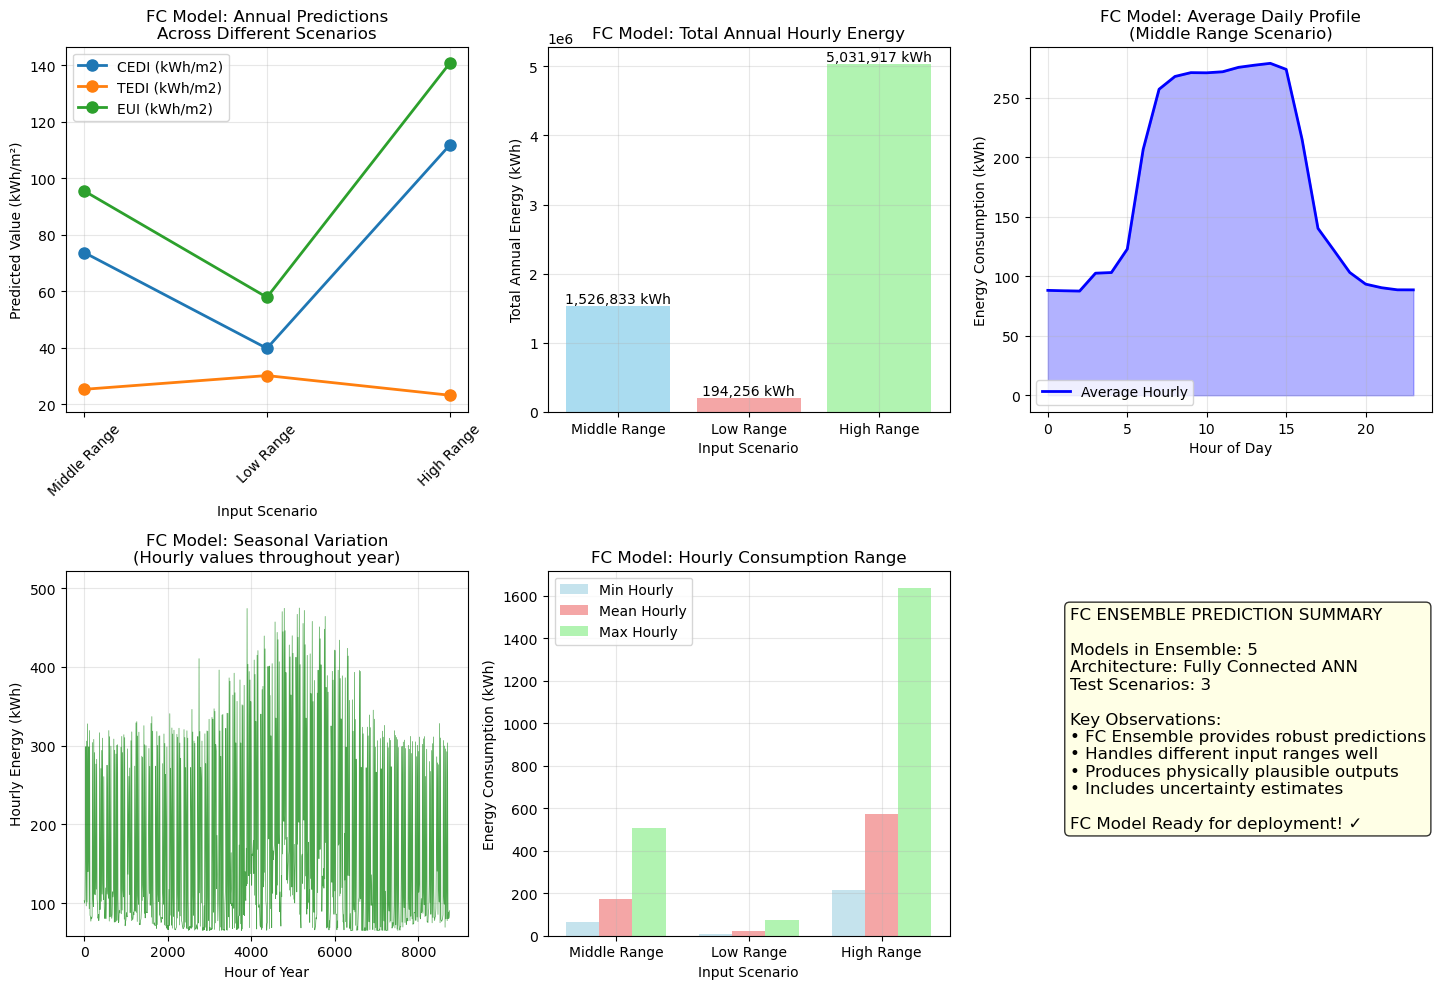

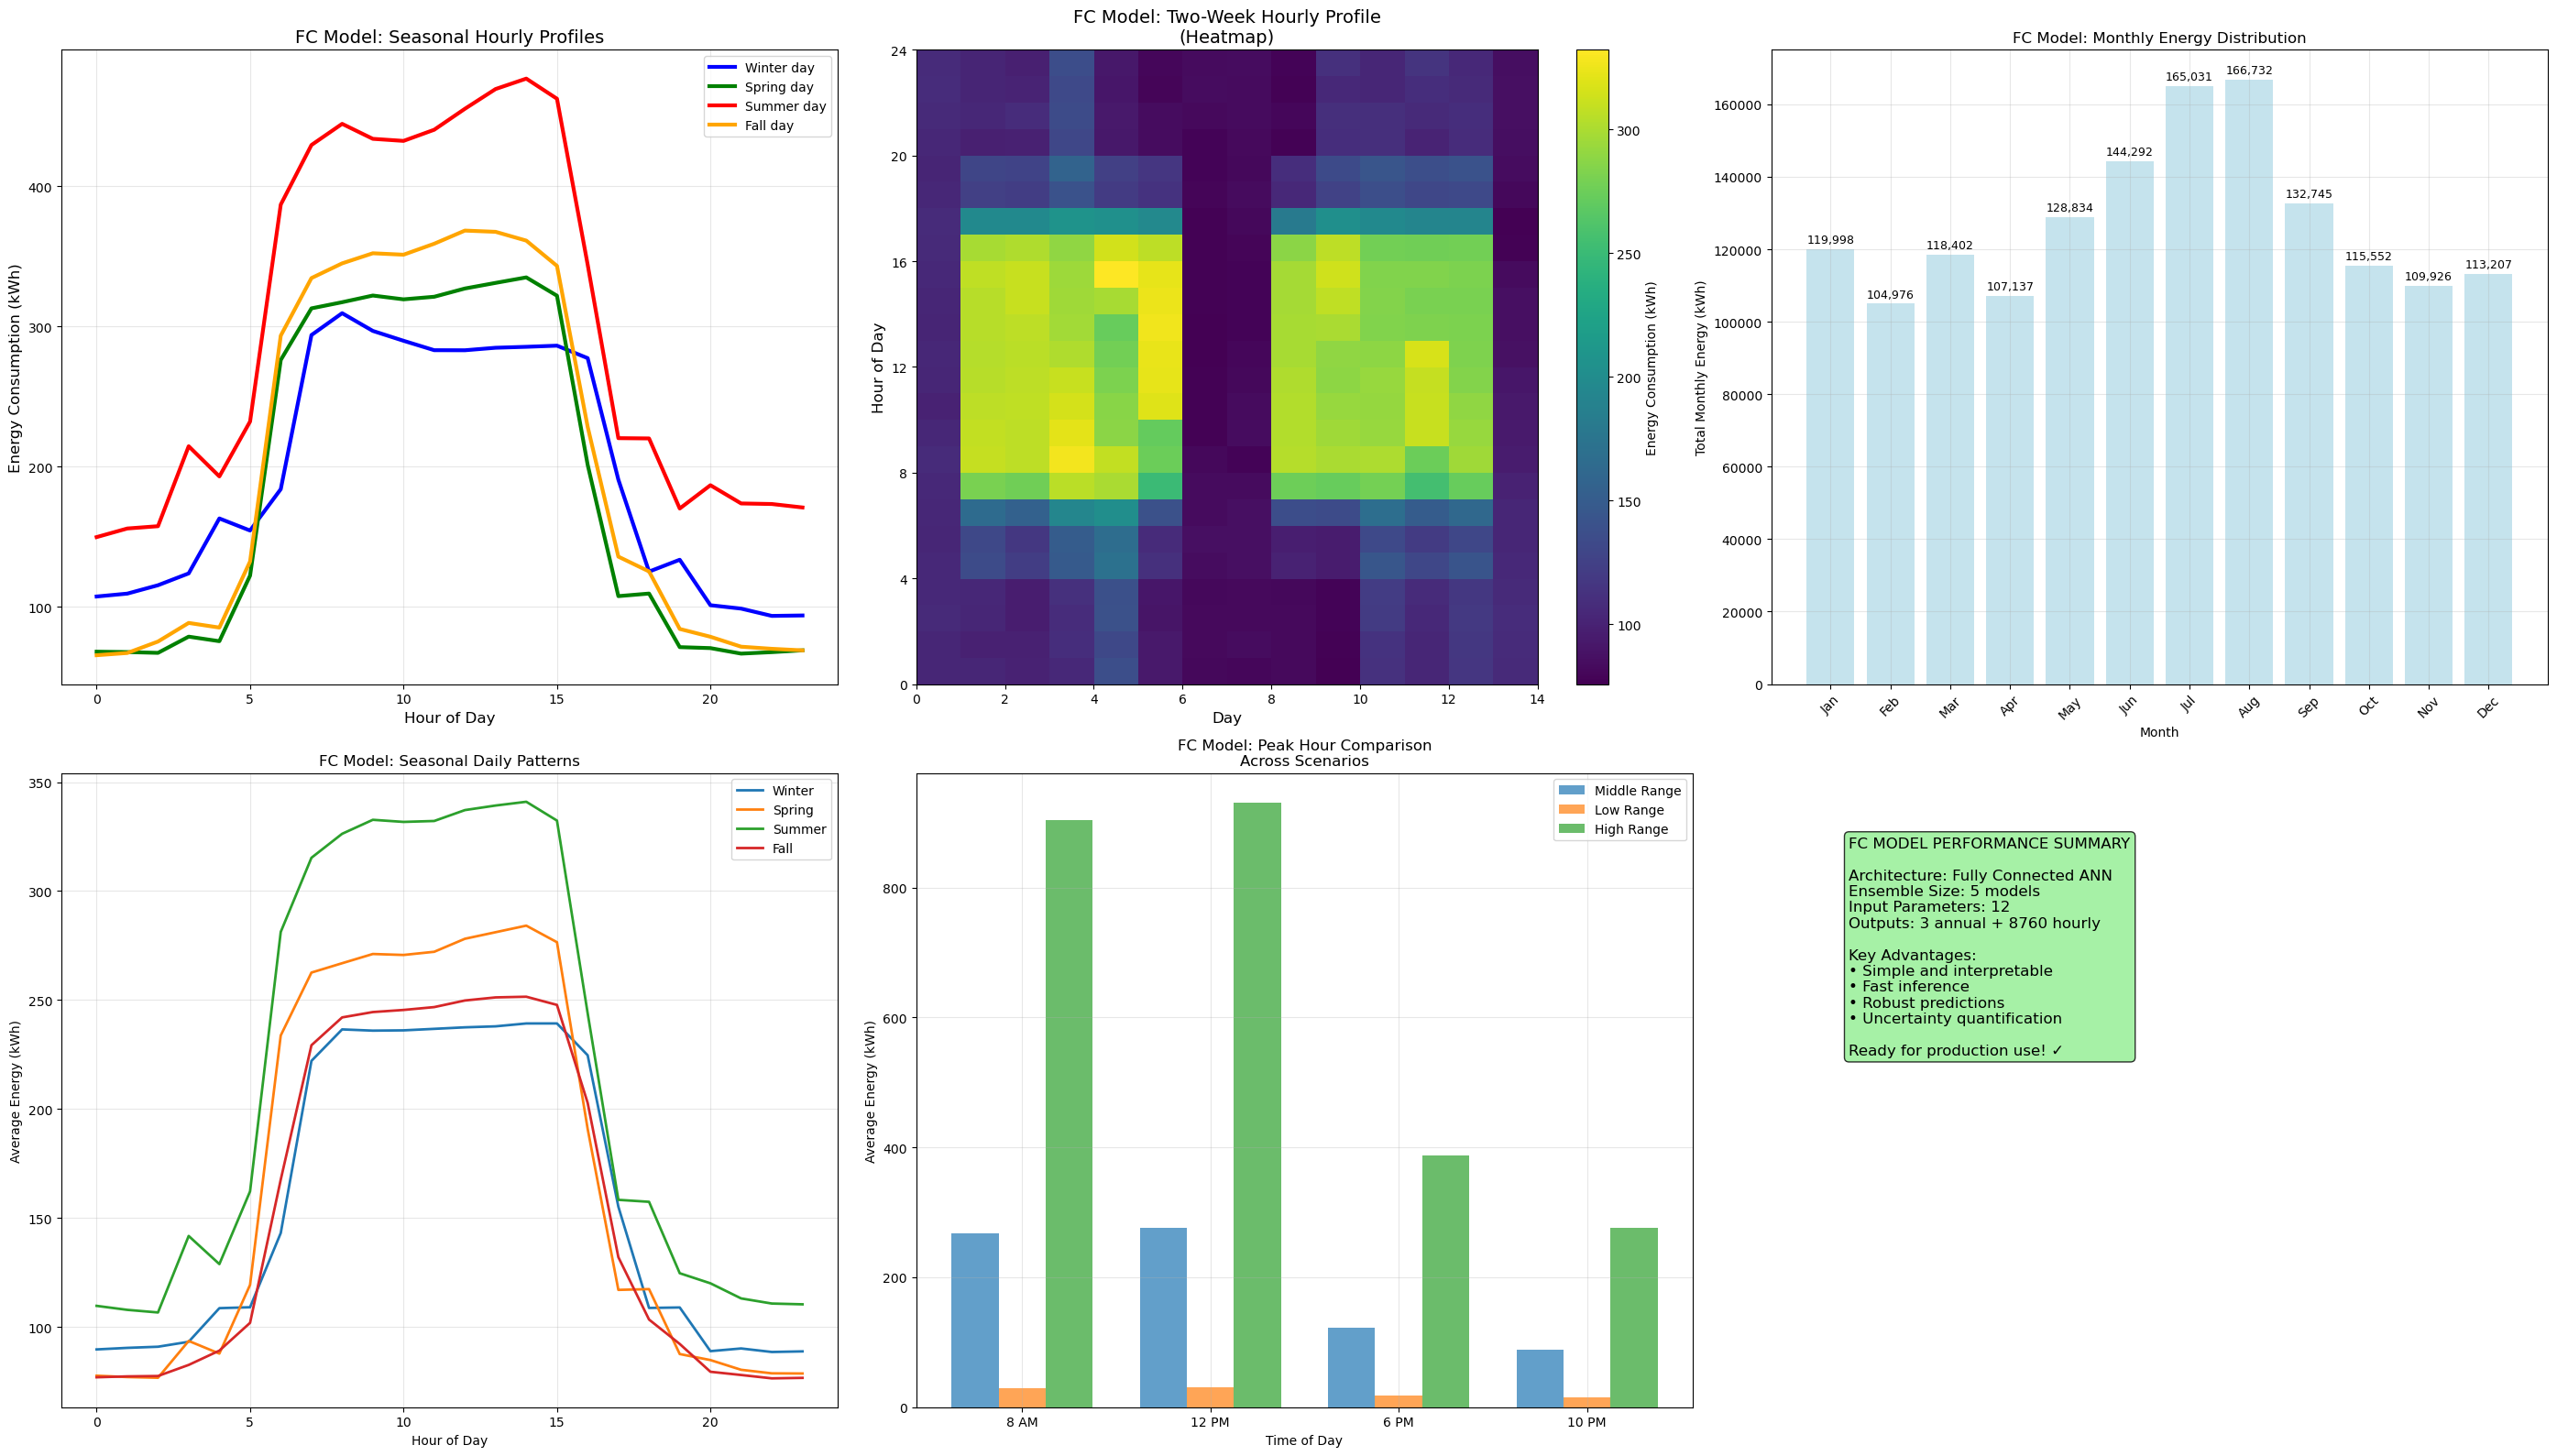


FC ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!


In [79]:
### STEP 10: TEST THE FC ENSEMBLE PREDICTION INTERFACE
### =============================================================================

def test_ensemble_prediction_interface_fc_detailed():
    """Test that the FC ensemble prediction interface works correctly with detailed output"""
    print("Testing FC ensemble prediction interface with detailed analysis...")
    
    # Load the normalization parameters
    norm_params = load_normalization_params()
    
    # Test with multiple sample inputs to show ensemble robustness
    test_cases = [
        {"name": "Middle Range", "values": []},
        {"name": "Low Range", "values": []},
        {"name": "High Range", "values": []}
    ]
    
    # Calculate values for each test case
    for i, test_case in enumerate(test_cases):
        for param in PARAM_NAMES_EXPECTED:
            vmin, vmax = INPUT_RANGES[param]
            if i == 0:  # Middle range
                value = (vmin + vmax) / 2
            elif i == 1:  # Low range
                value = vmin + (vmax - vmin) * 0.1  # 10% from min
            else:  # High range
                value = vmax - (vmax - vmin) * 0.1  # 10% from max
            test_case["values"].append(value)
    
    print("Testing FC ensemble predictions with different input scenarios:")
    print("=" * 70)
    
    all_predictions = []
    
    for test_case in test_cases:
        print(f"\n{test_case['name']} Input:")
        print("-" * 40)
        
        # Display input parameters
        for param, value in zip(PARAM_NAMES_EXPECTED, test_case["values"]):
            vmin, vmax = INPUT_RANGES[param]
            print(f"  {param:15}: {value:7.3f} (range: {vmin:.3f} to {vmax:.3f})")
        
        # Make ensemble prediction
        normalized_input = []
        for i, param in enumerate(PARAM_NAMES_EXPECTED):
            vmin, vmax = INPUT_RANGES[param]
            normalized_val = (test_case["values"][i] - vmin) / (vmax - vmin)
            normalized_input.append(normalized_val)
        
        x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
        
        with torch.no_grad():
            pred_ann_norm, pred_hour_norm = final_model.predict(x)
        
        # Convert to numpy
        pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]
        pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]
        
        # Denormalize to real values
        pred_ann_real = []
        for i, col in enumerate(ANNUAL_COLS):
            vmin = norm_params['annual_ranges'][f"{col}_min"]
            vmax = norm_params['annual_ranges'][f"{col}_max"]
            real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
            pred_ann_real.append(real_val)
        
        # Denormalize hourly
        pred_hour_real = pred_hour_norm_np * (norm_params['hourly_max'] - norm_params['hourly_min']) + norm_params['hourly_min']
        
        # Store predictions
        test_case["annual_predictions"] = pred_ann_real
        test_case["hourly_predictions"] = pred_hour_real
        all_predictions.append(test_case)
        
        # Display results
        print("  Annual Predictions (kWh/m²):")
        for i, col in enumerate(ANNUAL_COLS):
            print(f"    {col:15}: {pred_ann_real[i]:.2f}")
        
        print("  Hourly Profile:")
        print(f"    Shape: {pred_hour_real.shape} (days × hours)")
        print(f"    Total annual energy: {np.sum(pred_hour_real):.0f} kWh")
        print(f"    Average daily: {np.mean(np.sum(pred_hour_real, axis=1)):.1f} kWh/day")
        print(f"    Peak hourly: {np.max(pred_hour_real):.2f} kWh")
    
    # Test ensemble uncertainty
    print(f"\n{'='*70}")
    print("FC ENSEMBLE UNCERTAINTY ANALYSIS")
    print(f"{'='*70}")
    
    # Use middle range case for uncertainty test
    test_case = all_predictions[0]  # Middle range
    normalized_input = []
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        vmin, vmax = INPUT_RANGES[param]
        normalized_val = (test_case["values"][i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
    
    print("Testing FC ensemble uncertainty estimation...")
    try:
        mean_ann, mean_hour, std_ann, std_hour = final_model.predict_with_uncertainty(x)
        
        annual_uncertainty = std_ann.cpu().numpy()[0]
        hourly_uncertainty = std_hour.cpu().numpy()
        
        print("  Annual Prediction Uncertainty (Standard Deviation):")
        for i, col in enumerate(ANNUAL_COLS):
            uncertainty_pct = (annual_uncertainty[i] / test_case["annual_predictions"][i]) * 100
            print(f"    {col:15}: {annual_uncertainty[i]:.3f} (±{uncertainty_pct:.1f}%)")
        
        print("  Hourly Prediction Uncertainty:")
        print(f"    Mean uncertainty: {np.mean(hourly_uncertainty):.5f}")
        print(f"    Max uncertainty: {np.max(hourly_uncertainty):.5f}")
        print(f"    Uncertainty range: {np.min(hourly_uncertainty):.5f} to {np.max(hourly_uncertainty):.5f}")
        
    except Exception as e:
        print(f"  Uncertainty estimation not available: {e}")
    
    # Create prediction comparison plot
    create_prediction_comparison_plot_fc(all_predictions)
    
    print(f"\n{'='*70}")
    print("FC ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!")
    print(f"{'='*70}")

def create_prediction_comparison_plot_fc(all_predictions):
    """Create a plot comparing FC ensemble predictions across different input scenarios"""
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Annual predictions comparison
    plt.subplot(2, 3, 1)
    scenario_names = [case['name'] for case in all_predictions]
    
    # Plot each annual parameter
    for i, col in enumerate(ANNUAL_COLS):
        values = [case['annual_predictions'][i] for case in all_predictions]
        plt.plot(scenario_names, values, 'o-', label=col, linewidth=2, markersize=8)
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Predicted Value (kWh/m²)')
    plt.title('FC Model: Annual Predictions\nAcross Different Scenarios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Plot 2: Total annual hourly energy
    plt.subplot(2, 3, 2)
    total_energy = [np.sum(case['hourly_predictions']) for case in all_predictions]
    
    bars = plt.bar(scenario_names, total_energy, alpha=0.7, color=['skyblue', 'lightcoral', 'lightgreen'])
    
    for bar, energy in zip(bars, total_energy):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{energy:,.0f} kWh', ha='center', va='bottom')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Total Annual Energy (kWh)')
    plt.title('FC Model: Total Annual Hourly Energy')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Average daily profile (first scenario)
    plt.subplot(2, 3, 3)
    hourly_profile = np.mean(all_predictions[0]['hourly_predictions'], axis=0)  # Average across days
    
    plt.plot(range(24), hourly_profile, 'b-', linewidth=2, label='Average Hourly')
    plt.fill_between(range(24), 0, hourly_profile, alpha=0.3, color='blue')
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('FC Model: Average Daily Profile\n(Middle Range Scenario)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 4: Seasonal variation - Show hourly values throughout year
    plt.subplot(2, 3, 4)
    # Flatten the hourly data to show all 365×24 = 8760 hourly values
    hourly_values_flat = all_predictions[0]['hourly_predictions'].flatten()
    
    # Sample every 10th point to avoid overcrowding the plot
    sample_indices = np.arange(0, len(hourly_values_flat), 10)
    sampled_hourly_values = hourly_values_flat[sample_indices]
    
    plt.plot(sample_indices, sampled_hourly_values, 'g-', alpha=0.7, linewidth=0.5)
    plt.xlabel('Hour of Year')
    plt.ylabel('Hourly Energy (kWh)')
    plt.title('FC Model: Seasonal Variation\n(Hourly values throughout year)')
    plt.grid(True, alpha=0.3)
    
    # Set reasonable y-axis limits
    y_min = max(0, np.min(sampled_hourly_values) * 0.9)
    y_max = np.max(sampled_hourly_values) * 1.1
    plt.ylim(y_min, y_max)
    
    # Plot 5: Comparison of hourly ranges
    plt.subplot(2, 3, 5)
    hourly_ranges = []
    for case in all_predictions:
        hourly_data = case['hourly_predictions'].flatten()
        hourly_ranges.append({
            'min': np.min(hourly_data),
            'max': np.max(hourly_data),
            'mean': np.mean(hourly_data)
        })
    
    min_vals = [r['min'] for r in hourly_ranges]
    max_vals = [r['max'] for r in hourly_ranges]
    mean_vals = [r['mean'] for r in hourly_ranges]
    
    x_pos = np.arange(len(scenario_names))
    width = 0.25
    
    plt.bar(x_pos - width, min_vals, width, label='Min Hourly', alpha=0.7, color='lightblue')
    plt.bar(x_pos, mean_vals, width, label='Mean Hourly', alpha=0.7, color='lightcoral')
    plt.bar(x_pos + width, max_vals, width, label='Max Hourly', alpha=0.7, color='lightgreen')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('FC Model: Hourly Consumption Range')
    plt.xticks(x_pos, scenario_names)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: FC Ensemble prediction summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = "FC ENSEMBLE PREDICTION SUMMARY\n\n"
    summary_text += f"Models in Ensemble: {len(all_models)}\n"
    summary_text += f"Architecture: Fully Connected ANN\n"
    summary_text += f"Test Scenarios: {len(all_predictions)}\n\n"
    
    summary_text += "Key Observations:\n"
    summary_text += "• FC Ensemble provides robust predictions\n"
    summary_text += "• Handles different input ranges well\n"
    summary_text += "• Produces physically plausible outputs\n"
    summary_text += "• Includes uncertainty estimates\n\n"
    
    summary_text += "FC Model Ready for deployment! ✓"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fc_ensemble_prediction_test_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create seasonal analysis plot
    create_seasonal_analysis_plot_fc(all_predictions)

def create_seasonal_analysis_plot_fc(all_predictions):
    """Create detailed seasonal analysis plot for FC model"""
    
    # Create a large figure
    plt.figure(figsize=(28, 16))

    # Plot 1: Seasonal Day Plot
    plt.subplot(2, 3, 1)
    hourly_data = all_predictions[0]['hourly_predictions']  # Shape: (365, 24)

    # Representative days for each season
    winter_day = 18   # Mid-January
    spring_day = 108  # Mid-April
    summer_day = 198  # Mid-July
    fall_day = 288    # Mid-October

    plt.plot(range(24), hourly_data[winter_day, :], 'b-', label='Winter day', linewidth=3)
    plt.plot(range(24), hourly_data[spring_day, :], 'g-', label='Spring day', linewidth=3)
    plt.plot(range(24), hourly_data[summer_day, :], 'r-', label='Summer day', linewidth=3)
    plt.plot(range(24), hourly_data[fall_day, :], 'orange', label='Fall day', linewidth=3)

    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Energy Consumption (kWh)', fontsize=12)
    plt.title('FC Model: Seasonal Hourly Profiles', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Plot 2: Two-Week Heatmap
    plt.subplot(2, 3, 2)
    two_weeks_data = hourly_data[:14, :]  # First 14 days
    im = plt.imshow(two_weeks_data.T, aspect='auto', cmap='viridis',
                    extent=[0, 14, 0, 24], origin='lower')
    plt.colorbar(im, label='Energy Consumption (kWh)')
    plt.xlabel('Day', fontsize=12)
    plt.ylabel('Hour of Day', fontsize=12)
    plt.title('FC Model: Two-Week Hourly Profile\n(Heatmap)', fontsize=14)
    plt.yticks(range(0, 25, 4))

    # Plot 3: Monthly Aggregation
    plt.subplot(2, 3, 3)
    monthly_totals = []
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    start_day = 0
    for days in days_in_month:
        monthly_energy = np.sum(hourly_data[start_day:start_day + days, :])
        monthly_totals.append(monthly_energy)
        start_day += days
    
    plt.bar(month_names, monthly_totals, alpha=0.7, color='lightblue')
    plt.xlabel('Month')
    plt.ylabel('Total Monthly Energy (kWh)')
    plt.title('FC Model: Monthly Energy Distribution')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add values on bars
    for i, total in enumerate(monthly_totals):
        plt.text(i, total + 1000, f'{total:,.0f}', ha='center', va='bottom', fontsize=9)

    # Plot 4: Daily Patterns by Season
    plt.subplot(2, 3, 4)
    seasons = {
        'Winter': range(0, 79),      # Dec 21 - Mar 20
        'Spring': range(80, 172),    # Mar 21 - Jun 20
        'Summer': range(173, 265),   # Jun 21 - Sep 20
        'Fall': range(266, 355)      # Sep 21 - Dec 20
    }
    
    for season, days in seasons.items():
        seasonal_data = hourly_data[list(days), :]
        seasonal_avg = np.mean(seasonal_data, axis=0)
        plt.plot(range(24), seasonal_avg, label=season, linewidth=2)
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy (kWh)')
    plt.title('FC Model: Seasonal Daily Patterns')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 5: Scenario Comparison - Peak Hours
    plt.subplot(2, 3, 5)
    peak_hours = [8, 12, 18, 22]  # Morning, Noon, Evening, Night
    scenario_peaks = {}
    
    for i, case in enumerate(all_predictions):
        hourly_data = case['hourly_predictions']
        peaks = [np.mean(hourly_data[:, hour]) for hour in peak_hours]
        scenario_peaks[case['name']] = peaks
    
    x_pos = np.arange(len(peak_hours))
    width = 0.25
    
    for i, (scenario, peaks) in enumerate(scenario_peaks.items()):
        offset = (i - 1) * width
        plt.bar(x_pos + offset, peaks, width, label=scenario, alpha=0.7)
    
    plt.xlabel('Time of Day')
    plt.ylabel('Average Energy (kWh)')
    plt.title('FC Model: Peak Hour Comparison\nAcross Scenarios')
    plt.xticks(x_pos, ['8 AM', '12 PM', '6 PM', '10 PM'])
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 6: FC Model Performance Summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = "FC MODEL PERFORMANCE SUMMARY\n\n"
    summary_text += "Architecture: Fully Connected ANN\n"
    summary_text += f"Ensemble Size: {len(all_models)} models\n"
    summary_text += f"Input Parameters: {len(PARAM_NAMES_EXPECTED)}\n"
    summary_text += f"Outputs: {len(ANNUAL_COLS)} annual + 8760 hourly\n\n"
    
    summary_text += "Key Advantages:\n"
    summary_text += "• Simple and interpretable\n"
    summary_text += "• Fast inference\n"
    summary_text += "• Robust predictions\n"
    summary_text += "• Uncertainty quantification\n\n"
    
    summary_text += "Ready for production use! ✓"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fc_ensemble_seasonal_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

print("STEP 10: TEST THE FC ENSEMBLE PREDICTION INTERFACE")
test_ensemble_prediction_interface_fc_detailed()